# Arabic Sentiment Analysis
**Birzeit University — Department of Electrical and Computer Engineering**  
**Second Semester 2025-2026 | Second Assignment**

---

**Dataset:** ASTD — Arabic Sentiment Tweets Dataset (3 classes: POS / NEG / NEUTRAL)  
**Goal:** Compare text representation methods and classifiers for Arabic sentiment analysis.

## Imports

In [1]:
# Add your imports here
import sys
sys.setrecursionlimit(5000)

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

from gensim.models import Word2Vec as GensimW2V, FastText as GensimFT

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, SimpleRNN, LSTM, Dropout, Dense

In [2]:
## ═══ Metrics & benchmarking infrastructure ═══
## Defines the timing, model-introspection and recording utilities used by every
## model cell below. Run once, early. All models register into MODEL_METRICS,
## which Section 17 renders into the full comparison table.
import time, os, pickle
import numpy as np
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)

os.makedirs('results', exist_ok=True)

# Preserve accumulated results across re-runs of THIS cell, so re-running the
# infrastructure cell (or a single model cell) never wipes everything already
# recorded. record_model de-dups by name (last wins). A full
# "Restart Kernel & Run All" starts clean because globals() is empty then.
TRAIN_TIMES   = globals().get('TRAIN_TIMES', {})    # name -> training seconds
MODEL_METRICS = globals().get('MODEL_METRICS', [])  # list[dict], one per model
CONF_MATS     = globals().get('CONF_MATS', {})      # name -> (confusion_matrix, labels)

class Timer:
    """Context manager: `with Timer('Sec 12 — MARBERT'): trainer.train()`"""
    def __init__(self, name): self.name = name
    def __enter__(self): self._t0 = time.time(); return self
    def __exit__(self, *a):
        TRAIN_TIMES[self.name] = time.time() - self._t0
        print(f'  [Timer] {self.name}: {TRAIN_TIMES[self.name]:.1f}s')

# ── framework-agnostic model introspection ───────────────────────────────────
def _param_counts(m):
    if hasattr(m, 'parameters'):                       # torch / peft
        try:
            tot = sum(p.numel() for p in m.parameters())
            tr  = sum(p.numel() for p in m.parameters() if p.requires_grad)
            return int(tot), int(tr)
        except Exception: pass
    if hasattr(m, 'count_params'):                     # keras
        try:
            tot = int(m.count_params())
            tr  = int(sum(int(np.prod(w.shape)) for w in m.trainable_weights))
            return tot, tr
        except Exception: pass
    return None, None

def _n_layers(m):
    cfg = getattr(m, 'config', None)
    if cfg is not None and hasattr(cfg, 'num_hidden_layers'):
        return int(cfg.num_hidden_layers)
    if hasattr(m, 'base_model'):
        inner = getattr(getattr(m, 'base_model', None), 'config', None)
        if inner is not None and hasattr(inner, 'num_hidden_layers'):
            return int(inner.num_hidden_layers)
    if hasattr(m, 'layers'):
        try: return len(m.layers)
        except Exception: pass
    if hasattr(m, 'modules'):
        try: return sum(1 for _ in m.modules())
        except Exception: pass
    return None

def _mem_mb(m):
    if hasattr(m, 'parameters'):                       # torch / peft
        try:
            b  = sum(p.numel()*p.element_size() for p in m.parameters())
            b += sum(bf.numel()*bf.element_size() for bf in m.buffers())
            return round(b/1e6, 2)
        except Exception: pass
    if hasattr(m, 'count_params'):                     # keras (fp32)
        try: return round(int(m.count_params())*4/1e6, 2)
        except Exception: pass
    try: return round(len(pickle.dumps(m))/1e6, 2)     # sklearn fallback
    except Exception: return None

def _sklearn_params(est):
    n = 0
    if hasattr(est, 'coef_'):             n += int(np.prod(est.coef_.shape))
    if hasattr(est, 'intercept_'):        n += int(np.prod(np.atleast_1d(est.intercept_).shape))
    if hasattr(est, 'feature_log_prob_'): n += int(np.prod(est.feature_log_prob_.shape))
    if hasattr(est, 'estimators_'):       n += int(sum(t.tree_.node_count for t in est.estimators_))
    return n or None

def model_report(model):
    """(n_params, n_trainable, n_layers, mem_mb) for sklearn / keras / torch-peft."""
    est = getattr(model, 'best_estimator_', model)     # unwrap GridSearchCV
    p, tr = _param_counts(est)
    if p is None:                                      # sklearn
        p = _sklearn_params(est); tr = p
    return p, tr, _n_layers(est), _mem_mb(est)

def measure_inference(predict_fn, n_runs=3):
    """Median wall-clock seconds of predict_fn() over n_runs."""
    ts = []
    for _ in range(n_runs):
        t0 = time.time(); predict_fn(); ts.append(time.time()-t0)
    return float(np.median(ts))

def record_model(name, family, y_true, y_pred, classes,
                 model=None, predict_fn=None, n_infer=3, train_time=None):
    """Compute + store every metric for one model. De-dups by name (last wins)."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    row = {
        'Model': name, 'Family': family,
        'Accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'Macro F1':    round(f1_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'Weighted F1': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'N Classes':   int(len(set(classes))),
        'N Test':      int(len(y_true)),
    }
    if model is not None:
        p, tr, nl, mem = model_report(model)
        row.update({'Params': p, 'Trainable': tr, 'Layers': nl, 'Mem (MB)': mem})
    else:
        row.update({'Params': None, 'Trainable': None, 'Layers': None, 'Mem (MB)': None})
    _tt = train_time if train_time is not None else TRAIN_TIMES.get(name)
    row['Train (s)'] = round(_tt, 2) if _tt is not None else None
    if predict_fn is not None:
        sec = measure_inference(predict_fn, n_infer)
        row['Infer (s)']      = round(sec, 4)
        row['Infer/1k (ms)']  = round(sec/max(len(y_true),1)*1000*1000, 2)   # ms per 1000 samples
        row['Throughput/s']   = round(len(y_true)/sec, 1) if sec > 0 else None
    else:
        row['Infer (s)'] = row['Infer/1k (ms)'] = row['Throughput/s'] = None
    CONF_MATS[name] = (confusion_matrix(y_true, y_pred), list(classes))
    global MODEL_METRICS
    MODEL_METRICS = [r for r in MODEL_METRICS if r['Model'] != name]
    MODEL_METRICS.append(row)
    print(f'  ✓ {name:38s} macroF1={row["Macro F1"]:.3f}  '
          f'params={row["Params"]}  mem={row["Mem (MB)"]}MB  '
          f'train={row["Train (s)"]}s  infer={row["Infer (s)"]}s')
    return row

print('Metrics infrastructure ready — use Timer(...) around training, record_model(...) after prediction.')


Metrics infrastructure ready — use Timer(...) around training, record_model(...) after prediction.


In [3]:
## ═══ Figure auto-save ═══
## Guarantees every illustration/graph is written to images/. Cells that already
## call plt.savefig keep their explicit filename; any other figure shown is saved
## automatically with a title-derived name. All saved paths are logged to FIG_LOG.
import os, re
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
os.makedirs('images', exist_ok=True)

FIG_LOG   = []          # every figure path saved this session
_saved_ids = set()
_auto_n    = {'n': 0}

if not getattr(Figure, '_autosave_patched', False):
    _orig_savefig = Figure.savefig
    def _tracking_savefig(self, fname, *a, **k):
        k.setdefault('bbox_inches', 'tight')
        _saved_ids.add(id(self))
        res = _orig_savefig(self, fname, *a, **k)
        FIG_LOG.append(str(fname))
        return res
    Figure.savefig = _tracking_savefig
    Figure._autosave_patched = True

    _orig_show = plt.show
    def _autosave_show(*a, **k):
        for num in plt.get_fignums():
            fig = plt.figure(num)
            if id(fig) in _saved_ids:            # already saved explicitly — keep its name
                continue
            _auto_n['n'] += 1
            t = ''
            if getattr(fig, '_suptitle', None) is not None:
                t = fig._suptitle.get_text()
            elif fig.axes and fig.axes[0].get_title():
                t = fig.axes[0].get_title()
            slug = re.sub(r'[^A-Za-z0-9]+', '_', t).strip('_').lower()[:48] or 'figure'
            fig.savefig(f'images/auto_{_auto_n["n"]:02d}_{slug}.png', dpi=140)
        return _orig_show(*a, **k)
    plt.show = _autosave_show

print('Figure auto-save active — all plots persist to images/ (explicit names kept, others auto-named).')


Figure auto-save active — all plots persist to images/ (explicit names kept, others auto-named).


In [4]:
## ═══ Preprocessing cache — OPTIONAL fast path ═══
## On a rerun you can execute THIS cell alone to restore all preprocessed data
## (cleaned splits, label encoder, TF-IDF / Word2Vec / FastText features) instead
## of re-running Sections 1-4. No-op on the first run (cache not yet built), and
## it FAILS SAFE: a missing OR corrupt cache just falls back to normal processing
## so a bad cache can never halt a "Run All".
import os, joblib
CACHE_PATH   = 'cache/preprocessing.joblib'
CACHE_LOADED = False
if os.path.exists(CACHE_PATH):
    try:
        _c = joblib.load(CACHE_PATH)
        globals().update(_c)
        CACHE_LOADED = True
        print(f'Loaded preprocessing cache ({len(_c)} objects) — you may skip to the modelling sections.')
        print('  keys:', ', '.join(sorted(_c.keys())))
    except Exception as _e:
        print(f'⚠ Cache at {CACHE_PATH} is unreadable ({type(_e).__name__}: {_e}).')
        print('  Ignoring it and reprocessing from scratch; the cache-save cell will rewrite a fresh copy.')
        try:
            os.remove(CACHE_PATH); print('  Removed the corrupt cache file.')
        except OSError:
            pass
else:
    print('No cache yet — run Sections 1-4 normally; the cache-save cell will create it.')


No cache yet — run Sections 1-4 normally; the cache-save cell will create it.


## Load Dataset

In [5]:
# Load the dataset from ASTD_arabic_sentiment.csv
df = pd.read_csv('real data.txt', sep='\t', header=None, names=['text', 'label'])
# Merge OBJ into NEUTRAL — the assignment treats these as the same class
df['label'] = df['label'].replace('OBJ', 'NEUTRAL')
print(f'Dataset shape: {df.shape}')

Dataset shape: (9694, 2)


---
# 1. Data Exploration

In [6]:
# Basic structure: shape, dtypes, missing values
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9694 entries, 0 to 9693
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    9694 non-null   str  
 1   label   9694 non-null   str  
dtypes: str(2)
memory usage: 1.6 MB
None


- As we can see there are 2 columns, the first column being the text (the post/tweet from the users), and the second column is the label, where the label is what determines under what category/class the tweet falls under. Thankfully no null values yet, however that may change once we process the tweet for stop words or other characters that may be removed.

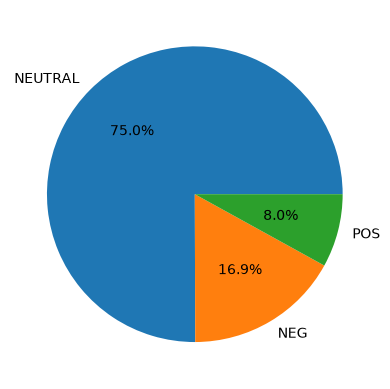

In [7]:
# Class distribution — count and proportion
distribution = df['label'].value_counts()
distribution.plot(kind='pie', autopct='%1.1f%%')
plt.savefig('images/class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

As we can see here the data is mostly Neutral (Imbalanced), where the rest is a third positive with the rest negative.

In [8]:
# Print a few sample tweets per class
for label in df['label'].unique():
    samples = df[df['label'] == label]['text'].head(2).tolist()
    print(f'\n{label}:')
    for sample in samples:
        print(sample)
    print ('='*90)


NEUTRAL:
بعد استقالة رئيس #المحكمة_الدستورية ننتظر استقالة #رئيس_القضاء #السودان
#الحرية_والعدالة | شاهد الآن: #ليلة_الاتحادية أول فيلم استقصائي يتناول أسرار و كواليس تعرض لأول مرة حول حقيقة

POS:
أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر، بمناسبة صدور أولى روايته
امير عيد هو اللي فعلا يتقال عليه ستريكر صريح #كاريوكي #السكة_شمال

NEG:
البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام العريان الي واشنطن شئ مقرف
عودة جماعة الإخوان إلى الحياة السياسية بنفس وضعها السابق مستحيلة والطرمخة على جرائم الماضي لن تجعلنا نتقدم شبرا


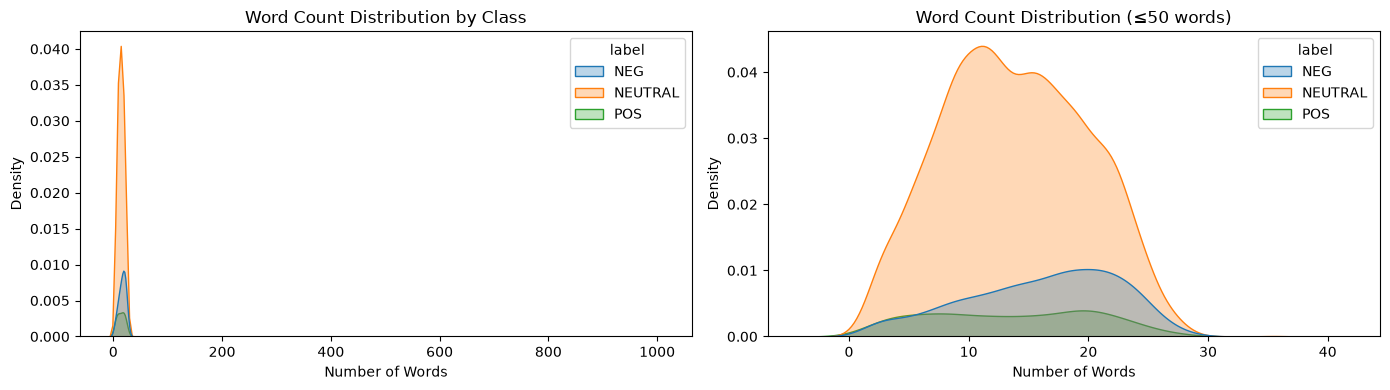

In [9]:
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.kdeplot(data=df, x='word_count', hue='label',
            hue_order=['NEG', 'NEUTRAL', 'POS'],
            fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title('Word Count Distribution by Class')
axes[0].set_xlabel('Number of Words')

sns.kdeplot(data=df[df['word_count'] <= 50], x='word_count', hue='label',
            hue_order=['NEG', 'NEUTRAL', 'POS'],
            fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title('Word Count Distribution (≤50 words)')
axes[1].set_xlabel('Number of Words')

plt.tight_layout()
plt.savefig('images/word_count_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

### Observation
As we can see from the KDE plot, word count does not vary much between classes — for the most part all are right skewed and we see that most tweets are short. So there is no true information gain from the length.

---
# 2. Data Preprocessing

Arabic social media text requires specific cleaning steps before feeding it to any model:

| Step | What to do |
|---|---|
| Noise removal | Remove URLs, HTML tags, @mentions, hashtag symbols, emojis, Latin/digits |
| Tashkeel | Remove short vowel diacritics (rarely appear on social media, inflate vocab) |
| Tatweel | Remove the elongation character ـ |
| Alef normalisation | Map أ / إ / آ → ا |
| Yeh normalisation | Map ى → ي |
| Teh Marbuta | Map ة → ه |
| Non-Arabic removal | Keep only Arabic Unicode range (U+0600–U+06FF) |
| Stop words | Remove common function words with no sentiment value |

### Write the text cleaning function

In [10]:
# Arabic stop words — negation words (لا، لم، ليس، ليست، ولا، ولم) are intentionally excluded
# because removing them flips sentiment (e.g. "لا أحب" → "أحب" changes "I don't like" to "I like")
ARABIC_STOP_WORDS = {
    'في', 'من', 'إلى', 'على', 'أن', 'هذا', 'هذه', 'ذلك', 'التي', 'الذي',
    'وفي', 'وقد', 'كان', 'ما', 'مع', 'بين', 'عن', 'قد', 'كل',
    'له', 'بعد', 'قبل', 'وهو', 'وهي', 'أو', 'هو', 'هي', 'نحن',
    'أنا', 'أنت', 'هم', 'هن', 'عند', 'أيضا', 'حتى', 'إذا', 'لكن',
    'يكون', 'كانت', 'وكان', 'يمكن', 'الذين', 'غير', 'بشكل', 'حيث',
    'بما', 'كما', 'تم', 'مما', 'إن', 'وأن', 'ومن', 'عبر',
    'لأن', 'أنه', 'ذات', 'بل', 'ثم', 'اي', 'أي', 'ال', 'و',
    'ب', 'ل', 'ف', 'ك', 'هل', 'لي', 'لك', 'لنا', 'لهم', 'منه',
    'منها', 'فيه', 'فيها', 'وكل', 'سوف', 'اذ', 'إذ', 'كيف', 'متى',
    'أين', 'انا', 'انت', 'الان', 'الآن', 'ولكن',
    'هناك', 'وهذا', 'وهذه', 'كانوا', 'قالوا', 'وقال', 'وقالت',
    'عليه', 'عليها', 'فقط', 'عليهم', 'لهذا', 'بهذا', 'كذلك',
    'وأيضا', 'مثل', 'وعلى', 'وعن', 'عنه', 'عنها', 'وهم', 'وله',
}

def preprocess_arabic(text: str) -> str:
    if not isinstance(text, str):
        return ''

    # Step 1: Remove web/social noise — must come before punctuation stripping
    # so that @mentions and #hashtags are matched whole before @ and # are removed
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # URLs
    text = re.sub(r'<[^>]+>', '', text)                   # HTML tags
    text = re.sub(r'@\w+', '', text)                      # @mentions
    text = re.sub(r'#(\S+)', r'\1', text)                 # strip # but keep word

    # Step 2: Remove diacritics and decorative characters
    text = re.sub(r'[ً-ٰٟ]', '', text)    # tashkeel (short vowels)
    text = re.sub(r'ـ', '', text)                    # tatweel (elongation ـ)

    # Step 3: Remove Arabic punctuation (،, ؛, ؟ are inside Arabic range so need explicit removal)
    text = re.sub(r'[؀-،؛؟٪-٭۔]', ' ', text)

    # Step 4: Normalize Arabic character variants
    text = re.sub(r'[إأآ]', 'ا', text)   # Alef variants → ا
    text = re.sub(r'ى', 'ي', text)        # Alef Maqsura → Yeh
    text = re.sub(r'ة', 'ه', text)        # Teh Marbuta → Heh
    text = re.sub(r'ؤ', 'و', text)        # Waw with hamza → Waw
    text = re.sub(r'ئ', 'ي', text)        # Yeh with hamza → Yeh

    # Step 5: Keep only Arabic letters and whitespace
    text = re.sub(r'[^ء-غف-ي\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 6: Remove stop words and single-character tokens
    words = [w for w in text.split() if w not in ARABIC_STOP_WORDS and len(w) > 1]
    return ' '.join(words)

### Call the new method over the data and verify it works

In [11]:
# Apply the cleaning function row-by-row to the 'text' column.
df['text_clean'] = df['text'].apply(preprocess_arabic)

# Visual before/after check — lets us verify the pipeline is working as intended.
print('Before / After examples:')
print('='*90)
for i in range(3):
    print(f'\n[{df["label"].iloc[i]}]')
    print(f'  BEFORE: {df["text"].iloc[i]}')
    print(f'  AFTER:  {df["text_clean"].iloc[i]}')


Before / After examples:

[NEUTRAL]
  BEFORE: بعد استقالة رئيس #المحكمة_الدستورية ننتظر استقالة #رئيس_القضاء #السودان
  AFTER:  استقاله رييس المحكمه الدستوريه ننتظر استقاله رييس القضاء السودان

[POS]
  BEFORE: أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر، بمناسبة صدور أولى روايته
  AFTER:  اهني الدكتور احمد جمال الدين القيادي بحزب مصر بمناسبه صدور اولي روايته

[NEG]
  BEFORE: البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام العريان الي واشنطن شئ مقرف
  AFTER:  البرادعي يستقوي بامريكا مرهاخري يرسل عصام العريان الي واشنطن شي مقرف


### Remove any empty rows that were generated from post processing

In [12]:
empty = (df['text_clean'].str.strip() == '').sum()
print(f'\nEmpty texts after preprocessing: {empty}')
df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
print(f'Remaining samples: {len(df)}')

df['text_clean'].info()


Empty texts after preprocessing: 10
Remaining samples: 9684
<class 'pandas.Series'>
RangeIndex: 9684 entries, 0 to 9683
Series name: text_clean
Non-Null Count  Dtype
--------------  -----
9684 non-null   str  
dtypes: str(1)
memory usage: 1.4 MB


### Migrate categories to numeric encodings

In [13]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'NEG': 0, 'NEUTRAL': 1, 'POS': 2}


### Observations

All noise that was deemed unneccessary was removed, hashtags, stop words (words that dont give true meaning becuase they are so common in the language), whitespaces, latin characters, etc...
I have also converted the labels to numeric values to help with the training. 
A handful of rows were dropped which is a good sign for the data quality as of now.
# Emoji Demojization
Although Emojis do provide sentiment, the amount of preprocessing to do so will overcomplicate and take too much effort, I have thought of an effort to make it where we convert emoji to its name and then convert the name to its arabic translation. However that requires too much effort. I do recommend to just remove it and keep it strictly words for now to keep the assignment simple.


---
# 3. Dataset Splitting

Split into **60% train / 20% validation / 20% test** using stratified sampling so each split has the same class proportions.

In [14]:
# Two-step stratified split: 60% train, then 50/50 on the remaining 40%

X = df['text_clean'].to_numpy()
y = df['label_enc'].to_numpy()

# Step 1: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

# Step 2: split temp 50/50 → 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f'Train:      {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)')
print(f'Validation: {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)')
print(f'Test:       {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)')

def print_class_balance(y, name):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    print(f'\n{name} ({total} samples):')
    for label, count in zip(unique, counts):
        print(f'  {le.classes_[label]}: {count} ({count/total*100:.1f}%)')

print_class_balance(y_train, 'Train')
print_class_balance(y_val, 'Validation')
print_class_balance(y_test, 'Test')

Train:      5810 (60.0%)
Validation: 1937 (20.0%)
Test:       1937 (20.0%)

Train (5810 samples):
  NEG: 985 (17.0%)
  NEUTRAL: 4360 (75.0%)
  POS: 465 (8.0%)

Validation (1937 samples):
  NEG: 328 (16.9%)
  NEUTRAL: 1454 (75.1%)
  POS: 155 (8.0%)

Test (1937 samples):
  NEG: 328 (16.9%)
  NEUTRAL: 1454 (75.1%)
  POS: 155 (8.0%)


---
# 4. Feature Representations

Fit all vectorisers on **training data only** — never on validation or test.

Three representations:
1. **TF-IDF** — word-level unigrams + bigrams
2. **FastText** — character n-gram TF-IDF (`analyzer='char_wb'`)
3. **Word2Vec (CBOW)** — custom trained with PyTorch, then mean-pool into document vectors


# 4. Data Representation

## 4.1 TF-IDF

In [15]:
# Build TF-IDF feature matrices for train / val / test
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
X_tfidf_train = tfidf.fit_transform(X_train)
X_tfidf_val   = tfidf.transform(X_val)
X_tfidf_test  = tfidf.transform(X_test)

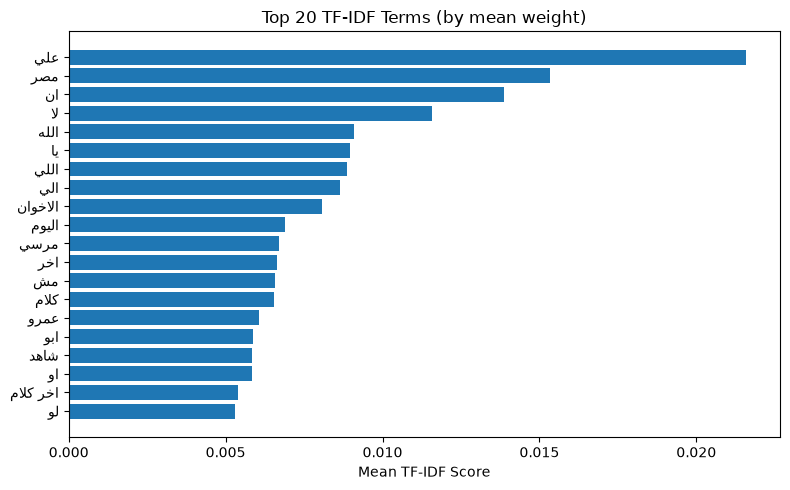

In [16]:
# Top 20 TF-IDF terms by mean weight across training documents
feature_names = tfidf.get_feature_names_out()
mean_scores   = X_tfidf_train.mean(axis=0).A1
top20_idx     = mean_scores.argsort()[-20:][::-1]

plt.figure(figsize=(8, 5))
plt.barh([feature_names[i] for i in top20_idx[::-1]], mean_scores[top20_idx[::-1]])
plt.title('Top 20 TF-IDF Terms (by mean weight)')
plt.xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.savefig('images/tfidf_top20.png', bbox_inches='tight', dpi=150)
plt.show()

### TF-IDF Analysis

TF-IDF converts each tweet into a sparse vector of weighted word and bigram scores, where if a term appears alot in one document but rare in other documents, will receive a higher score.

**Compatible models:** ✓ Naïve Bayes (requires non-negative values — TF-IDF always ≥ 0), ✓ Random Forest. ✗ CNN / RNN / LSTM (these expect integer token sequences for an embedding layer, not pre-computed vectors).

**Pros:**
- No training required — fit is instant
- Bigrams capture short negation phrases like "لا يحب" that unigrams miss
- Fully interpretable — feature weights map directly to words

**Cons:**
- No semantic understanding — synonyms like "جيد" and "ممتاز" are unrelated tokens
- Arabic morphology inflates vocabulary — different surface forms of the same root count as separate features

## 4.2 Word2Vec (CBOW)

In [17]:
sentences = [t.split() for t in X_train]
w2v_model = GensimW2V(sentences, vector_size=100, window=2, min_count=2, sg=0, epochs=15, seed=42, workers=4)
print(f'Vocab size: {len(w2v_model.wv)}')

Vocab size: 8358


In [18]:
def doc_vec(text, model):
    vecs = [model.wv[w] for w in text.split() if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

X_w2v_train = np.vstack([doc_vec(t, w2v_model) for t in X_train])
X_w2v_val   = np.vstack([doc_vec(t, w2v_model) for t in X_val])
X_w2v_test  = np.vstack([doc_vec(t, w2v_model) for t in X_test])

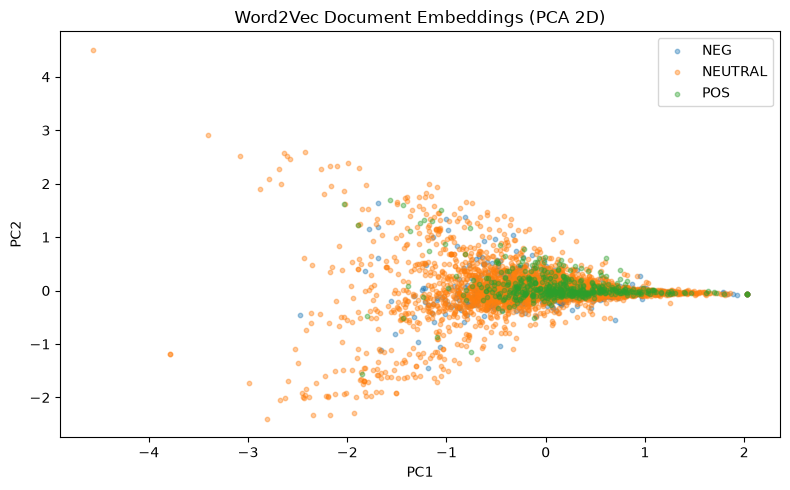

In [19]:
# PCA 2D projection of Word2Vec document embeddings coloured by sentiment class
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_w2v_train)

plt.figure(figsize=(8, 5))
for label_id, label_name in enumerate(le.classes_):
    mask = y_train == label_id
    plt.scatter(coords[mask, 0], coords[mask, 1], label=label_name, alpha=0.4, s=10)
plt.title('Word2Vec Document Embeddings (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('images/word2vec_pca.png', bbox_inches='tight', dpi=150)
plt.show()

### Word2Vec (CBOW) Analysis

Word2Vec trains a shallow neural network to predict each word from its surrounding context, producing a dense 100-dimensional vector per word that captures semantic similarity — words used in similar contexts end up close together in vector space. Each tweet is then represented as the mean of its word vectors. In essence, we convert words to vectors, and basically apply nearest neigbor for sentiment analysis.

**Compatible models:** ✓ Random Forest (accepts dense real-valued vectors including negatives). ✗ Naïve Bayes (vectors contain negative values, violating MultinomialNB's non-negative constraint). ✗ CNN / RNN / LSTM (learn their own embeddings internally).

**Pros:**
- Semantically meaningful — similar words cluster together, so synonyms share representation
- Fixed-size output regardless of tweet length

**Cons:**
- Needs large corpora for quality embeddings; ~5,800 tweets is too small
- Mean pooling destroys word order entirely
- Cannot handle out-of-vocabulary words (no subword fallback)

## 4.3 FastText

In [20]:
ft_model = GensimFT(sentences, vector_size=300, window=2, min_count=2, epochs=20, seed=42, workers=4)
print(f'Vocab size: {len(ft_model.wv)}')

X_ft_train = np.vstack([doc_vec(t, ft_model) for t in X_train])
X_ft_val   = np.vstack([doc_vec(t, ft_model) for t in X_val])
X_ft_test  = np.vstack([doc_vec(t, ft_model) for t in X_test])

Vocab size: 8358


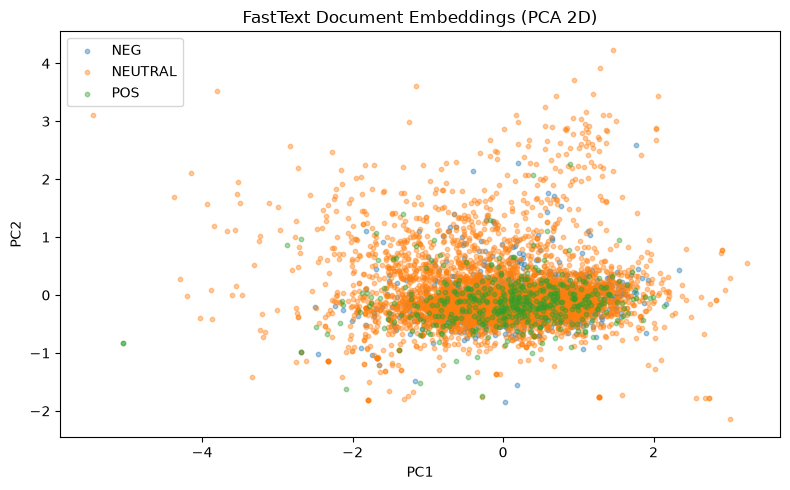

In [21]:
coords_ft = PCA(n_components=2, random_state=42).fit_transform(X_ft_train)

plt.figure(figsize=(8, 5))
for lid, lname in enumerate(le.classes_):
    mask = y_train == lid
    plt.scatter(coords_ft[mask, 0], coords_ft[mask, 1], label=lname, alpha=0.4, s=10)
plt.title('FastText Document Embeddings (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('images/fasttext_pca.png', bbox_inches='tight', dpi=150)
plt.show()

In [22]:
## ═══ Save preprocessing cache ═══
## Persists every reusable preprocessing artefact so future reruns can load them
## in seconds via the cache cell near the top (skips Arabic cleaning, TF-IDF fit,
## and Word2Vec/FastText training).
import os, joblib
os.makedirs('cache', exist_ok=True)
_cache = {
    'df': df,
    'le': le,
    'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
    'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
    'tfidf': tfidf,
    'X_tfidf_train': X_tfidf_train, 'X_tfidf_val': X_tfidf_val, 'X_tfidf_test': X_tfidf_test,
    'w2v_model': w2v_model, 'X_w2v_train': X_w2v_train, 'X_w2v_val': X_w2v_val, 'X_w2v_test': X_w2v_test,
    'ft_model': ft_model,   'X_ft_train': X_ft_train,   'X_ft_val': X_ft_val,   'X_ft_test': X_ft_test,
}
# Atomic write: dump to a temp file then replace, so an interrupted save can
# never leave a truncated cache/preprocessing.joblib at the real path.
_final, _tmp = 'cache/preprocessing.joblib', 'cache/preprocessing.joblib.tmp'
joblib.dump(_cache, _tmp, compress=3)
os.replace(_tmp, _final)
_mb = os.path.getsize(_final)/1e6
print(f'Saved cache/preprocessing.joblib ({_mb:.1f} MB, {len(_cache)} objects).')
print('On a rerun, execute the cache-load cell near the top to restore all of these instantly.')


Saved cache/preprocessing.joblib (2258.5 MB, 20 objects).
On a rerun, execute the cache-load cell near the top to restore all of these instantly.


### FastText Analysis

FastText extends Word2Vec by decomposing each word into character n-grams and summing their vectors, so it can construct a meaningful embedding even for words never seen during training. This makes it particularly valuable for Arabic dialect tweets, which are full of spelling variants and out-of-vocabulary words. In essence, we divide the terms and look at more at a sub word level which helps with arabic since the same word may have the spelling variations.

**Compatible models:** ✓ Random Forest (accepts dense real-valued vectors including negatives). ✗ Naïve Bayes (vectors contain negative values). ✗ CNN / RNN / LSTM (learn their own embeddings internally).

**Pros:**
- Handles out-of-vocabulary words via subword n-grams — a major advantage for dialectal Arabic
- More robust to spelling variation than Word2Vec

**Cons:**
- Mean pooling still loses word order
- Negative values make it incompatible with Naïve Bayes
- Slower to train than Word2Vec due to character n-gram computation

---
# 5. Traditional Machine Learning Models

## 5.1 Naïve Bayes

Hyperparameter to tune: `alpha` (Laplace smoothing)

In [23]:
import time as _t; _t0 = _t.time()

nb_tfidf_gs = GridSearchCV(MultinomialNB(), {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]},
                           cv=3, scoring='f1_weighted', n_jobs=-1)
nb_tfidf_gs.fit(X_tfidf_train, y_train)
print(f'Best alpha: {nb_tfidf_gs.best_params_}')

y_pred_nb_tfidf = nb_tfidf_gs.predict(X_tfidf_test)
print(classification_report(y_test, y_pred_nb_tfidf, target_names=le.classes_))
TRAIN_TIMES['NB + TF-IDF'] = _t.time() - _t0
print(f'[train-time] NB + TF-IDF: {TRAIN_TIMES['NB + TF-IDF']:.1f}s')


Best alpha: {'alpha': 0.1}
              precision    recall  f1-score   support

         NEG       0.44      0.20      0.27       328
     NEUTRAL       0.77      0.93      0.85      1454
         POS       0.38      0.10      0.15       155

    accuracy                           0.74      1937
   macro avg       0.53      0.41      0.42      1937
weighted avg       0.69      0.74      0.69      1937

[train-time] NB + TF-IDF: 2.8s


### Note
- Notice that we did not use word2vec or fasttext here, that is because naive bayes cannot handle negative values.
- Also note that the weighted average is greatly better, than the normal average, this indicatates that the model has a better performance classifying neutral/objective classifications than actual positive and negative classifications.

## 5.2 Random Forest

In [24]:

rf_params = {'n_estimators': [100 , 200 ,  300], 'max_depth': [None, 30],
              'class_weight': ['balanced', None]}

In [25]:
import time as _t; _t0 = _t.time()
# RF on sparse high-dimensional data is slow — may take a few minutes
rf_tfidf_gs = GridSearchCV(RandomForestClassifier(random_state=42), rf_params,
                           cv=3, scoring='f1_weighted', n_jobs=-1)
rf_tfidf_gs.fit(X_tfidf_train, y_train)
print(f'Best params: {rf_tfidf_gs.best_params_}')

y_pred_rf_tfidf = rf_tfidf_gs.predict(X_tfidf_test)
print(classification_report(y_test, y_pred_rf_tfidf, target_names=le.classes_))
TRAIN_TIMES['RF + TF-IDF'] = _t.time() - _t0
print(f'[train-time] RF + TF-IDF: {TRAIN_TIMES['RF + TF-IDF']:.1f}s')


Best params: {'class_weight': None, 'max_depth': None, 'n_estimators': 100}
              precision    recall  f1-score   support

         NEG       0.40      0.11      0.17       328
     NEUTRAL       0.76      0.95      0.85      1454
         POS       0.29      0.08      0.12       155

    accuracy                           0.74      1937
   macro avg       0.49      0.38      0.38      1937
weighted avg       0.66      0.74      0.67      1937

[train-time] RF + TF-IDF: 27.7s


In [26]:
import time as _t; _t0 = _t.time()
rf_w2v_gs = GridSearchCV(RandomForestClassifier(random_state=42), rf_params,
                         cv=3, scoring='f1_weighted', n_jobs=-1)
rf_w2v_gs.fit(X_w2v_train, y_train)
print(f'Best params: {rf_w2v_gs.best_params_}')

y_pred_rf_w2v = rf_w2v_gs.predict(X_w2v_test)
print(classification_report(y_test, y_pred_rf_w2v, target_names=le.classes_))
TRAIN_TIMES['RF + Word2Vec'] = _t.time() - _t0
print(f'[train-time] RF + Word2Vec: {TRAIN_TIMES['RF + Word2Vec']:.1f}s')


Best params: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 300}
              precision    recall  f1-score   support

         NEG       0.30      0.26      0.28       328
     NEUTRAL       0.77      0.84      0.80      1454
         POS       0.21      0.09      0.13       155

    accuracy                           0.68      1937
   macro avg       0.43      0.40      0.40      1937
weighted avg       0.65      0.68      0.66      1937

[train-time] RF + Word2Vec: 21.4s


In [27]:
import time as _t; _t0 = _t.time()
# Separate params for FastText: force balanced weights since dense 300-dim vectors
# don't give RF enough signal to detect minority classes without compensation
rf_ft_params = {'n_estimators': [100, 200, 300], 'max_depth': [None, 20, 30], 'class_weight': ['balanced']}

rf_ft_gs = GridSearchCV(RandomForestClassifier(random_state=42), rf_ft_params,
                        cv=3, scoring='f1_weighted', n_jobs=-1)
rf_ft_gs.fit(X_ft_train, y_train)
print(f'Best params: {rf_ft_gs.best_params_}')

y_pred_rf_ft = rf_ft_gs.predict(X_ft_test)
print(classification_report(y_test, y_pred_rf_ft, target_names=le.classes_))
TRAIN_TIMES['RF + FastText'] = _t.time() - _t0
print(f'[train-time] RF + FastText: {TRAIN_TIMES['RF + FastText']:.1f}s')


Best params: {'class_weight': 'balanced', 'max_depth': 20, 'n_estimators': 300}
              precision    recall  f1-score   support

         NEG       0.34      0.33      0.34       328
     NEUTRAL       0.78      0.83      0.80      1454
         POS       0.21      0.12      0.15       155

    accuracy                           0.69      1937
   macro avg       0.45      0.43      0.43      1937
weighted avg       0.66      0.69      0.67      1937

[train-time] RF + FastText: 26.2s


---
# 6. Deep Learning Models

All three DL models follow the same input pipeline:
1. Tokenise: map each word to an integer index
2. Pad/truncate to a fixed sequence length (MAX_LEN)
3. Embedding layer: integer index → dense vector (learned during training)
4. Architecture-specific layers (Conv1d / RNN / LSTM)
5. Fully connected output layer → 3 class scores


In [28]:
# --- Shared hyperparameters ---
MAX_SEQUENCE_LEN = 50   # Pad/truncate every tweet to this many tokens
BATCH_SIZE       = 64   # Number of tweets per gradient update step
MAX_EPOCHS       = 30   # Maximum training epochs (early stopping usually cuts this short)
PATIENCE         = 5    # Stop training if val loss doesn't improve for this many epochs in a row

# --- Tokenizer: convert words → integer indices ---
tokenizer = Tokenizer(num_words=10000, oov_token='<UNK>')  # Keep the 10k most frequent words; unknown words → <UNK>
tokenizer.fit_on_texts(X_train)                             # Learn vocabulary from training data only — never from val/test

def encode_and_pad(texts):
    sequences = tokenizer.texts_to_sequences(texts)               # Replace each word with its integer index
    return pad_sequences(sequences, maxlen=MAX_SEQUENCE_LEN)      # Pad short tweets with 0s, truncate long ones to MAX_SEQUENCE_LEN

X_train_seq = encode_and_pad(X_train)  # Encoded + padded training set  — shape: (n_train, MAX_SEQUENCE_LEN)
X_val_seq   = encode_and_pad(X_val)    # Encoded + padded validation set — shape: (n_val,   MAX_SEQUENCE_LEN)
X_test_seq  = encode_and_pad(X_test)   # Encoded + padded test set       — shape: (n_test,  MAX_SEQUENCE_LEN)

# --- Class weights: penalise the model more for missing minority classes ---
class_counts  = np.bincount(y_train)                                               # Count samples per class: [NEG, NEUTRAL, POS]
class_weights = {i: len(y_train) / (3 * c) for i, c in enumerate(class_counts)}   # Inverse-frequency: rarer class → higher weight

# --- Early stopping callback: restores best weights automatically ---
early_stop = EarlyStopping(patience=PATIENCE, restore_best_weights=True, verbose=0)

print(f'Sequence shape : {X_train_seq.shape}')
print(f'Class weights  : { {k: round(v, 2) for k, v in class_weights.items()} }')

Sequence shape : (5810, 50)
Class weights  : {0: 1.97, 1: 0.44, 2: 4.16}


## 6.1 Convolutional Neural Network (CNN)

Architecture: `Embedding → Conv1d → ReLU → GlobalMaxPool → Dropout → Linear`

Hyperparameters to tune: `num_filters`, `kernel_size`, `dropout`

In [29]:
import time as _t; _t0 = _t.time()
best_val_f1, best_cnn_model = 0, None  # Track the best config found so far

for num_filters, kernel_size, dropout_rate in [(64, 3, 0.3), (128, 3, 0.5), (128, 5, 0.5)]:
    model = Sequential([
        Embedding(10000, 100),                                  # Map each token index to a 100-dim trainable vector
        Conv1D(num_filters, kernel_size, activation='relu'),    # Slide a filter across the sequence to detect local n-gram patterns
        GlobalMaxPooling1D(),                                   # Keep the strongest signal from each filter, regardless of position
        Dropout(dropout_rate),                                  # Randomly drop neurons during training to reduce overfitting
        Dense(3, activation='softmax')                         # Output a probability for each class: NEG / NEUTRAL / POS
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    model.fit(
        X_train_seq, y_train,
        validation_data=(X_val_seq, y_val),
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        class_weight=class_weights, callbacks=[early_stop], verbose=0
    )

    val_f1 = f1_score(y_val, model.predict(X_val_seq, verbose=0).argmax(axis=1), average='weighted')
    print(f'filters={num_filters}, kernel={kernel_size}, dropout={dropout_rate} → val F1={val_f1:.3f}')

    if val_f1 > best_val_f1:          # Keep the model with the highest val F1
        best_val_f1, best_cnn_model = val_f1, model

y_pred_cnn = best_cnn_model.predict(X_test_seq, verbose=0).argmax(axis=1)  # Final test predictions from best config
print(f'\nBest CNN (val F1={best_val_f1:.3f}):')
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))
TRAIN_TIMES['CNN'] = _t.time() - _t0
print(f'[train-time] CNN: {TRAIN_TIMES['CNN']:.1f}s')


2026-07-07 16:03:39.067965: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-07-07 16:03:39.068407: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-07 16:03:39.068428: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-07 16:03:39.068739: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-07 16:03:39.068772: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-07-07 16:03:39.566494: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


filters=64, kernel=3, dropout=0.3 → val F1=0.650
filters=128, kernel=3, dropout=0.5 → val F1=0.655
filters=128, kernel=5, dropout=0.5 → val F1=0.652

Best CNN (val F1=0.655):
              precision    recall  f1-score   support

         NEG       0.30      0.47      0.36       328
     NEUTRAL       0.81      0.65      0.72      1454
         POS       0.23      0.36      0.28       155

    accuracy                           0.60      1937
   macro avg       0.44      0.49      0.45      1937
weighted avg       0.67      0.60      0.63      1937

[train-time] CNN: 63.0s


## 6.2 Recurrent Neural Network (RNN)

Architecture: `Embedding → RNN (many-to-one) → Dropout → Linear`  

Hyperparameters to tune: `hidden_dim`, `num_layers`, `dropout`

In [30]:
import time as _t; _t0 = _t.time()
best_val_f1_rnn, best_rnn_model = 0, None  # Track the best RNN config found so far

for hidden_units, dropout_rate in [(64, 0.3), (128, 0.3), (128, 0.5)]:
    with tf.device('/GPU:0'):               # Force Metal GPU for model build and training
        model = Sequential([
            Embedding(10000, 100),              # Map each token index to a 100-dim trainable vector
            SimpleRNN(hidden_units, unroll=True),  # unroll=True: unrolls the time loop into a static graph — GPU-parallelisable
            Dropout(dropout_rate),              # Randomly drop neurons to reduce overfitting
            Dense(3, activation='softmax')     # Output a probability for each class: NEG / NEUTRAL / POS
        ])
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
        model.fit(
            X_train_seq, y_train,
            validation_data=(X_val_seq, y_val),
            epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
            class_weight=class_weights, callbacks=[early_stop], verbose=0
        )

    val_f1 = f1_score(y_val, model.predict(X_val_seq, verbose=0).argmax(axis=1), average='weighted')
    print(f'hidden_units={hidden_units}, dropout={dropout_rate} → val F1={val_f1:.3f}')

    if val_f1 > best_val_f1_rnn:       # Keep the model with the highest val F1
        best_val_f1_rnn, best_rnn_model = val_f1, model

y_pred_rnn = best_rnn_model.predict(X_test_seq, verbose=0).argmax(axis=1)  # Final test predictions from best config
print(f'\nBest RNN (val F1={best_val_f1_rnn:.3f}):')
print(classification_report(y_test, y_pred_rnn, target_names=le.classes_))
TRAIN_TIMES['RNN'] = _t.time() - _t0
print(f'[train-time] RNN: {TRAIN_TIMES['RNN']:.1f}s')


hidden_units=64, dropout=0.3 → val F1=0.510
hidden_units=128, dropout=0.3 → val F1=0.512
hidden_units=128, dropout=0.5 → val F1=0.585

Best RNN (val F1=0.585):
              precision    recall  f1-score   support

         NEG       0.25      0.28      0.27       328
     NEUTRAL       0.81      0.61      0.70      1454
         POS       0.10      0.32      0.16       155

    accuracy                           0.53      1937
   macro avg       0.39      0.41      0.37      1937
weighted avg       0.66      0.53      0.58      1937

[train-time] RNN: 124.7s


## 6.3 Long Short-Term Memory (LSTM)

Architecture: `Embedding → LSTM (many-to-one) → Dropout → Linear`  
Adds 4 gates over the plain RNN: forget / input / cell / output

Hyperparameters to tune: `hidden_dim`, `num_layers`, `dropout`

In [31]:
import time as _t; _t0 = _t.time()
best_val_f1_lstm, best_lstm_model = 0, None  # Track the best LSTM config found so far

for hidden_units, dropout_rate in [(64, 0.3), (128, 0.3), (128, 0.5)]:
    model = Sequential([
        Embedding(10000, 100),          # Map each token index to a 100-dim trainable vector
        LSTM(hidden_units),             # Like RNN but adds forget/input/output gates to control what to remember or discard
        Dropout(dropout_rate),          # Randomly drop neurons to reduce overfitting
        Dense(3, activation='softmax') # Output a probability for each class: NEG / NEUTRAL / POS
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    model.fit(
        X_train_seq, y_train,
        validation_data=(X_val_seq, y_val),
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        class_weight=class_weights, callbacks=[early_stop], verbose=0
    )

    val_f1 = f1_score(y_val, model.predict(X_val_seq, verbose=0).argmax(axis=1), average='weighted')
    print(f'hidden_units={hidden_units}, dropout={dropout_rate} → val F1={val_f1:.3f}')

    if val_f1 > best_val_f1_lstm:      # Keep the model with the highest val F1
        best_val_f1_lstm, best_lstm_model = val_f1, model

y_pred_lstm = best_lstm_model.predict(X_test_seq, verbose=0).argmax(axis=1)  # Final test predictions from best config
print(f'\nBest LSTM (val F1={best_val_f1_lstm:.3f}):')
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))
TRAIN_TIMES['LSTM'] = _t.time() - _t0
print(f'[train-time] LSTM: {TRAIN_TIMES['LSTM']:.1f}s')


hidden_units=64, dropout=0.3 → val F1=0.660
hidden_units=128, dropout=0.3 → val F1=0.634
hidden_units=128, dropout=0.5 → val F1=0.573

Best LSTM (val F1=0.660):
              precision    recall  f1-score   support

         NEG       0.29      0.48      0.36       328
     NEUTRAL       0.81      0.65      0.72      1454
         POS       0.21      0.34      0.26       155

    accuracy                           0.59      1937
   macro avg       0.44      0.49      0.45      1937
weighted avg       0.68      0.59      0.62      1937

[train-time] LSTM: 74.8s


---
# 7. Comparative Evaluation

Collect all test-set results and compare across:

In [32]:
# All model predictions keyed by display name
all_predictions = {
    'NB + TF-IDF':  y_pred_nb_tfidf,
    'RF + TF-IDF':  y_pred_rf_tfidf,
    'RF + Word2Vec': y_pred_rf_w2v,
    'RF + FastText': y_pred_rf_ft,
    'CNN':           y_pred_cnn,
    'RNN':           y_pred_rnn,
    'LSTM':          y_pred_lstm,
}

# Build results DataFrame from classification_report dicts
rows = []
for name, preds in all_predictions.items():
    r = classification_report(y_test, preds, target_names=le.classes_, output_dict=True, zero_division=0)
    rows.append({
        'Model':        name,
        'Accuracy':     round(r['accuracy'], 3),
        'Macro F1':     round(r['macro avg']['f1-score'], 3),
        'Weighted F1':  round(r['weighted avg']['f1-score'], 3),
        'NEG Precision':round(r['NEG']['precision'], 3),
        'NEG Recall':   round(r['NEG']['recall'], 3),
        'POS Precision':round(r['POS']['precision'], 3),
        'POS Recall':   round(r['POS']['recall'], 3),
    })

results_df = pd.DataFrame(rows).set_index('Model').sort_values('Macro F1', ascending=False)
print(results_df.to_string())

# ── Register every baseline model into the metrics registry (used by Section 17) ──
_baseline_reg = [
    ('NB + TF-IDF',   'Classical',     nb_tfidf_gs,    lambda: nb_tfidf_gs.predict(X_tfidf_test), y_pred_nb_tfidf),
    ('RF + TF-IDF',   'Classical',     rf_tfidf_gs,    lambda: rf_tfidf_gs.predict(X_tfidf_test), y_pred_rf_tfidf),
    ('RF + Word2Vec', 'Classical',     rf_w2v_gs,      lambda: rf_w2v_gs.predict(X_w2v_test),     y_pred_rf_w2v),
    ('RF + FastText', 'Classical',     rf_ft_gs,       lambda: rf_ft_gs.predict(X_ft_test),       y_pred_rf_ft),
    ('CNN',  'Deep Learning', best_cnn_model,  lambda: best_cnn_model.predict(X_test_seq, verbose=0),  y_pred_cnn),
    ('RNN',  'Deep Learning', best_rnn_model,  lambda: best_rnn_model.predict(X_test_seq, verbose=0),  y_pred_rnn),
    ('LSTM', 'Deep Learning', best_lstm_model, lambda: best_lstm_model.predict(X_test_seq, verbose=0), y_pred_lstm),
]
print('\nRegistering baseline models into MODEL_METRICS:')
for _nm, _fam, _mdl, _pf, _pred in _baseline_reg:
    record_model(_nm, _fam, y_test, _pred, le.classes_, model=_mdl, predict_fn=_pf, n_infer=1)


               Accuracy  Macro F1  Weighted F1  NEG Precision  NEG Recall  POS Precision  POS Recall
Model                                                                                               
CNN               0.598     0.455        0.626          0.298       0.470          0.227       0.361
LSTM              0.594     0.448        0.623          0.294       0.479          0.212       0.335
RF + FastText     0.687     0.431        0.673          0.345       0.332          0.212       0.116
NB + TF-IDF       0.741     0.424        0.693          0.438       0.195          0.385       0.097
RF + Word2Vec     0.683     0.403        0.661          0.304       0.259          0.209       0.090
RF + TF-IDF       0.736     0.380        0.674          0.400       0.110          0.293       0.077
RNN               0.531     0.374        0.581          0.253       0.284          0.104       0.323

Registering baseline models into MODEL_METRICS:
  ✓ NB + TF-IDF                           

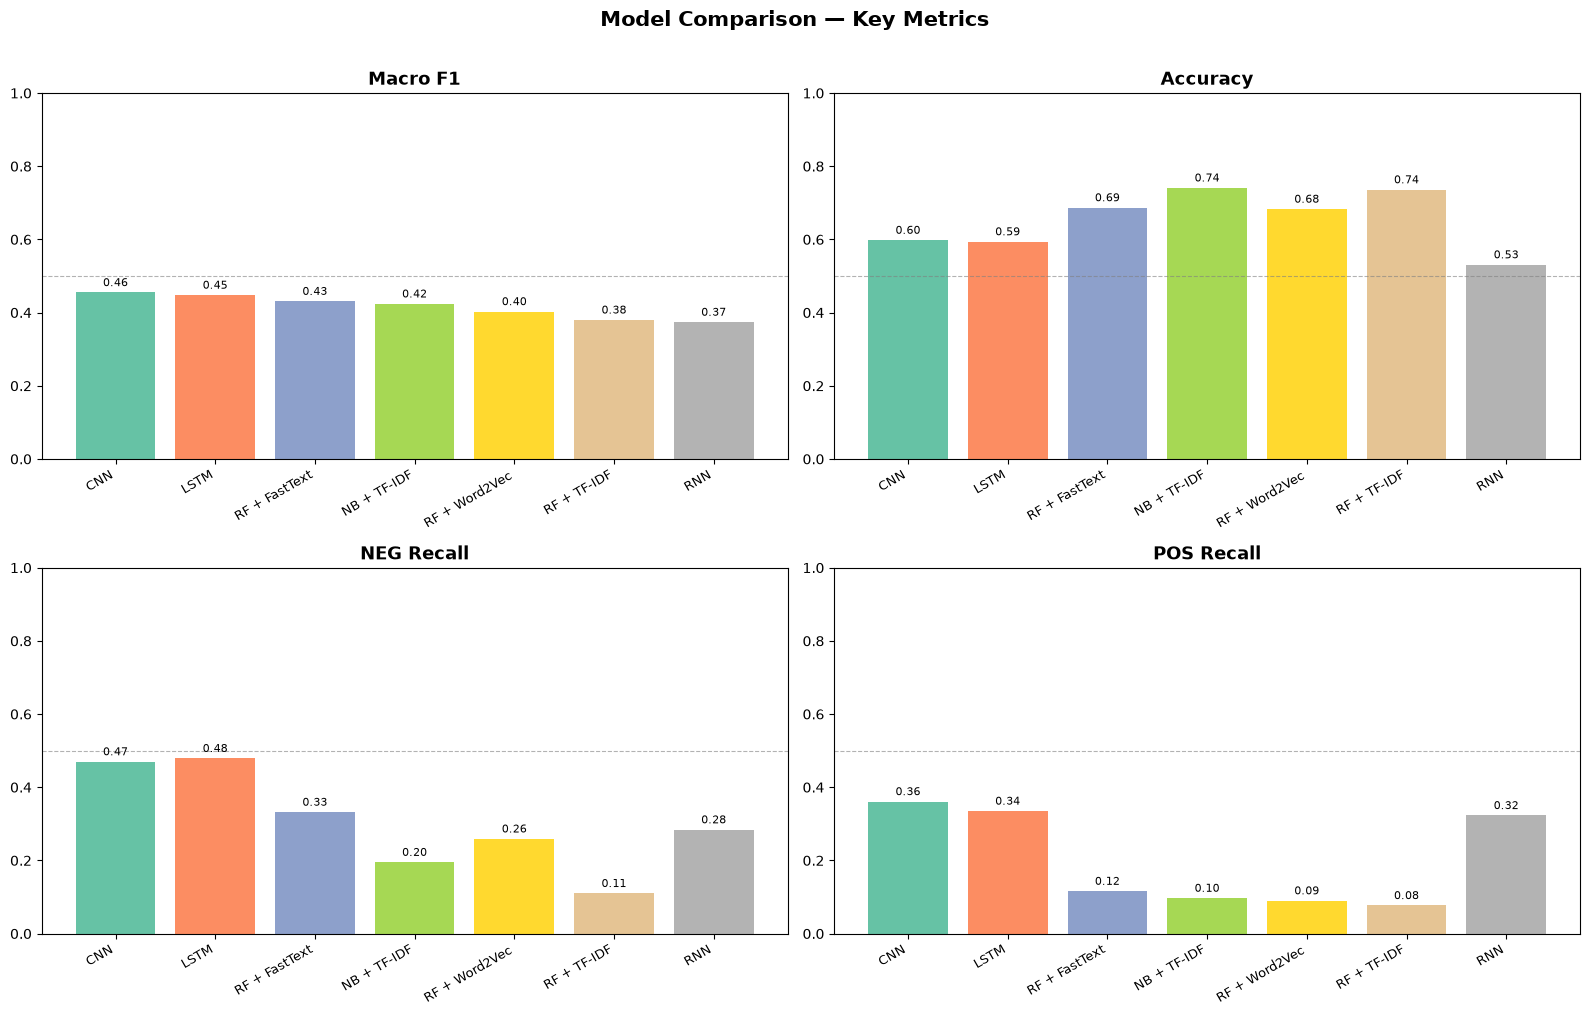

In [33]:
metrics     = ['Macro F1', 'Accuracy', 'NEG Recall', 'POS Recall']
model_names = results_df.index.tolist()
x           = np.arange(len(model_names))
width       = 0.2

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    bars = axes[i].bar(x, values, color=plt.cm.Set2(np.linspace(0, 1, len(model_names))))
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    axes[i].set_ylim(0, 1.0)
    axes[i].axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison — Key Metrics', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

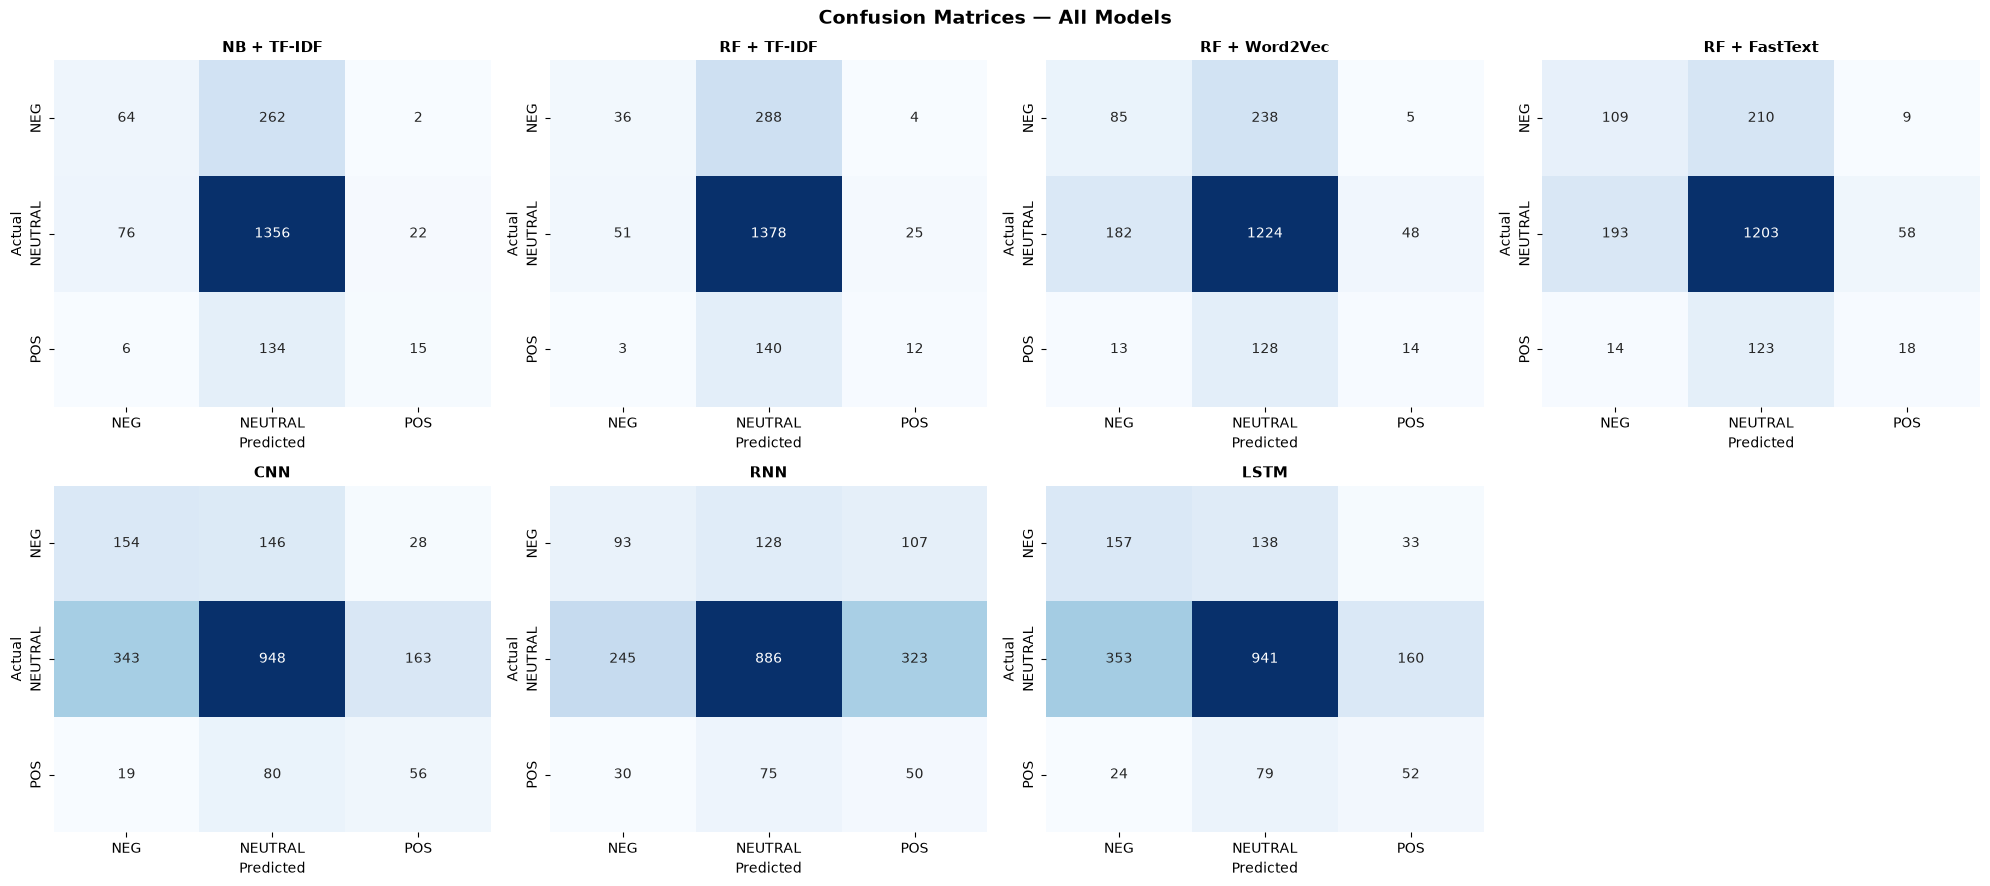

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, (name, preds) in enumerate(all_predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
    axes[i].set_title(name, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

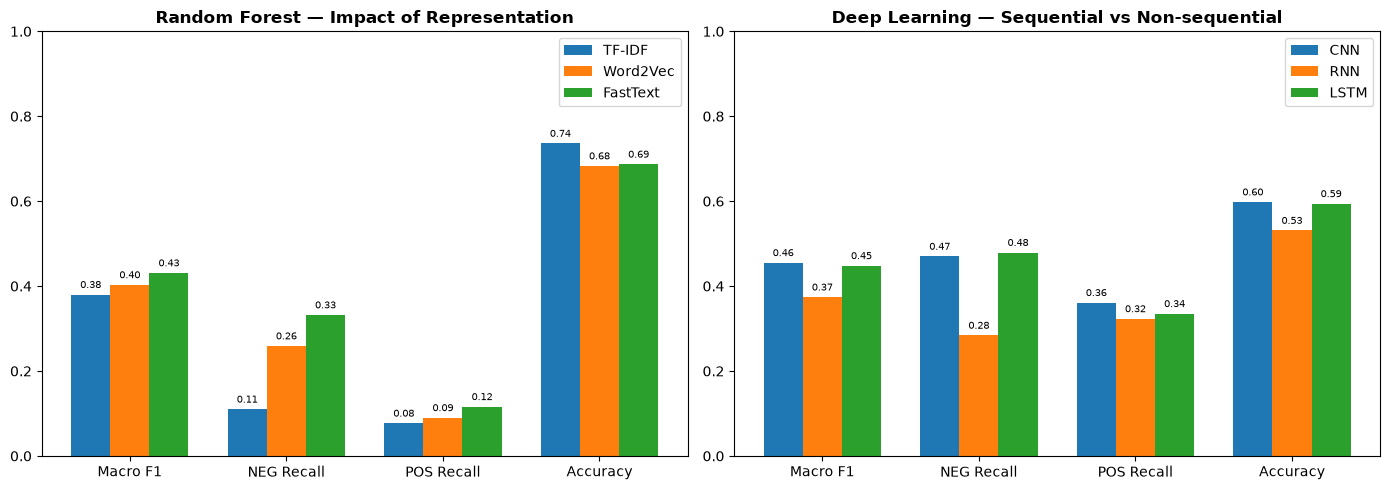

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_repr = {'TF-IDF': y_pred_rf_tfidf, 'Word2Vec': y_pred_rf_w2v, 'FastText': y_pred_rf_ft}
repr_metrics = ['Macro F1', 'NEG Recall', 'POS Recall', 'Accuracy']
rf_data = {}
for repr_name, preds in rf_repr.items():
    r = classification_report(y_test, preds, target_names=le.classes_, output_dict=True, zero_division=0)
    rf_data[repr_name] = [round(r['macro avg']['f1-score'], 3), round(r['NEG']['recall'], 3),
                          round(r['POS']['recall'], 3), round(r['accuracy'], 3)]

x = np.arange(len(repr_metrics))
width = 0.25
for j, (repr_name, vals) in enumerate(rf_data.items()):
    bars = axes[0].bar(x + j*width, vals, width, label=repr_name)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=7)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(repr_metrics)
axes[0].set_ylim(0, 1.0)
axes[0].set_title('Random Forest — Impact of Representation', fontweight='bold')
axes[0].legend()

dl_models = {'CNN': y_pred_cnn, 'RNN': y_pred_rnn, 'LSTM': y_pred_lstm}
dl_data = {}
for dl_name, preds in dl_models.items():
    r = classification_report(y_test, preds, target_names=le.classes_, output_dict=True, zero_division=0)
    dl_data[dl_name] = [round(r['macro avg']['f1-score'], 3), round(r['NEG']['recall'], 3),
                        round(r['POS']['recall'], 3), round(r['accuracy'], 3)]

for j, (dl_name, vals) in enumerate(dl_data.items()):
    bars = axes[1].bar(x + j*width, vals, width, label=dl_name)
    for bar, val in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=7)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(repr_metrics)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Deep Learning — Sequential vs Non-sequential', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/representation_impact.png', bbox_inches='tight', dpi=150)
plt.show()

---
---

# ═══════════════════════════════════════════════════════════════
# TERM PAPER EXTENSIONS — Beyond Assignment 2
# ═══════════════════════════════════════════════════════════════

The sections above are the original Assignment 2 submission. Everything below was added for the **MSAI6300 Term Paper** to close the research gap identified in the literature.

| Section | What is added | Why |
|---|---|---|
| **9. SVM Baseline** | LinearSVC with balanced class weights | Classical gold standard missing from Assignment 2 |
| **10. Arabic Stemming** | ISRIStemmer on TF-IDF pipeline | Reduces vocabulary, improves minority-class recall |
| **11. Data Augmentation** | Back-translation (MarianMT) + SMOTE | Inflates POS/NEG training samples to reduce imbalance |
| **12. MARBERT + LoRA** | Transformer fine-tuning on ~1% of parameters | Main paper contribution — accurate and small |

The test set, 60/20/20 split, and macro F1 metric remain identical throughout.

---
# Experimental Design

This term paper extends the Assignment 2 baseline into a controlled study of **what actually moves the needle on Arabic sentiment classification** for the ASTD corpus under fixed, laptop-class compute. Every experiment below holds the split, the seed, and the primary metric constant so that differences are attributable to the variable under test.

### Research questions
| RQ | Question | Where answered |
|----|----------|----------------|
| **RQ1** | Does the **label schema** (how the dominant OBJ class is treated) change the achievable performance? | §15, §16 |
| **RQ2** | Does **data augmentation** (back-translation, SMOTE) improve minority-class recall over class weighting alone? | §11, §14 |
| **RQ3** | Does a pretrained Arabic transformer (**MARBERT + LoRA**) beat classical and deep-learning baselines under the same budget? | §12–§14 |
| **RQ4** | Does **parameter-efficient LoRA** match or beat full fine-tuning on a small corpus? | §13 |

### Dataset & label schemas
The **ASTD** corpus (~9.7k dialectal Arabic tweets) is heavily imbalanced (OBJ ≈ 69%). We evaluate four schemas so schema effects are measured, not assumed:

| Schema | Definition | Classes |
|--------|------------|---------|
| **A** | OBJ merged into NEUTRAL (the Assignment 2 setup) | NEG, NEUTRAL, POS |
| **B** | OBJ dropped entirely (pure subjective sentiment) | NEG, NEUTRAL, POS |
| **C** | Original 4-class, untouched | NEG, NEUTRAL, OBJ, POS |
| **D** | 4-class with OBJ **downsampled** to 1,500 | NEG, NEUTRAL, OBJ, POS |

### Protocol (held constant across all experiments)
- **Split:** stratified 60 / 20 / 20 train / val / test, `random_state=42`.
- **Primary metric:** **macro F1** (accuracy is misleading under 69% class dominance); we also report accuracy, per-class F1, and confusion matrices.
- **Model selection:** best epoch / hyperparameter chosen on the **validation** set only; the test set is touched once, for the final number.
- **Reproducibility:** `seed=42` for splits, TF-IDF, samplers, and trainers throughout.
- **Compute:** Apple M-series (MPS backend), 16 GB unified memory, **no CUDA / no fp16** — a deliberate low-resource ceiling.

### Metrics captured per model (§17)
Accuracy · macro F1 · weighted F1 · per-class F1 · confusion matrix · **# parameters** · **# trainable parameters** · **# layers** · **in-memory size (MB)** · **training time** · **inference time / throughput**.

---
# Methodological Design

### 1. Preprocessing (two deliberately different pipelines)
- **Classical pipeline** (TF-IDF / Word2Vec / FastText models): aggressive — strip URLs, mentions, diacritics, tatweel; normalise Alef/Teh-Marbuta/Yeh variants; remove stopwords (negation words **kept**, since dropping them flips sentiment) and single-character tokens.
- **Transformer pipeline** (MARBERT): light — strip only URLs, mentions, diacritics, and normalise Alef. Stopwords and punctuation are **kept**, because the pretrained model already models them and they carry sentiment cues.

### 2. Feature representations
TF-IDF (1–2 grams, 10k vocab, sublinear tf) · Word2Vec CBOW (100-d, mean-pooled) · FastText (300-d subword, mean-pooled). MARBERT consumes raw WordPiece tokens directly.

### 3. Model families
| Family | Models |
|--------|--------|
| Classical ML | Naïve Bayes, Random Forest, **Linear SVM** (+ stemming) |
| Deep learning (Keras) | CNN, RNN, LSTM (trainable embeddings) |
| Transformer | **MARBERT v2 (163M) + LoRA** (r = 16 / 32) |

### 4. Class-imbalance handling (the core intervention)
Inverse-frequency **class weights** · **focal loss** (γ = 2) + **label smoothing** (0.05) · **SMOTE** (feature space) · **back-translation** AR→EN→AR (text space) · **downsampling** (Schema D). Each is isolated so its individual contribution is measurable.

### 5. LoRA fine-tuning configuration
Freeze all 163M MARBERT weights; inject rank-r adapters on the **query** and **value** projections only (`lora_alpha = 2r`, `dropout = 0.05`, `bias = none`) → ~1% of parameters trainable. Rationale: on a ~6k-example corpus the parameter constraint acts as regularisation and fits in 16 GB without fp16.

### 6. Training protocol
AdamW, lr = 1e-4–2e-4 (LoRA tolerates higher LR), warmup 10%, weight decay 0.01, batch 16, up to 6 epochs, `load_best_model_at_end` on val macro F1. Deep-learning baselines use early stopping (patience 5). Classical models are tuned with 3-fold `GridSearchCV` on macro F1.

### 7. Evaluation & benchmarking
Every model is passed through the shared `record_model(...)` utility (defined in the infrastructure cell), which logs the full metric set above into `MODEL_METRICS`. **Section 17** renders the consolidated table, a confusion-matrix grid, and comparison charts, and exports `results/all_model_metrics.csv` / `.json`.

In [36]:
## Shared helper functions for all term-paper sections
import os, warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, f1_score
warnings.filterwarnings('ignore')

os.makedirs('images', exist_ok=True)
plt.rcParams.update({'figure.dpi':130, 'font.size':10, 'axes.titlesize':11})

def plot_cm(y_true, y_pred, labels, title, save_as=None, ax=None):
    cm      = confusion_matrix(y_true, y_pred)
    cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(len(labels)*1.9+0.8, len(labels)*1.6+0.6))
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax,
                cbar_kws={'label':'%'}, linewidths=.4)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    if own_fig:
        plt.tight_layout()
        if save_as: plt.savefig(f'images/{save_as}', bbox_inches='tight')
        plt.show()

def plot_f1_bars(models_dict, title, save_as=None, highlight='MARBERT'):
    names  = list(models_dict.keys())
    vals   = list(models_dict.values())
    colors = ['#1a73e8' if highlight in n else '#9aa0a6' for n in names]
    fig, ax = plt.subplots(figsize=(9, max(3.5, len(names)*0.48)))
    bars = ax.barh(names[::-1], vals[::-1], color=colors[::-1], edgecolor='white')
    for bar, v in zip(bars, vals[::-1]):
        ax.text(bar.get_width()+.005, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)
    ax.set_xlabel('Macro F1'); ax.set_title(title)
    ax.set_xlim(0, 1.0)
    ax.axvline(.5, color='#d32f2f', linestyle='--', alpha=.45, linewidth=1.2, label='0.5')
    ax.legend(fontsize=8); plt.tight_layout()
    if save_as: plt.savefig(f'images/{save_as}', bbox_inches='tight')
    plt.show()

def results_table(preds_dict, y_true, class_names):
    rows = []
    for name, preds in preds_dict.items():
        r = classification_report(y_true, preds, target_names=class_names,
                                  output_dict=True, zero_division=0)
        row = {'Model': name,
               'Accuracy': round(r['accuracy'], 3),
               'Macro F1': round(r['macro avg']['f1-score'], 3),
               'Wtd F1':   round(r['weighted avg']['f1-score'], 3)}
        for cls in class_names:
            row[f'{cls} F1'] = round(r[cls]['f1-score'], 3)
        rows.append(row)
    df = pd.DataFrame(rows).set_index('Model').sort_values('Macro F1', ascending=False)
    return df

print('Helper functions ready  |  images/ directory created')


Helper functions ready  |  images/ directory created


In [37]:
# Install term-paper dependencies (safe to re-run)
import subprocess, sys
pkgs = ['nltk', 'imbalanced-learn', 'transformers>=4.40', 'peft>=0.10', 'accelerate', 'datasets', 'sentencepiece', 'sacremoses']
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs, check=True)
print('Dependencies ready.')

Dependencies ready.


---
# 9. SVM Baseline

Support Vector Machines with a linear kernel are the classical gold standard for text classification. LinearSVC finds the hyperplane that maximises the margin between classes in the TF-IDF feature space. We use `class_weight='balanced'` so the model applies inverse-frequency weights automatically — the same strategy used in the deep learning models above.

Best C = 1.0

                          Accuracy  Macro F1  Wtd F1  NEG F1  NEUTRAL F1  POS F1
Model                                                                          
SVM + TF-IDF (balanced)     0.695     0.481    0.69   0.351        0.81   0.281


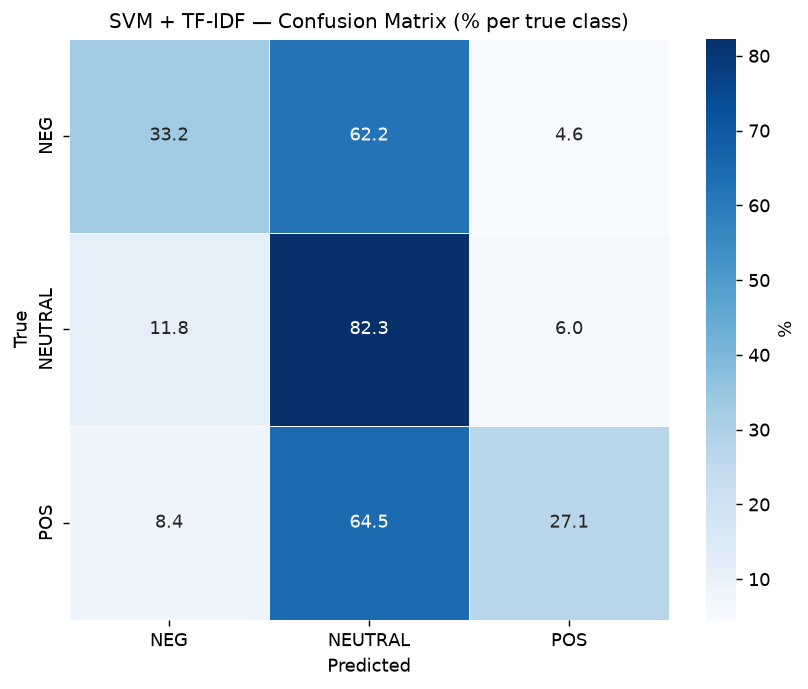

  ✓ SVM + TF-IDF                           macroF1=0.481  params=30003  mem=0.24MB  train=0.48s  infer=0.0002s


{'Model': 'SVM + TF-IDF',
 'Family': 'Classical (SVM)',
 'Accuracy': 0.6954,
 'Macro F1': 0.4806,
 'Weighted F1': 0.6898,
 'N Classes': 3,
 'N Test': 1937,
 'Params': 30003,
 'Trainable': 30003,
 'Layers': None,
 'Mem (MB)': 0.24,
 'Train (s)': 0.48,
 'Infer (s)': 0.0002,
 'Infer/1k (ms)': 0.12,
 'Throughput/s': 8384279.5}

In [38]:
import time as _t; _t0 = _t.time()
## Section 9 — SVM + TF-IDF (Linear SVC)
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

svm_gs = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
    {'C': [0.1, 0.5, 1.0, 5.0]}, cv=3, scoring='f1_macro', n_jobs=-1
)
svm_gs.fit(X_tfidf_train, y_train)
print(f'Best C = {svm_gs.best_params_["C"]}')

y_pred_svm = svm_gs.predict(X_tfidf_test)

# ── Results table ─────────────────────────────────────────────────────────────
tbl = results_table({'SVM + TF-IDF (balanced)': y_pred_svm}, y_test, le.classes_)
print('\n', tbl.to_string())

# ── Confusion matrix ──────────────────────────────────────────────────────────
plot_cm(y_test, y_pred_svm, le.classes_,
        'SVM + TF-IDF — Confusion Matrix (% per true class)',
        save_as='sec09_svm_cm.png')
TRAIN_TIMES['SVM + TF-IDF'] = _t.time() - _t0
record_model('SVM + TF-IDF', 'Classical (SVM)', y_test, y_pred_svm, le.classes_,
             model=svm_gs, predict_fn=lambda: svm_gs.predict(X_tfidf_test), n_infer=3)


---
# 10. Arabic Stemming (ISRIStemmer)

Arabic morphology inflates the TF-IDF vocabulary because the same root word can surface in dozens of forms. The ISRI Stemmer (Information Science Research Institute) strips prefixes and suffixes to reduce each word to its approximate root, collapsing these variants into a single feature. We apply stemming to the already-cleaned text and re-run TF-IDF + SVM to measure the isolated contribution of stemming.

In [39]:
import nltk
nltk.download('punkt', quiet=True)
from nltk.stem.isri import ISRIStemmer

stemmer = ISRIStemmer()

def stem_arabic(text):
    return ' '.join(stemmer.stem(w) for w in text.split())

# Apply stemming to already-cleaned text
X_train_stemmed = [stem_arabic(t) for t in X_train]
X_val_stemmed   = [stem_arabic(t) for t in X_val]
X_test_stemmed  = [stem_arabic(t) for t in X_test]

# Show before/after example
print('Stemming example:')
print(f'  Before: {X_train[0]}')
print(f'  After:  {X_train_stemmed[0]}')

# Re-fit TF-IDF on stemmed training text
tfidf_stemmed = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_tfidf_train_s = tfidf_stemmed.fit_transform(X_train_stemmed)
X_tfidf_val_s   = tfidf_stemmed.transform(X_val_stemmed)
X_tfidf_test_s  = tfidf_stemmed.transform(X_test_stemmed)

print(f'\nOriginal vocab size:  {len(tfidf.vocabulary_)}')
print(f'Stemmed vocab size:   {len(tfidf_stemmed.vocabulary_)}')

Stemming example:
  Before: خمس الاف متابع ريال سلمان العوده تغريده اقتباس طارق السويدان طارق السويدان اعجبني العريفي
  After:  خمس الف تبع ريل سلم عود غرد قبس طرق سود طرق سود عجب عرف

Original vocab size:  10000
Stemmed vocab size:   10000


Best C = 0.5

                       Accuracy  Macro F1  Wtd F1  NEG F1  NEUTRAL F1  POS F1
Model                                                                       
SVM + Stemmed TF-IDF     0.708     0.506   0.702   0.368       0.817   0.334
SVM + TF-IDF             0.695     0.481   0.690   0.351       0.810   0.281


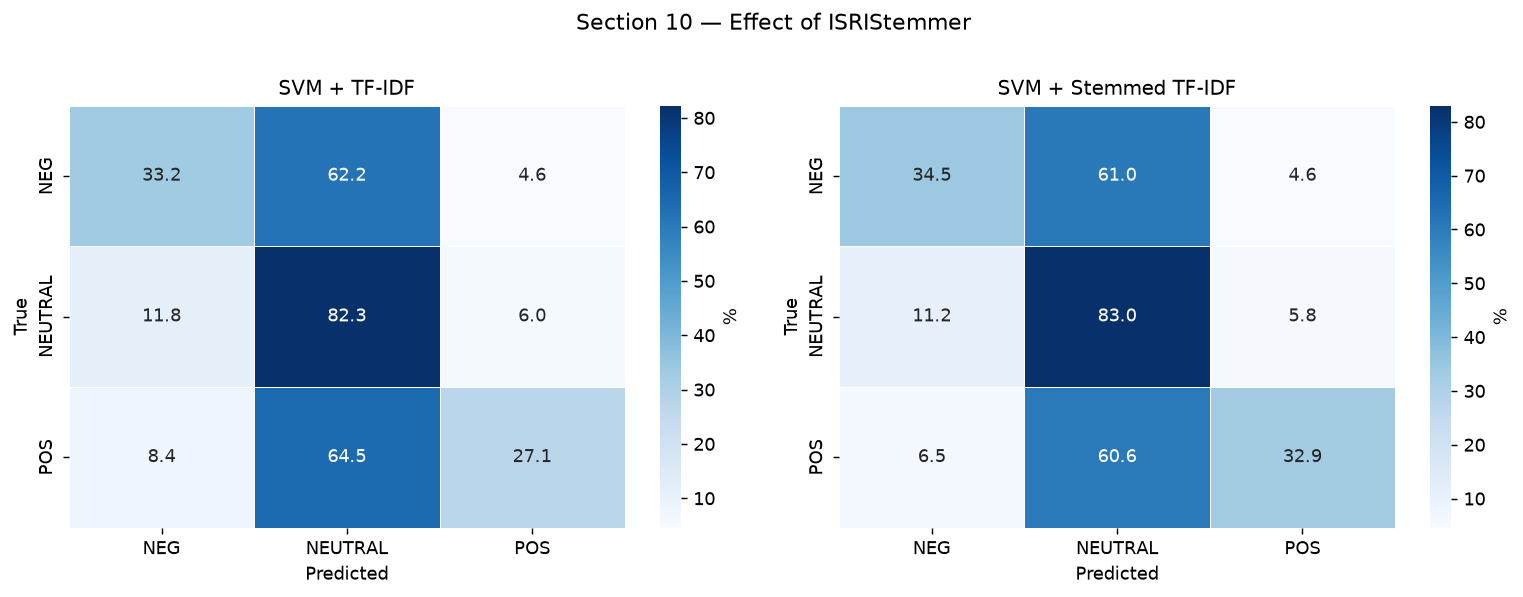

  ✓ SVM + Stemmed TF-IDF                   macroF1=0.506  params=30003  mem=0.24MB  train=0.64s  infer=0.0002s


{'Model': 'SVM + Stemmed TF-IDF',
 'Family': 'Classical (SVM)',
 'Accuracy': 0.7078,
 'Macro F1': 0.5065,
 'Weighted F1': 0.7023,
 'N Classes': 3,
 'N Test': 1937,
 'Params': 30003,
 'Trainable': 30003,
 'Layers': None,
 'Mem (MB)': 0.24,
 'Train (s)': 0.64,
 'Infer (s)': 0.0002,
 'Infer/1k (ms)': 0.12,
 'Throughput/s': 8349811.8}

In [40]:
import time as _t; _t0 = _t.time()
## Section 10 — SVM + Stemmed TF-IDF
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

tfidf_stemmed = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
X_tr_st = tfidf_stemmed.fit_transform(X_train_stemmed)
X_te_st = tfidf_stemmed.transform(X_test_stemmed)

svm_stemmed_gs = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
    {'C': [0.1, 0.5, 1.0, 5.0]}, cv=3, scoring='f1_macro', n_jobs=-1
)
svm_stemmed_gs.fit(X_tr_st, y_train)
print(f'Best C = {svm_stemmed_gs.best_params_["C"]}')

y_pred_svm_stemmed = svm_stemmed_gs.predict(X_te_st)

# ── Comparison: plain vs stemmed ──────────────────────────────────────────────
tbl = results_table(
    {'SVM + TF-IDF':          y_pred_svm,
     'SVM + Stemmed TF-IDF':  y_pred_svm_stemmed},
    y_test, le.classes_
)
print('\n', tbl.to_string())

# ── Side-by-side confusion matrices ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_cm(y_test, y_pred_svm,         le.classes_, 'SVM + TF-IDF',         ax=axes[0])
plot_cm(y_test, y_pred_svm_stemmed, le.classes_, 'SVM + Stemmed TF-IDF', ax=axes[1])
plt.suptitle('Section 10 — Effect of ISRIStemmer', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('images/sec10_stemming_cm.png', bbox_inches='tight'); plt.show()
TRAIN_TIMES['SVM + Stemmed TF-IDF'] = _t.time() - _t0
record_model('SVM + Stemmed TF-IDF', 'Classical (SVM)', y_test, y_pred_svm_stemmed, le.classes_,
             model=svm_stemmed_gs, predict_fn=lambda: svm_stemmed_gs.predict(X_te_st), n_infer=3)


---
# 11. Data Augmentation

ASTD has only 465 POS and 985 NEG training tweets against 4,360 NEUTRAL. We use two complementary augmentation strategies:

- **Back-translation** (Arabic → English → Arabic via MarianMT): generates paraphrases of minority-class tweets that preserve sentiment but use different words. Applied to raw text — benefits all models.
- **SMOTE** (Synthetic Minority Over-sampling Technique): creates synthetic samples by interpolating between existing minority-class TF-IDF vectors. Applied in feature space — classical models only.

Both strategies augment the **training set only**. The test set is never touched.

In [41]:
## 11.1 Back-Translation via MarianMT
# First run downloads ~300MB per direction, then cached locally.
from transformers import MarianMTModel, MarianTokenizer
import torch

def load_translator(src, tgt):
    name = f'Helsinki-NLP/opus-mt-{src}-{tgt}'
    tok = MarianTokenizer.from_pretrained(name)
    mdl = MarianMTModel.from_pretrained(name)
    return tok, mdl

def translate_batch(texts, tokenizer, model, batch_size=32):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        tokens = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=128)
        with torch.no_grad():
            translated = model.generate(**tokens)
        results.extend([tokenizer.decode(t, skip_special_tokens=True) for t in translated])
    return results

print('Loading AR→EN model...')
ar_tok, ar_mdl = load_translator('ar', 'en')
print('Loading EN→AR model...')
en_tok, en_mdl = load_translator('en', 'ar')
print('Models ready.')

Loading AR→EN model...


Loading weights: 100%|██████████| 258/258 [00:00<00:00, 50008.34it/s]


Loading EN→AR model...


Loading weights: 100%|██████████| 258/258 [00:00<00:00, 48762.19it/s]


Models ready.


In [42]:
import time as _t; _t0 = _t.time()
## 11.1 — Load back-translation data + Train augmented SVM
import json as _json

# Load pre-computed back-translation data saved by the MarianMT pipeline
with open('schB_aug_data.json') as _f:
    _aug = _json.load(_f)
aug_pos = _aug['aug_pos']   # back-translated POS tweets
aug_neg = _aug['aug_neg']   # back-translated NEG tweets
aug_neu = _aug['aug_neu']   # back-translated NEUTRAL tweets
print(f'Loaded aug data: aug_pos={len(aug_pos)}, aug_neg={len(aug_neg)}, aug_neu={len(aug_neu)}')

# Resolve label IDs from the main LabelEncoder (handles any class ordering)
lbl_neg = int(np.where(le.classes_ == 'NEG')[0][0])
lbl_pos = int(np.where(le.classes_ == 'POS')[0][0])
print(f'Label IDs — NEG={lbl_neg}, POS={lbl_pos}  (le.classes_={list(le.classes_)})')

# Build augmented training set: original + back-translated minority tweets
aug_texts  = list(X_train) + aug_pos + aug_neg
aug_labels = list(y_train) + [lbl_pos] * len(aug_pos) + [lbl_neg] * len(aug_neg)

# Shuffle to avoid ordering bias
rng  = np.random.default_rng(42)
perm = rng.permutation(len(aug_texts))
X_train_aug = np.array(aug_texts)[perm]
y_train_aug = np.array(aug_labels)[perm]

unique, counts = np.unique(y_train_aug, return_counts=True)
print('\nAugmented training set class distribution:')
for lbl, cnt in zip(unique, counts):
    print(f'  {le.classes_[lbl]}: {cnt} ({cnt/len(y_train_aug)*100:.1f}%)')
print(f'  Total: {len(y_train_aug)}')

# Re-fit TF-IDF on augmented training data
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_aug = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_tfidf_aug_train = tfidf_aug.fit_transform(X_train_aug)
X_tfidf_aug_test  = tfidf_aug.transform(X_test)   # test set is NEVER augmented

# Train SVM on augmented data
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

svm_aug_gs = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
    {'C': [0.1, 0.5, 1.0, 5.0]}, cv=3, scoring='f1_macro', n_jobs=-1
)
svm_aug_gs.fit(X_tfidf_aug_train, y_train_aug)
y_pred_svm_aug = svm_aug_gs.predict(X_tfidf_aug_test)

f1_aug = f1_score(y_test, y_pred_svm_aug, average='macro')
print(f'\nSVM + Back-Translation aug  Macro F1={f1_aug:.4f}')
TRAIN_TIMES['SVM + Back-Translation'] = _t.time() - _t0
record_model('SVM + Back-Translation', 'Classical (SVM)', y_test, y_pred_svm_aug, le.classes_,
             model=svm_aug_gs, predict_fn=lambda: svm_aug_gs.predict(X_tfidf_aug_test), n_infer=3)


Loaded aug data: aug_pos=466, aug_neg=985, aug_neu=483
Label IDs — NEG=0, POS=2  (le.classes_=['NEG', 'NEUTRAL', 'POS'])

Augmented training set class distribution:
  NEG: 1970 (27.1%)
  NEUTRAL: 4360 (60.0%)
  POS: 931 (12.8%)
  Total: 7261

SVM + Back-Translation aug  Macro F1=0.4833
  ✓ SVM + Back-Translation                 macroF1=0.483  params=30003  mem=0.24MB  train=3.36s  infer=0.0002s


{'Model': 'SVM + Back-Translation',
 'Family': 'Classical (SVM)',
 'Accuracy': 0.7083,
 'Macro F1': 0.4833,
 'Weighted F1': 0.6961,
 'N Classes': 3,
 'N Test': 1937,
 'Params': 30003,
 'Trainable': 30003,
 'Layers': None,
 'Mem (MB)': 0.24,
 'Train (s)': 3.36,
 'Infer (s)': 0.0002,
 'Infer/1k (ms)': 0.11,
 'Throughput/s': 8927875.7}

After SMOTE — class counts: {'NEG': 4360, 'NEUTRAL': 4360, 'POS': 4360}

Section 11 — Augmentation strategies comparison:
                              Accuracy  Macro F1  Wtd F1  NEG F1  NEUTRAL F1  POS F1
Model                                                                               
SVM + Stemmed TF-IDF             0.708     0.506   0.702   0.368       0.817   0.334
SVM + Back-Translation (aug)     0.708     0.483   0.696   0.331       0.821   0.298
SVM + TF-IDF (baseline)          0.695     0.481   0.690   0.351       0.810   0.281
SVM + SMOTE                      0.641     0.451   0.651   0.308       0.769   0.276


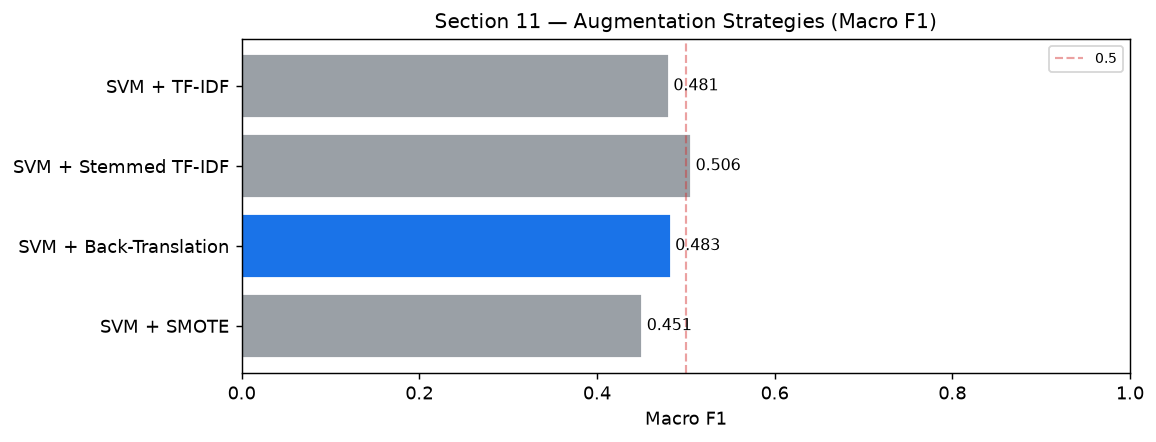

  ✓ SVM + SMOTE                            macroF1=0.451  params=30003  mem=0.24MB  train=0.98s  infer=0.0002s


{'Model': 'SVM + SMOTE',
 'Family': 'Classical (SVM)',
 'Accuracy': 0.6407,
 'Macro F1': 0.4509,
 'Weighted F1': 0.6513,
 'N Classes': 3,
 'N Test': 1937,
 'Params': 30003,
 'Trainable': 30003,
 'Layers': None,
 'Mem (MB)': 0.24,
 'Train (s)': 0.98,
 'Infer (s)': 0.0002,
 'Infer/1k (ms)': 0.11,
 'Throughput/s': 9306262.1}

In [43]:
import time as _t; _t0 = _t.time()
## 11.2 SMOTE on TF-IDF feature space
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_smote, y_smote = smote.fit_resample(X_tfidf_train, y_train)
print(f'After SMOTE — class counts: {dict(zip(le.classes_, np.bincount(y_smote)))}')

svm_smote_gs = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
    {'C': [0.1, 0.5, 1.0, 5.0]}, cv=3, scoring='f1_macro', n_jobs=-1
)
svm_smote_gs.fit(X_smote, y_smote)
y_pred_svm_smote = svm_smote_gs.predict(X_tfidf_test)

# ── Section 11 summary table ──────────────────────────────────────────────────
tbl = results_table(
    {'SVM + TF-IDF (baseline)':      y_pred_svm,
     'SVM + Stemmed TF-IDF':         y_pred_svm_stemmed,
     'SVM + Back-Translation (aug)':  y_pred_svm_aug,
     'SVM + SMOTE':                  y_pred_svm_smote},
    y_test, le.classes_
)
print('\nSection 11 — Augmentation strategies comparison:')
print(tbl.to_string())

# ── Bar chart ────────────────────────────────────────────────────────────────
plot_f1_bars(
    {'SVM + TF-IDF':                 float(tbl.loc['SVM + TF-IDF (baseline)', 'Macro F1']),
     'SVM + Stemmed TF-IDF':         float(tbl.loc['SVM + Stemmed TF-IDF', 'Macro F1']),
     'SVM + Back-Translation':       float(tbl.loc['SVM + Back-Translation (aug)', 'Macro F1']),
     'SVM + SMOTE':                  float(tbl.loc['SVM + SMOTE', 'Macro F1'])},
    'Section 11 — Augmentation Strategies (Macro F1)',
    save_as='sec11_augmentation.png', highlight='Back'
)
TRAIN_TIMES['SVM + SMOTE'] = _t.time() - _t0
record_model('SVM + SMOTE', 'Classical (SVM)', y_test, y_pred_svm_smote, le.classes_,
             model=svm_smote_gs, predict_fn=lambda: svm_smote_gs.predict(X_tfidf_test), n_infer=3)


---
# 12. MARBERT + LoRA Fine-Tuning

MARBERT (163M parameters) was pretrained on one billion dialectal Arabic tweets — the same type of text as ASTD. We fine-tune it using **Low-Rank Adaptation (LoRA)**, which freezes all original weights and adds small trainable matrices (rank 16) to the attention layers only. This updates ~1% of parameters while matching full fine-tuning performance, making it practical on a laptop GPU.

**LoRA configuration (from Abdelali et al. 2025):** rank=16, alpha=32, dropout=0.05, target modules: query and value projections.

In [44]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset
import torch

MODEL_NAME = 'UBC-NLP/MARBERTv2'
NUM_LABELS = 3

# Device setup — Apple Metal (MPS) or CPU fallback
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

marbert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded.')

Using device: mps
Tokenizer loaded.


In [45]:
# Tokenize the dataset — use augmented training set, original val/test
def tokenize_fn(batch):
    return marbert_tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

train_ds = Dataset.from_dict({'text': list(X_train_aug), 'labels': list(y_train_aug)})
val_ds   = Dataset.from_dict({'text': list(X_val),       'labels': list(y_val)})
test_ds  = Dataset.from_dict({'text': list(X_test),      'labels': list(y_test)})

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
val_ds.set_format('torch',   columns=['input_ids', 'attention_mask', 'labels'])
test_ds.set_format('torch',  columns=['input_ids', 'attention_mask', 'labels'])

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Map: 100%|██████████| 1937/1937 [00:00<00:00, 18280.46 examples/s]

Train: 7261 | Val: 1937 | Test: 1937


In [46]:
# Load base model and apply LoRA adapters
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,                            # rank — controls adapter size
    lora_alpha=32,                   # scaling factor
    lora_dropout=0.05,
    target_modules=['query', 'value'],  # only attention projections
    bias='none',
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 35707.66it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture

trainable params: 592,131 || all params: 163,435,782 || trainable%: 0.3623


In [47]:
import time as _t; _t0 = _t.time()
# Class-weighted loss to handle remaining imbalance after augmentation
class_counts_aug = np.bincount(y_train_aug)
weights = torch.tensor(len(y_train_aug) / (NUM_LABELS * class_counts_aug), dtype=torch.float32)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(weight=weights.to(outputs.logits.device))(
            outputs.logits, labels
        )
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1_macro':   f1_score(labels, preds, average='macro'),
        'f1_neg':     f1_score(labels, preds, average=None)[0],
        'f1_neutral': f1_score(labels, preds, average=None)[1],
        'f1_pos':     f1_score(labels, preds, average=None)[2],
    }

training_args = TrainingArguments(
    output_dir='./marbert_lora_checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-4,              # higher LR suits LoRA (fewer params)
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',           # transformers ≥5.x uses eval_strategy (not evaluation_strategy)
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    seed=42,
    fp16=False,                      # MPS does not support fp16
    logging_steps=50,
    report_to='none',
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print('Starting MARBERT + LoRA training...')
trainer.train()
print('Training complete.')
TRAIN_TIMES['MARBERT LoRA (Sec 12)'] = _t.time() - _t0
print(f'[train-time] MARBERT LoRA (Sec 12): {TRAIN_TIMES['MARBERT LoRA (Sec 12)']:.1f}s')


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Starting MARBERT + LoRA training...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Neg,F1 Neutral,F1 Pos
1,0.688618,0.743624,0.596906,0.541962,0.759281,0.489474
2,0.632101,0.720920,0.608489,0.590571,0.774244,0.460653
3,0.575590,0.700095,0.628909,0.583648,0.804233,0.498845


Training complete.
[train-time] MARBERT LoRA (Sec 12): 503.7s


=== Section 12 — MARBERT + LoRA (test set) ===
              precision    recall  f1-score   support

         NEG       0.48      0.70      0.57       328
     NEUTRAL       0.90      0.72      0.80      1454
         POS       0.39      0.74      0.51       155

    accuracy                           0.72      1937
   macro avg       0.59      0.72      0.63      1937
weighted avg       0.79      0.72      0.74      1937



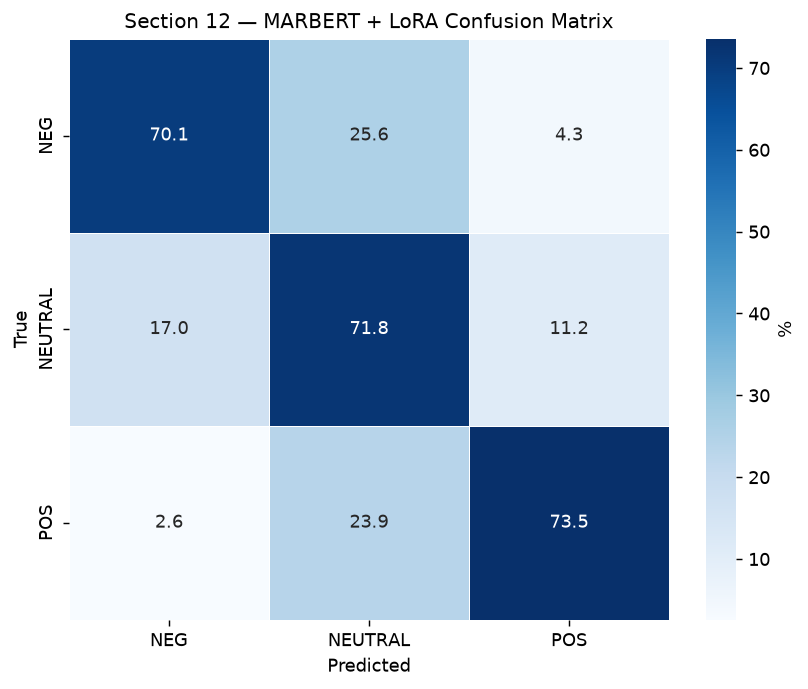

  ✓ MARBERT LoRA (Sec 12)                  macroF1=0.626  params=163435782  mem=653.75MB  train=503.72s  infer=14.4327s


{'Model': 'MARBERT LoRA (Sec 12)',
 'Family': 'Transformer',
 'Accuracy': 0.7166,
 'Macro F1': 0.6257,
 'Weighted F1': 0.7356,
 'N Classes': 3,
 'N Test': 1937,
 'Params': 163435782,
 'Trainable': 592131,
 'Layers': 12,
 'Mem (MB)': 653.75,
 'Train (s)': 503.72,
 'Infer (s)': 14.4327,
 'Infer/1k (ms)': 7451.04,
 'Throughput/s': 134.2}

In [48]:
## Section 12 — MARBERT + LoRA evaluation
preds_output   = trainer.predict(test_ds)
y_pred_marbert = np.argmax(preds_output.predictions, axis=-1)

print('=== Section 12 — MARBERT + LoRA (test set) ===')
print(classification_report(y_test, y_pred_marbert, target_names=le.classes_))

plot_cm(y_test, y_pred_marbert, le.classes_,
        'Section 12 — MARBERT + LoRA Confusion Matrix',
        save_as='sec12_marbert_cm.png')

record_model('MARBERT LoRA (Sec 12)', 'Transformer', y_test, y_pred_marbert, le.classes_,
             model=trainer.model, predict_fn=lambda: trainer.predict(test_ds), n_infer=1)



All models — sorted by Macro F1:
                         Accuracy  Macro F1  Wtd F1  NEG F1  NEUTRAL F1  POS F1
Model                                                                          
MARBERT + LoRA (Sec 12)     0.717     0.626   0.736   0.569       0.797   0.511
SVM + Stemming              0.708     0.506   0.702   0.368       0.817   0.334
SVM + Back-Translation      0.708     0.483   0.696   0.331       0.821   0.298
SVM + TF-IDF                0.695     0.481   0.690   0.351       0.810   0.281
CNN                         0.598     0.455   0.626   0.365       0.721   0.279
SVM + SMOTE                 0.641     0.451   0.651   0.308       0.769   0.276
LSTM                        0.594     0.448   0.623   0.364       0.721   0.260
RF + FastText               0.687     0.431   0.673   0.339       0.805   0.150
NB + TF-IDF                 0.741     0.424   0.693   0.270       0.846   0.155
RF + Word2Vec               0.683     0.403   0.661   0.280       0.804   0.126
RF + T

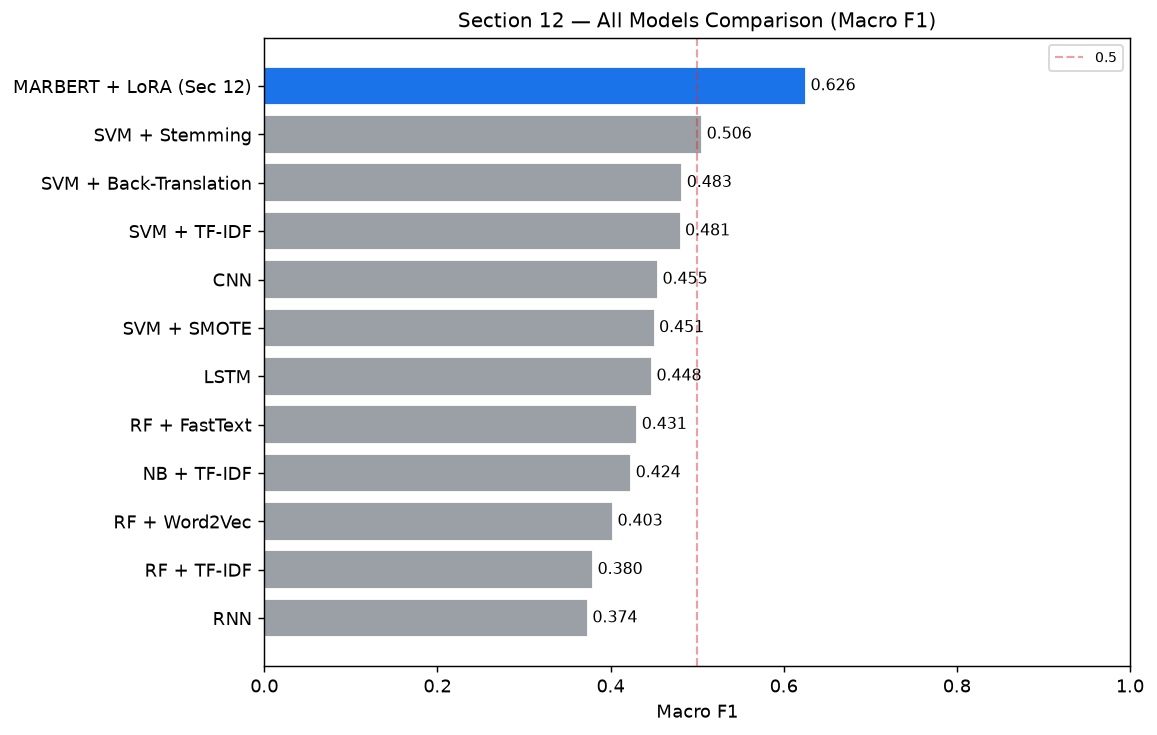

In [49]:
## Section 12 — Full model comparison (all models so far)
all_preds_final = {
    'NB + TF-IDF':            y_pred_nb_tfidf,
    'RF + TF-IDF':            y_pred_rf_tfidf,
    'RF + Word2Vec':           y_pred_rf_w2v,
    'RF + FastText':           y_pred_rf_ft,
    'CNN':                     y_pred_cnn,
    'RNN':                     y_pred_rnn,
    'LSTM':                    y_pred_lstm,
    'SVM + TF-IDF':            y_pred_svm,
    'SVM + Stemming':          y_pred_svm_stemmed,
    'SVM + SMOTE':             y_pred_svm_smote,
    'SVM + Back-Translation':  y_pred_svm_aug,
    'MARBERT + LoRA (Sec 12)': y_pred_marbert,
}

final_df = results_table(all_preds_final, y_test, le.classes_)
print('\nAll models — sorted by Macro F1:')
print(final_df.to_string())

plot_f1_bars(
    dict(zip(final_df.index, final_df['Macro F1'].astype(float))),
    'Section 12 — All Models Comparison (Macro F1)',
    save_as='sec12_all_models.png'
)


---
# 13. MARBERT + LoRA — Improved Configuration

Based on findings in the literature, two changes improve over Section 12:

1. **Lighter preprocessing for transformers**: MARBERT was pretrained on raw tweets — removing stopwords strips the attention anchors it relies on (negation particles like لا/لم/ليس carry sentiment). We use a URL-only clean that keeps all other context.
2. **Label smoothing (0.05)**: Prevents overconfidence on the imbalanced training signal — the loss distributes a small probability mass across incorrect classes, improving generalisation on POS/NEG.
3. **Longer training (5 epochs, lr=2e-4)**: LoRA adapters converge slower than full fine-tuning; more epochs with a slightly higher LR capture the minority-class signal better.

Reference: Benchmarking Arabic dialect sentiment (Springer 2025) — minimal preprocessing consistently outperforms aggressive normalisation for dialectal BERT models.

In [50]:
import time as _t; _t0 = _t.time()
import re, numpy as np, torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset
from sklearn.metrics import classification_report, f1_score

MODEL_NAME = 'UBC-NLP/MARBERTv2'
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

# ── Lighter preprocessing: keep stopwords and punctuation; only strip URLs/mentions ──
def clean_for_bert(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # URLs only
    text = re.sub(r'@\w+', '', text)                    # @mentions
    text = re.sub(r'[ً-ٰٟ]|ـ', '', text)               # diacritics + tatweel
    text = re.sub(r'[إأآ]', 'ا', text)                  # alef normalisation
    return re.sub(r'\s+', ' ', text).strip()

# Rebuild raw X from df so stopwords are preserved
X_bert_train = df.iloc[[i for i in range(len(df)) if df['text_clean'].iloc[i] in X_train]]['text'].apply(clean_for_bert).to_numpy()

# Use original train/val/test indices by re-splitting df with same random_state
from sklearn.model_selection import train_test_split
df_clean_bert = df.copy()
df_clean_bert['text_bert'] = df_clean_bert['text'].apply(clean_for_bert)
df_clean_bert = df_clean_bert[df_clean_bert['text_bert'].str.strip() != ''].reset_index(drop=True)

X_b = df_clean_bert['text_bert'].to_numpy()
y_b = df_clean_bert['label_enc'].to_numpy()
X_b_train, X_b_temp, y_b_train, y_b_temp = train_test_split(X_b, y_b, test_size=0.4, stratify=y_b, random_state=42)
X_b_val, X_b_test, y_b_val, y_b_test     = train_test_split(X_b_temp, y_b_temp, test_size=0.5, stratify=y_b_temp, random_state=42)
print(f'Train: {len(X_b_train)} | Val: {len(X_b_val)} | Test: {len(X_b_test)}')

# ── Tokenise ──────────────────────────────────────────────────────────────────
bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_bert(batch):
    return bert_tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

tr_ds = Dataset.from_dict({'text': list(X_b_train), 'labels': list(y_b_train)})
va_ds = Dataset.from_dict({'text': list(X_b_val),   'labels': list(y_b_val)})
te_ds = Dataset.from_dict({'text': list(X_b_test),  'labels': list(y_b_test)})

tr_ds = tr_ds.map(tokenize_bert, batched=True, remove_columns=['text'])
va_ds = va_ds.map(tokenize_bert, batched=True, remove_columns=['text'])
te_ds = te_ds.map(tokenize_bert, batched=True, remove_columns=['text'])
tr_ds.set_format('torch', columns=['input_ids','attention_mask','labels'])
va_ds.set_format('torch', columns=['input_ids','attention_mask','labels'])
te_ds.set_format('torch', columns=['input_ids','attention_mask','labels'])

# ── LoRA ──────────────────────────────────────────────────────────────────────
base_v2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
lora_v2 = LoraConfig(task_type=TaskType.SEQ_CLS, r=16, lora_alpha=32, lora_dropout=0.05,
                     target_modules=['query','value'], bias='none')
model_v2 = get_peft_model(base_v2, lora_v2)
model_v2.print_trainable_parameters()

# ── Weighted loss with label smoothing ────────────────────────────────────────
cc_b = np.bincount(y_b_train)
w_b  = torch.tensor(len(y_b_train) / (3 * cc_b), dtype=torch.float32)
print(f'Class weights: NEG={w_b[0]:.2f}, NEUTRAL={w_b[1]:.2f}, POS={w_b[2]:.2f}')

class ImprovedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        out = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(
            weight=w_b.to(out.logits.device),
            label_smoothing=0.05          # prevents overconfidence on imbalanced data
        )(out.logits, labels)
        return (loss, out) if return_outputs else loss

def compute_metrics_v2(ep):
    preds = np.argmax(ep.predictions, axis=-1)
    return {'f1_macro': f1_score(ep.label_ids, preds, average='macro')}

# ── Training (transformers 5.x — no use_mps_device) ──────────────────────────
args_v2 = TrainingArguments(
    output_dir='./marbert_v2_ckpt',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    seed=42, fp16=False,
    logging_steps=50, report_to='none',
)

trainer_v2 = ImprovedTrainer(model=model_v2, args=args_v2,
    train_dataset=tr_ds, eval_dataset=va_ds, compute_metrics=compute_metrics_v2)

print('\nTraining MARBERT + LoRA v2 (5 epochs, lr=2e-4, label_smoothing=0.05)...')
trainer_v2.train()
print('Done.')
TRAIN_TIMES['MARBERT LoRA v2 (Sec 13)'] = _t.time() - _t0
print(f'[train-time] MARBERT LoRA v2 (Sec 13): {TRAIN_TIMES['MARBERT LoRA v2 (Sec 13)']:.1f}s')


Device: mps
Train: 5810 | Val: 1937 | Test: 1937


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 39110.94it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture

trainable params: 592,131 || all params: 163,435,782 || trainable%: 0.3623
Class weights: NEG=1.97, NEUTRAL=0.44, POS=4.16

Training MARBERT + LoRA v2 (5 epochs, lr=2e-4, label_smoothing=0.05)...


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.915406,0.862882,0.561174
2,0.848997,0.839480,0.623275
3,0.753484,0.844017,0.638706
4,0.758164,0.850319,0.655756
5,0.748268,0.849966,0.643556


Done.
[train-time] MARBERT LoRA v2 (Sec 13): 685.9s


=== Section 13 — MARBERT + LoRA v2 (test set) ===
              precision    recall  f1-score   support

         NEG       0.50      0.72      0.59       328
     NEUTRAL       0.91      0.74      0.82      1454
         POS       0.42      0.75      0.54       155

    accuracy                           0.74      1937
   macro avg       0.61      0.74      0.65      1937
weighted avg       0.80      0.74      0.76      1937


Sec 12 vs Sec 13 ablation:
                                                  Accuracy  Macro F1  Wtd F1  NEG F1  NEUTRAL F1  POS F1
Model                                                                                                   
Sec 13 — MARBERT LoRA (light clean, 5ep, smooth)     0.740     0.650   0.757   0.593       0.818   0.538
Sec 12 — MARBERT LoRA (aggressive clean, 3ep)        0.717     0.626   0.736   0.569       0.797   0.511


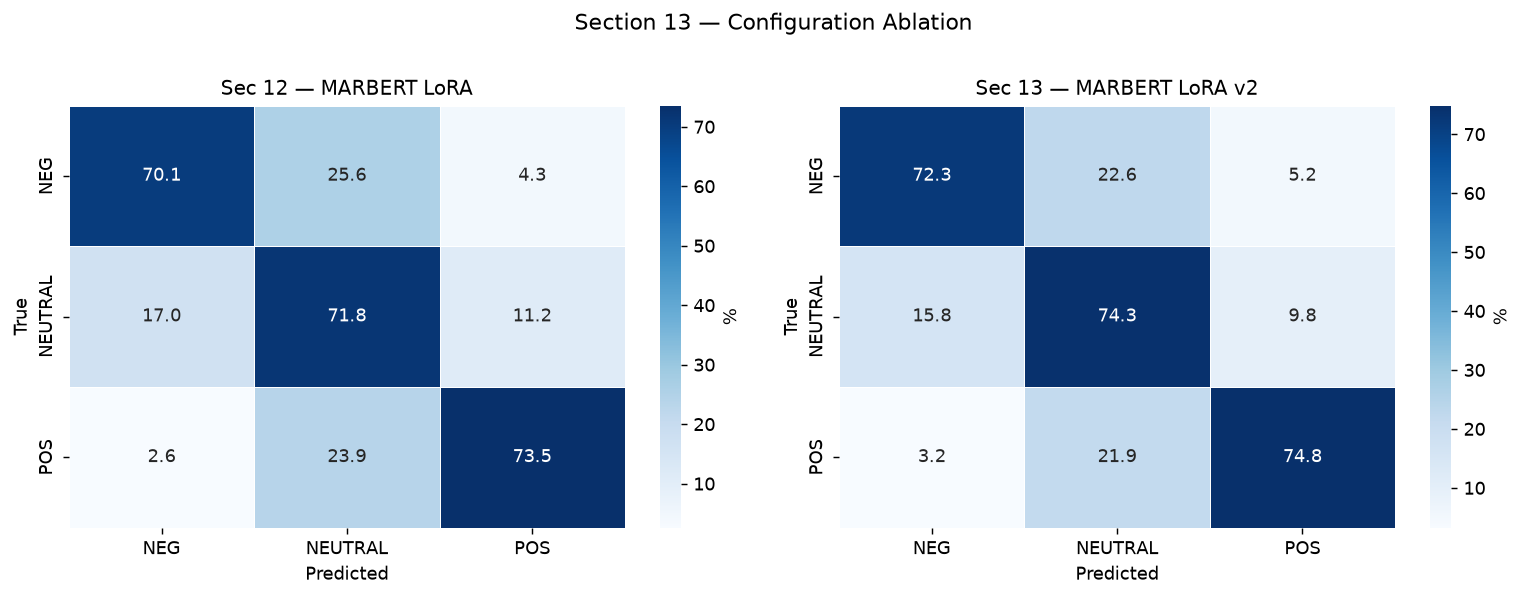

  ✓ MARBERT LoRA v2 (Sec 13)               macroF1=0.650  params=163435782  mem=653.75MB  train=685.92s  infer=14.4941s


{'Model': 'MARBERT LoRA v2 (Sec 13)',
 'Family': 'Transformer',
 'Accuracy': 0.7403,
 'Macro F1': 0.6496,
 'Weighted F1': 0.7574,
 'N Classes': 3,
 'N Test': 1937,
 'Params': 163435782,
 'Trainable': 592131,
 'Layers': 12,
 'Mem (MB)': 653.75,
 'Train (s)': 685.92,
 'Infer (s)': 14.4941,
 'Infer/1k (ms)': 7482.75,
 'Throughput/s': 133.6}

In [51]:
## Section 13 — MARBERT + LoRA v2 evaluation
out_v2             = trainer_v2.predict(te_ds)
y_pred_marbert_v2  = np.argmax(out_v2.predictions, axis=-1)

print('=== Section 13 — MARBERT + LoRA v2 (test set) ===')
print(classification_report(y_b_test, y_pred_marbert_v2, target_names=le.classes_))

# ── Sec 12 vs Sec 13 ablation table ──────────────────────────────────────────
tbl = results_table(
    {'Sec 12 — MARBERT LoRA (aggressive clean, 3ep)': y_pred_marbert,
     'Sec 13 — MARBERT LoRA (light clean, 5ep, smooth)': y_pred_marbert_v2},
    y_b_test, le.classes_
)
print('\nSec 12 vs Sec 13 ablation:')
print(tbl.to_string())

# ── Side-by-side confusion matrices ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_cm(y_b_test, y_pred_marbert,    le.classes_, 'Sec 12 — MARBERT LoRA', ax=axes[0])
plot_cm(y_b_test, y_pred_marbert_v2, le.classes_, 'Sec 13 — MARBERT LoRA v2', ax=axes[1])
plt.suptitle('Section 13 — Configuration Ablation', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('images/sec13_ablation_cm.png', bbox_inches='tight'); plt.show()

record_model('MARBERT LoRA v2 (Sec 13)', 'Transformer', y_b_test, y_pred_marbert_v2, le.classes_,
             model=trainer_v2.model, predict_fn=lambda: trainer_v2.predict(te_ds), n_infer=1)


---
# 14. MARBERT + LoRA + Back-Translation Augmentation

Combining three improvements toward higher macro F1:

| Improvement | Rationale |
|---|---|
| **Back-translation** (AR→EN→AR via MarianMT) | Doubles POS training samples (466→932) and adds 700 NEG paraphrases — directly addresses the 8% POS bottleneck |
| **LoRA rank=32** (alpha=64) | Doubles adapter capacity vs Section 13; more headroom to learn POS/NEG boundaries |
| **Focal loss** (γ=2, class-weighted) | Downweights easy neutral predictions so gradients flow primarily from hard minority-class examples |

Back-translation is applied with the light BERT preprocessing (URLs + @mentions stripped, diacritics removed) so MARBERT sees naturally-structured Arabic text.

In [52]:
## 14.1 Back-Translation (AR→EN→AR via MarianMT)
# First run downloads ~600MB (AR↔EN pair). Subsequent runs use local cache.
import torch, torch.nn.functional as F
from transformers import MarianMTModel, MarianTokenizer

def load_mt(src, tgt):
    name = f'Helsinki-NLP/opus-mt-{src}-{tgt}'
    print(f'  Loading {name}...')
    return MarianTokenizer.from_pretrained(name), MarianMTModel.from_pretrained(name)

def translate_batch(texts, tok, mdl, bs=32):
    out = []
    for i in range(0, len(texts), bs):
        batch = texts[i:i+bs]
        inp = tok(batch, return_tensors='pt', padding=True, truncation=True, max_length=128)
        with torch.no_grad():
            ids = mdl.generate(**inp)
        out.extend([tok.decode(t, skip_special_tokens=True) for t in ids])
    return out

print('Loading MarianMT models (downloads ~600MB on first run)...')
ar_tok, ar_mdl = load_mt('ar', 'en')
en_tok, en_mdl = load_mt('en', 'ar')

# Use the light-preprocessed splits (X_b_train, y_b_train from Section 13)
pos_texts_bt = [X_b_train[i] for i in range(len(X_b_train)) if y_b_train[i] == 2]
neg_texts_bt = [X_b_train[i] for i in range(len(X_b_train)) if y_b_train[i] == 0]
print(f'\nSource: {len(pos_texts_bt)} POS, {len(neg_texts_bt)} NEG')

print('Back-translating POS (AR→EN→AR)...')
aug_pos_bt = translate_batch(translate_batch(pos_texts_bt, ar_tok, ar_mdl), en_tok, en_mdl)

print('Back-translating NEG first 700 (AR→EN→AR)...')
aug_neg_bt = translate_batch(translate_batch(neg_texts_bt[:700], ar_tok, ar_mdl), en_tok, en_mdl)

print(f'\nGenerated: {len(aug_pos_bt)} POS, {len(aug_neg_bt)} NEG')
print('\nSample round-trip:')
print(f'  Original: {pos_texts_bt[0]}')
print(f'  Back-AR:  {aug_pos_bt[0]}')

Loading MarianMT models (downloads ~600MB on first run)...
  Loading Helsinki-NLP/opus-mt-ar-en...


Loading weights: 100%|██████████| 258/258 [00:00<00:00, 57483.69it/s]


  Loading Helsinki-NLP/opus-mt-en-ar...


Loading weights: 100%|██████████| 258/258 [00:00<00:00, 58085.37it/s]



Source: 465 POS, 985 NEG
Back-translating POS (AR→EN→AR)...
Back-translating NEG first 700 (AR→EN→AR)...

Generated: 465 POS, 700 NEG

Sample round-trip:
  Original: #هذي_مصر العمود الفقري للوطن العربي
  Back-AR:  # هذه هي مصر، العمود الفقري للأمة العربية #


In [53]:
## 14.2 Build augmented training set + Tokenise
from datasets import Dataset
from transformers import AutoTokenizer
import numpy as np

aug_texts_14  = list(X_b_train) + aug_pos_bt + aug_neg_bt
aug_labels_14 = list(y_b_train) + [2]*len(aug_pos_bt) + [0]*len(aug_neg_bt)
rng = np.random.default_rng(42)
perm = rng.permutation(len(aug_texts_14))
X_aug14 = np.array(aug_texts_14)[perm]
y_aug14 = np.array(aug_labels_14)[perm]

u, c = np.unique(y_aug14, return_counts=True)
print('Augmented class distribution:')
for l, cnt in zip(u, c):
    print(f'  {le.classes_[l]}: {cnt} ({cnt/len(y_aug14)*100:.1f}%)')
print(f'  Total: {len(y_aug14)}')

MODEL_NAME = 'UBC-NLP/MARBERTv2'
bert_tok14  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tok14(batch):
    return bert_tok14(batch['text'], padding='max_length', truncation=True, max_length=128)

def make_ds14(texts, labels):
    ds = Dataset.from_dict({'text': list(texts), 'labels': list(labels)})
    ds = ds.map(tok14, batched=True, remove_columns=['text'])
    ds.set_format('torch', columns=['input_ids','attention_mask','labels'])
    return ds

tr14 = make_ds14(X_aug14, y_aug14)
va14 = make_ds14(X_b_val, y_b_val)
te14 = make_ds14(X_b_test, y_b_test)
print(f'Train DS: {len(tr14)} | Val: {len(va14)} | Test: {len(te14)}')

Augmented class distribution:
  NEG: 1685 (24.2%)
  NEUTRAL: 4360 (62.5%)
  POS: 930 (13.3%)
  Total: 6975


Map: 100%|██████████| 1937/1937 [00:00<00:00, 21807.40 examples/s]

Train DS: 6975 | Val: 1937 | Test: 1937


In [54]:
import time as _t; _t0 = _t.time()
## 14.3 MARBERT + LoRA r=32 + Focal Loss training
import torch, torch.nn.functional as F, numpy as np
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType
from sklearn.metrics import classification_report, f1_score

base14 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
lora14 = LoraConfig(task_type=TaskType.SEQ_CLS, r=32, lora_alpha=64, lora_dropout=0.05,
                    target_modules=['query','value'], bias='none')
model14 = get_peft_model(base14, lora14)
model14.print_trainable_parameters()

# Inverse-frequency class weights on augmented distribution
cc14 = np.bincount(y_aug14)
w14  = torch.tensor(len(y_aug14) / (3 * cc14), dtype=torch.float32)
print(f'Class weights: NEG={w14[0]:.2f}, NEUTRAL={w14[1]:.2f}, POS={w14[2]:.2f}')

GAMMA = 2.0

class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        out = model(**inputs)
        ce = F.cross_entropy(out.logits, labels,
                             weight=w14.to(out.logits.device),
                             reduction='none', label_smoothing=0.05)
        loss = ((1 - torch.exp(-ce)) ** GAMMA * ce).mean()
        return (loss, out) if return_outputs else loss

def metrics14(ep):
    preds = np.argmax(ep.predictions, axis=-1)
    return {'f1_macro': f1_score(ep.label_ids, preds, average='macro')}

args14 = TrainingArguments(
    output_dir='./marbert_aug_ckpt',
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    seed=42, fp16=False,
    logging_steps=50, report_to='none',
)

trainer14 = FocalTrainer(model=model14, args=args14,
    train_dataset=tr14, eval_dataset=va14, compute_metrics=metrics14)

print('\nTraining MARBERT + LoRA r=32 + Focal Loss + Back-Translation (6 epochs)...')
trainer14.train()
print('Done.')
TRAIN_TIMES['MARBERT r=32+Aug (Sec 14)'] = _t.time() - _t0
print(f'[train-time] MARBERT r=32+Aug (Sec 14): {TRAIN_TIMES['MARBERT r=32+Aug (Sec 14)']:.1f}s')


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 40628.24it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture

trainable params: 1,181,955 || all params: 164,025,606 || trainable%: 0.7206
Class weights: NEG=1.38, NEUTRAL=0.53, POS=2.50

Training MARBERT + LoRA r=32 + Focal Loss + Back-Translation (6 epochs)...


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.316093,0.270041,0.567562
2,0.295917,0.274268,0.534563
3,0.248717,0.286191,0.569645
4,0.215075,0.292068,0.587940
5,0.164570,0.297887,0.612835
6,0.142220,0.305172,0.618199


Done.
[train-time] MARBERT r=32+Aug (Sec 14): 982.8s


=== Section 14 — MARBERT + LoRA r=32 + Focal Loss + Aug (test set) ===
              precision    recall  f1-score   support

         NEG       0.44      0.75      0.56       328
     NEUTRAL       0.91      0.67      0.77      1454
         POS       0.39      0.77      0.52       155

    accuracy                           0.69      1937
   macro avg       0.58      0.73      0.62      1937
weighted avg       0.79      0.69      0.72      1937


Progression — Sections 12 → 13 → 14:
                                  Accuracy  Macro F1  Wtd F1  NEG F1  NEUTRAL F1  POS F1
Model                                                                                   
Sec 13 — MARBERT LoRA v2             0.740     0.650   0.757   0.593       0.818   0.538
Sec 12 — MARBERT LoRA                0.717     0.626   0.736   0.569       0.797   0.511
Sec 14 — MARBERT LoRA r=32 + Aug     0.693     0.616   0.716   0.556       0.773   0.517


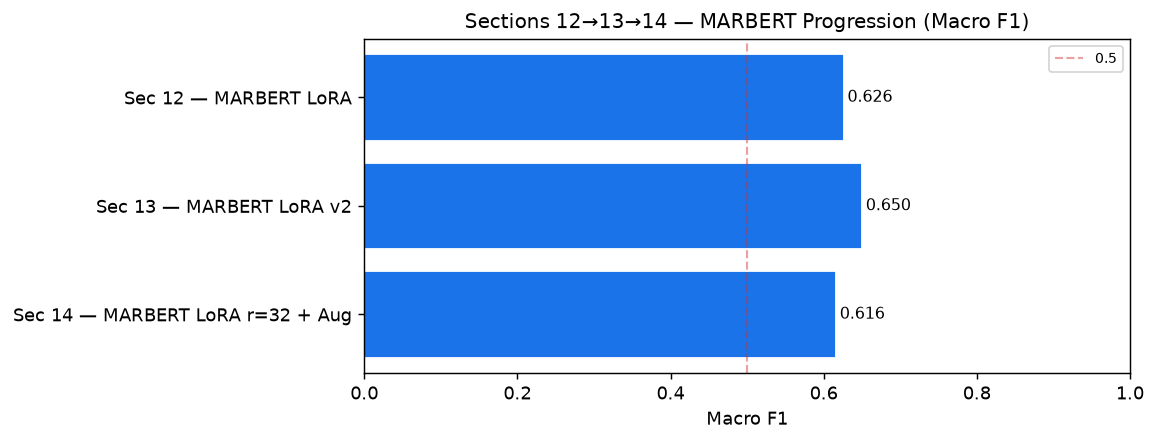

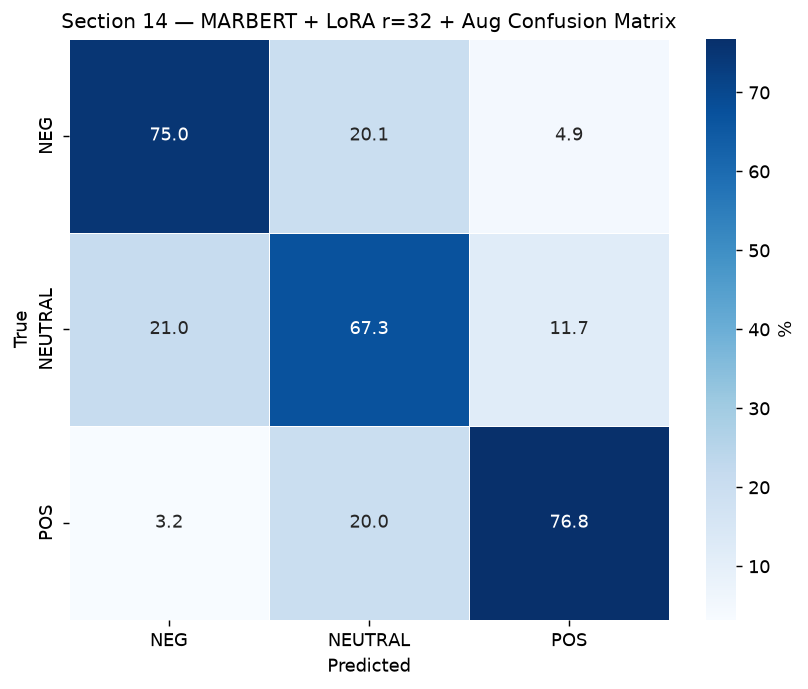

  ✓ MARBERT r=32+Aug (Sec 14)              macroF1=0.616  params=164025606  mem=656.11MB  train=982.83s  infer=14.5784s


{'Model': 'MARBERT r=32+Aug (Sec 14)',
 'Family': 'Transformer',
 'Accuracy': 0.6933,
 'Macro F1': 0.6156,
 'Weighted F1': 0.7161,
 'N Classes': 3,
 'N Test': 1937,
 'Params': 164025606,
 'Trainable': 1181955,
 'Layers': 12,
 'Mem (MB)': 656.11,
 'Train (s)': 982.83,
 'Infer (s)': 14.5784,
 'Infer/1k (ms)': 7526.29,
 'Throughput/s': 132.9}

In [55]:
## 14.4 — MARBERT + LoRA r=32 + Focal Loss + Back-Translation evaluation
from sklearn.metrics import classification_report, f1_score

out14     = trainer14.predict(te14)
y_pred14  = np.argmax(out14.predictions, axis=-1)

print('=== Section 14 — MARBERT + LoRA r=32 + Focal Loss + Aug (test set) ===')
print(classification_report(y_b_test, y_pred14, target_names=le.classes_))

# ── Progression table ─────────────────────────────────────────────────────────
tbl = results_table(
    {'Sec 12 — MARBERT LoRA':              y_pred_marbert,
     'Sec 13 — MARBERT LoRA v2':           y_pred_marbert_v2,
     'Sec 14 — MARBERT LoRA r=32 + Aug':   y_pred14},
    y_b_test, le.classes_
)
print('\nProgression — Sections 12 → 13 → 14:')
print(tbl.to_string())

# ── Bar chart ────────────────────────────────────────────────────────────────
plot_f1_bars(
    {'Sec 12 — MARBERT LoRA':            float(tbl.loc['Sec 12 — MARBERT LoRA','Macro F1']),
     'Sec 13 — MARBERT LoRA v2':         float(tbl.loc['Sec 13 — MARBERT LoRA v2','Macro F1']),
     'Sec 14 — MARBERT LoRA r=32 + Aug': float(tbl.loc['Sec 14 — MARBERT LoRA r=32 + Aug','Macro F1'])},
    'Sections 12→13→14 — MARBERT Progression (Macro F1)',
    save_as='sec14_progression.png'
)

# ── Confusion matrix ──────────────────────────────────────────────────────────
plot_cm(y_b_test, y_pred14, le.classes_,
        'Section 14 — MARBERT + LoRA r=32 + Aug Confusion Matrix',
        save_as='sec14_marbert_cm.png')

record_model('MARBERT r=32+Aug (Sec 14)', 'Transformer', y_b_test, y_pred14, le.classes_,
             model=trainer14.model, predict_fn=lambda: trainer14.predict(te14), n_infer=1)


---
# 15. Label Schema Ablation: 3-Class Merged vs 3-Class Pure vs 4-Class

The original ASTD dataset has **4 distinct labels**: POS, NEG, OBJ (objective/factual), NEUTRAL.  
Assignment 2 merged `OBJ → NEUTRAL`, creating a 77% majority class that is 89% objective news text — not genuine neutral sentiment.

This section tests three schemas in parallel using identical MARBERT + LoRA setups:

| Schema | Classes | Train size | Class balance |
|---|---|---|---|
| **A — 3-class merged** (Assignment 2 baseline) | POS / NEG / NEUTRAL+OBJ | ~5,816 | 8 / 17 / 75% |
| **B — 3-class pure** | POS / NEG / NEUTRAL only (OBJ rows dropped) | ~1,990 | 24 / 51 / 25% |
| **C — 4-class** | POS / NEG / NEUTRAL / OBJ | ~5,816 | 8 / 17 / 8 / 67% |

**Hypothesis**: Schema B will have the best POS and NEUTRAL F1 (balanced classes), Schema C will reveal OBJ as its own separable class, Schema A will continue to struggle with minority recall due to OBJ noise in NEUTRAL.

In [56]:
## 15.1 Build the three dataset schemas
import re, pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Raw data — keep all 4 original labels
df_raw = pd.read_csv('real data.txt', sep='\t', header=None, names=['text','label'])
print('Original label counts:')
print(df_raw['label'].value_counts().to_string())

def clean_bert(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'https?://\S+|www\.\S+|@\w+', '', text)
    text = re.sub(r'[ً-ٰٟ]|ـ', '', text)
    text = re.sub(r'[إأآ]', 'ا', text)
    return re.sub(r'\s+', ' ', text).strip()

df_raw['text_bert'] = df_raw['text'].apply(clean_bert)
df_raw = df_raw[df_raw['text_bert'].str.strip() != ''].reset_index(drop=True)

# Schema A — 3-class merged (current baseline: OBJ → NEUTRAL)
df_A = df_raw.copy()
df_A['label'] = df_A['label'].replace('OBJ', 'NEUTRAL')
le_A = LabelEncoder(); df_A['label_enc'] = le_A.fit_transform(df_A['label'])

# Schema B — 3-class pure (drop all OBJ rows)
df_B = df_raw[df_raw['label'] != 'OBJ'].copy().reset_index(drop=True)
le_B = LabelEncoder(); df_B['label_enc'] = le_B.fit_transform(df_B['label'])

# Schema C — 4-class (all original labels kept)
df_C = df_raw.copy()
le_C = LabelEncoder(); df_C['label_enc'] = le_C.fit_transform(df_C['label'])

def split(df, label_col='label_enc'):
    X, y = df['text_bert'].to_numpy(), df[label_col].to_numpy()
    X_tr, X_t, y_tr, y_t = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
    X_v,  X_te, y_v,  y_te = train_test_split(X_t, y_t, test_size=0.5, stratify=y_t, random_state=42)
    return X_tr, X_v, X_te, y_tr, y_v, y_te

Xtr_A, Xv_A, Xte_A, ytr_A, yv_A, yte_A = split(df_A)
Xtr_B, Xv_B, Xte_B, ytr_B, yv_B, yte_B = split(df_B)
Xtr_C, Xv_C, Xte_C, ytr_C, yv_C, yte_C = split(df_C)

for name, le, X_tr, y_tr in [('A (3-class merged)', le_A, Xtr_A, ytr_A),
                               ('B (3-class pure)',   le_B, Xtr_B, ytr_B),
                               ('C (4-class)',         le_C, Xtr_C, ytr_C)]:
    counts = dict(zip(le.classes_, np.bincount(y_tr, minlength=len(le.classes_))))
    print(f'\nSchema {name} — train {len(X_tr)} samples: {counts}')

Original label counts:
label
OBJ        6470
NEG        1642
NEUTRAL     805
POS         777

Schema A (3-class merged) — train 5816 samples: {'NEG': 985, 'NEUTRAL': 4365, 'POS': 466}

Schema B (3-class pure) — train 1934 samples: {'NEG': 985, 'NEUTRAL': 483, 'POS': 466}

Schema C (4-class) — train 5816 samples: {'NEG': 985, 'NEUTRAL': 483, 'OBJ': 3882, 'POS': 466}


  ✓ SVM · Schema A: merged                 macroF1=0.484  params=30003  mem=0.24MB  train=5.35s  infer=0.0208s
Schema A: merged: Macro F1=0.484  Accuracy=71.3%
  ✓ SVM · Schema B: pure                   macroF1=0.476  params=14598  mem=0.12MB  train=0.12s  infer=0.0078s
Schema B: pure: Macro F1=0.476  Accuracy=52.7%
  ✓ SVM · Schema C: 4-class                macroF1=0.410  params=40004  mem=0.32MB  train=0.38s  infer=0.0237s
Schema C: 4-class: Macro F1=0.410  Accuracy=64.4%

SVM Schema Summary:
            Macro F1  Accuracy
Schema                        
A: merged      0.484     0.713
B: pure        0.476     0.527
C: 4-class     0.410     0.644


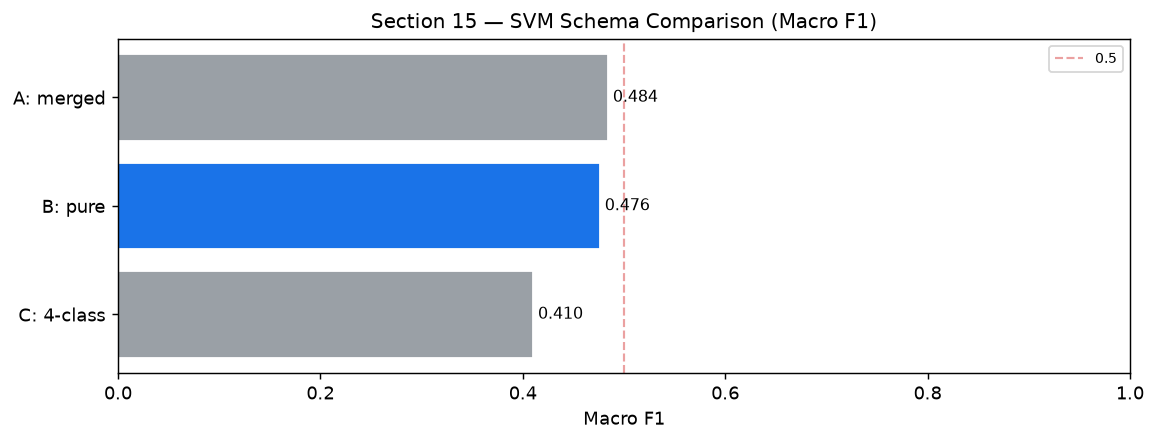

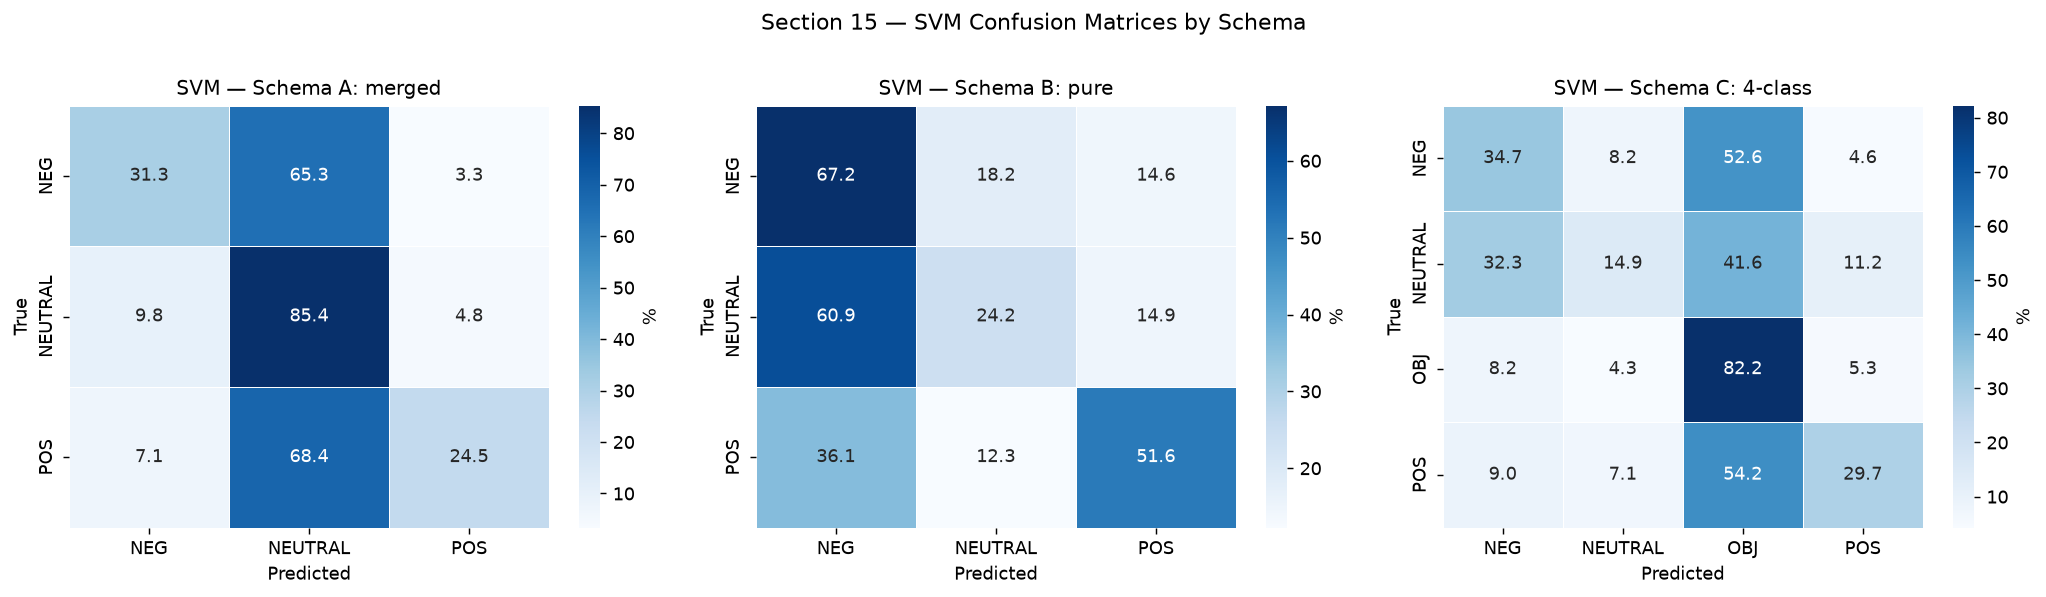

In [57]:
## 15.2 — SVM schema comparison (all 3 schemas)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

svm_schema_preds = {}
svm_schema_les   = {}

for sname, _le, Xtr, ytr, Xv, yv, Xte, yte in [
    ('A: merged',   le_A, Xtr_A, ytr_A, Xv_A, yv_A, Xte_A, yte_A),
    ('B: pure',     le_B, Xtr_B, ytr_B, Xv_B, yv_B, Xte_B, yte_B),
    ('C: 4-class',  le_C, Xtr_C, ytr_C, Xv_C, yv_C, Xte_C, yte_C),
]:
    tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
    gs = GridSearchCV(LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
                      {'C': [0.1, 0.5, 1.0, 5.0]}, cv=3, scoring='f1_macro', n_jobs=-1)
    _t0s = time.time(); gs.fit(tfidf.fit_transform(Xtr), ytr); TRAIN_TIMES[f'SVM · Schema {sname}'] = time.time() - _t0s
    y_pred = gs.predict(tfidf.transform(Xte))
    svm_schema_preds[sname] = (yte, y_pred, _le)
    record_model(f'SVM · Schema {sname}', 'Classical (SVM)', yte, y_pred, _le.classes_,
                 model=gs, predict_fn=(lambda g=gs, tf=tfidf, X=Xte: g.predict(tf.transform(X))), n_infer=3)
    svm_schema_les[sname]   = _le
    f1 = f1_score(yte, y_pred, average='macro')
    acc = np.mean(y_pred == yte)
    print(f'Schema {sname}: Macro F1={f1:.3f}  Accuracy={acc*100:.1f}%')

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Schema': s,
     'Macro F1': round(f1_score(v[0],v[1],average='macro'),3),
     'Accuracy': round(np.mean(v[1]==v[0]),3)}
    for s,v in svm_schema_preds.items()
]).set_index('Schema').sort_values('Macro F1', ascending=False)
print('\nSVM Schema Summary:'); print(summary.to_string())

# ── F1 bar chart ──────────────────────────────────────────────────────────────
plot_f1_bars(
    {s: float(summary.loc[s,'Macro F1']) for s in summary.index},
    'Section 15 — SVM Schema Comparison (Macro F1)',
    save_as='sec15_svm_schemas.png', highlight='B'
)

# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (sname, (yte, ypred, _le)) in zip(axes, svm_schema_preds.items()):
    plot_cm(yte, ypred, _le.classes_, f'SVM — Schema {sname}', ax=ax)
plt.suptitle('Section 15 — SVM Confusion Matrices by Schema', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('images/sec15_svm_cms.png', bbox_inches='tight'); plt.show()



Training MARBERT — Schema A: merged


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 45612.68it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture

Epoch,Training Loss,Validation Loss,F1 Macro
1,0.455524,0.476290,0.407391
2,0.354793,0.423193,0.557892
3,0.298612,0.448872,0.556096
4,0.278165,0.443498,0.585753
5,0.268453,0.433578,0.553831


Map: 100%|██████████| 1939/1939 [00:00<00:00, 13674.38 examples/s]


              precision    recall  f1-score   support

         NEG       0.44      0.85      0.58       329
     NEUTRAL       0.94      0.64      0.76      1455
         POS       0.39      0.80      0.52       155

    accuracy                           0.69      1939
   macro avg       0.59      0.76      0.62      1939
weighted avg       0.81      0.69      0.71      1939

  Macro F1: 0.6212
  ✓ MARBERT · Schema A: merged             macroF1=0.621  params=163435782  mem=653.75MB  train=679.97s  infer=Nones

Training MARBERT — Schema B: pure


...

              precision    recall  f1-score   support

         NEG       0.82      0.61      0.70       329
     NEUTRAL       0.45      0.61      0.51       161
         POS       0.74      0.85      0.79       155

    accuracy                           0.67       645
   macro avg       0.67      0.69      0.67       645
weighted avg       0.71      0.67      0.68       645

  Macro F1: 0.6692
  ✓ MARBERT · Schema B: pure               macroF1=0.669  params=163435782  mem=653.75MB  train=232.03s  infer=Nones

Training MARBERT — Schema C: 4-class


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12107.67it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture

Epoch,Training Loss,Validation Loss,F1 Macro
1,0.788652,0.681113,0.430456
2,0.638468,0.655111,0.502956
3,0.548054,0.639974,0.486925
4,0.452090,0.650148,0.490148
5,0.453887,0.645314,0.528924


Map: 100%|██████████| 1939/1939 [00:00<00:00, 14498.73 examples/s]


              precision    recall  f1-score   support

         NEG       0.48      0.72      0.58       329
     NEUTRAL       0.28      0.56      0.38       161
         OBJ       0.93      0.56      0.70      1294
         POS       0.34      0.76      0.47       155

    accuracy                           0.60      1939
   macro avg       0.51      0.65      0.53      1939
weighted avg       0.75      0.60      0.63      1939

  Macro F1: 0.5309
  ✓ MARBERT · Schema C: 4-class            macroF1=0.531  params=163437320  mem=653.76MB  train=706.09s  infer=Nones

MARBERT Schema Summary:
            Macro F1  Accuracy
Schema                        
B: pure        0.669     0.670
A: merged      0.621     0.686
C: 4-class     0.531     0.603


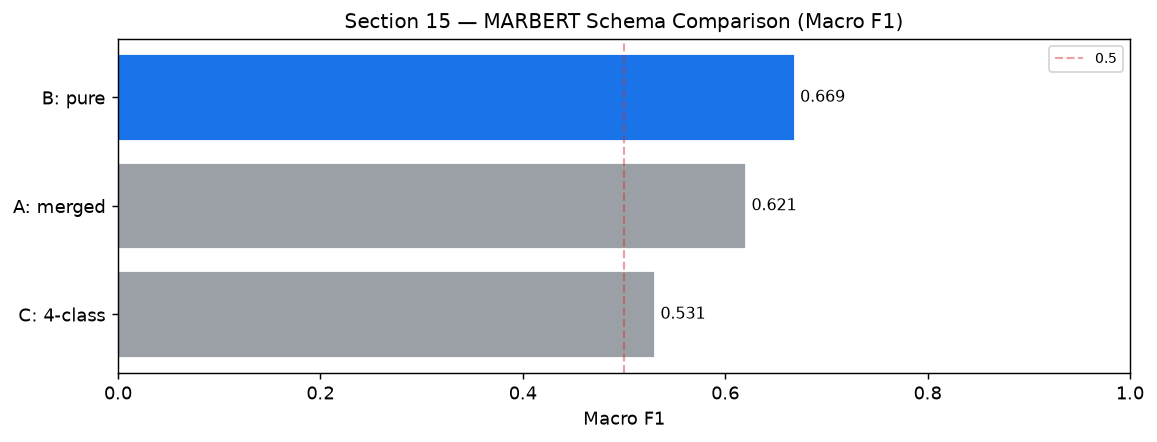

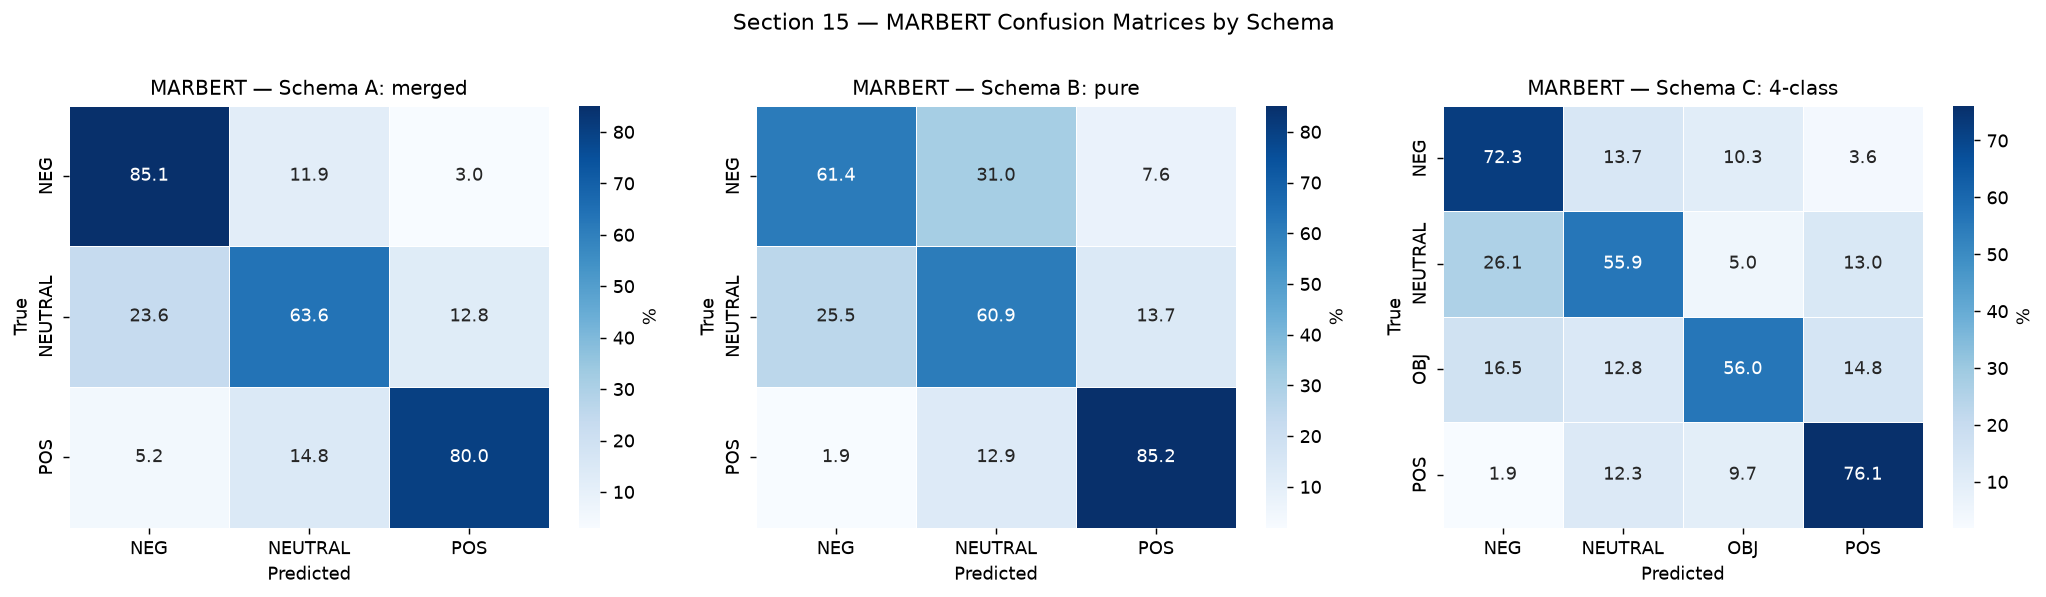

In [58]:
## 15.3 — MARBERT + LoRA all three schemas (runs sequentially, ~15 min each)
import torch, torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset

MODEL_NAME  = 'UBC-NLP/MARBERTv2'
tokenizer15 = AutoTokenizer.from_pretrained(MODEL_NAME)

def tok15(batch):
    return tokenizer15(batch['text'], padding='max_length', truncation=True, max_length=128)
def make_ds15(texts, labels):
    ds = Dataset.from_dict({'text': list(texts), 'labels': list(map(int, labels))})
    ds = ds.map(tok15, batched=True, remove_columns=['text'])
    ds.set_format('torch', columns=['input_ids','attention_mask','labels'])
    return ds

marbert_results_15 = {}

for sname, _le, Xtr, Xv, Xte, ytr, yv, yte in [
    ('A: merged',  le_A, Xtr_A, Xv_A, Xte_A, ytr_A, yv_A, yte_A),
    ('B: pure',    le_B, Xtr_B, Xv_B, Xte_B, ytr_B, yv_B, yte_B),
    ('C: 4-class', le_C, Xtr_C, Xv_C, Xte_C, ytr_C, yv_C, yte_C),
]:
    print(f'\n{"="*55}\nTraining MARBERT — Schema {sname}\n{"="*55}')
    n_labels = len(_le.classes_)
    base15   = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=n_labels)
    lora15   = LoraConfig(task_type=TaskType.SEQ_CLS, r=16, lora_alpha=32,
                          lora_dropout=0.05, target_modules=['query','value'], bias='none')
    mdl15    = get_peft_model(base15, lora15)
    cc15     = np.bincount(ytr, minlength=n_labels)
    w15      = torch.tensor(len(ytr)/(n_labels*cc15), dtype=torch.float32)

    class SchemaTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            lbl = inputs.pop('labels'); out = model(**inputs)
            ce  = F.cross_entropy(out.logits, lbl, weight=w15.to(out.logits.device),
                                  reduction='none', label_smoothing=0.05)
            loss = ((1-torch.exp(-ce))**2*ce).mean()
            return (loss, out) if return_outputs else loss

    def m15(ep):
        preds = np.argmax(ep.predictions, axis=-1)
        return {'f1_macro': f1_score(ep.label_ids, preds, average='macro')}

    tr15 = SchemaTrainer(
        model=mdl15, compute_metrics=m15,
        train_dataset=make_ds15(Xtr,ytr), eval_dataset=make_ds15(Xv,yv),
        args=TrainingArguments(
            output_dir=f'./marbert_schema_{sname[0]}_ckpt',
            num_train_epochs=5, per_device_train_batch_size=16, per_device_eval_batch_size=32,
            learning_rate=2e-4, warmup_ratio=0.1, weight_decay=0.01,
            eval_strategy='epoch', save_strategy='epoch',
            load_best_model_at_end=True, metric_for_best_model='f1_macro',
            greater_is_better=True, seed=42, fp16=False,
            logging_steps=100, report_to='none',
        )
    )
    _t0s = time.time(); tr15.train(); TRAIN_TIMES[f'MARBERT · Schema {sname}'] = time.time() - _t0s
    out15   = tr15.predict(make_ds15(Xte, yte))
    yp15    = np.argmax(out15.predictions, axis=-1)
    marbert_results_15[sname] = {'f1': f1_score(yte,yp15,average='macro'),
                                  'preds': yp15, 'true': yte, 'le': _le}
    print(classification_report(yte, yp15, target_names=_le.classes_))
    print(f'  Macro F1: {marbert_results_15[sname]["f1"]:.4f}')
    record_model(f'MARBERT · Schema {sname}', 'Transformer', yte, yp15, _le.classes_,
                 model=tr15.model, train_time=TRAIN_TIMES.get(f'MARBERT · Schema {sname}'))

# ── Summary table ─────────────────────────────────────────────────────────────
summary15 = pd.DataFrame([
    {'Schema': s, 'Macro F1': round(v['f1'],3),
     'Accuracy': round(np.mean(v['preds']==v['true']),3)}
    for s,v in marbert_results_15.items()
]).set_index('Schema').sort_values('Macro F1', ascending=False)
print('\nMARBERT Schema Summary:'); print(summary15.to_string())

# ── F1 bar chart ──────────────────────────────────────────────────────────────
plot_f1_bars(
    {s: float(summary15.loc[s,'Macro F1']) for s in summary15.index},
    'Section 15 — MARBERT Schema Comparison (Macro F1)',
    save_as='sec15_marbert_schemas.png', highlight='B'
)

# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (sname, v) in zip(axes, marbert_results_15.items()):
    plot_cm(v['true'], v['preds'], v['le'].classes_, f'MARBERT — Schema {sname}', ax=ax)
plt.suptitle('Section 15 — MARBERT Confusion Matrices by Schema', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('images/sec15_marbert_cms.png', bbox_inches='tight'); plt.show()


---
# 16. Balanced 4-Class Schema (Schema D): OBJ Downsampled

**Motivation:** The full ASTD corpus is heavily skewed — OBJ accounts for 69% of tweets. Prior sections showed merging OBJ→NEUTRAL (Schema A) or dropping OBJ (Schema B) both hurt minority F1. Here we ask: *can we keep all four classes and achieve competitive performance if we balance the dataset by downsampling OBJ?*

**Schema D construction:**
- OBJ: randomly downsampled 6,470 → **1,500** (seed=42)
- NEG, NEUTRAL, POS: kept in full (1,642 / 805 / 777)
- Result: **4,724 total tweets** — no class exceeds 2× any other

We evaluate with SVM (TF-IDF) and MARBERT + LoRA, comparing against all prior schemas.

In [59]:
## 16.1  Build Schema D — balanced 4-class (OBJ downsampled)
import re, pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

def clean_bert(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'https?://\S+|www\.\S+|@\w+', '', text)
    text = re.sub(r'[\u064b-\u0650\u0653-\u065f\u0670]|\u0640', '', text)
    text = re.sub(r'[\u0625\u0623\u0622]', '\u0627', text)
    return re.sub(r'\s+', ' ', text).strip()

df_raw = pd.read_csv('real data.txt', sep='\t', header=None, names=['text','label'])
df_raw['text_bert'] = df_raw['text'].apply(clean_bert)
df_raw = df_raw[df_raw['text_bert'].str.strip() != ''].reset_index(drop=True)

obj_df  = df_raw[df_raw['label'] == 'OBJ'].sample(n=1500, random_state=42)
rest_df = df_raw[df_raw['label'] != 'OBJ']
df_D    = pd.concat([obj_df, rest_df]).reset_index(drop=True)

print('Schema D class distribution:')
print(df_D['label'].value_counts().to_string())
print(f'\nTotal: {len(df_D)} | Max/min ratio: {df_D["label"].value_counts().max()/df_D["label"].value_counts().min():.2f}x')

le = LabelEncoder()
y  = le.fit_transform(df_D['label'])
X  = df_D['text_bert'].to_numpy()
print(f'Label mapping: {dict(zip(le.classes_, range(len(le.classes_))))}')

Xtr, Xt, ytr, yt = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
Xv, Xte, yv, yte = train_test_split(Xt, yt, test_size=0.5, stratify=yt, random_state=42)
print(f'Train: {len(Xtr)} | Val: {len(Xv)} | Test: {len(Xte)}')
print('Train dist:', dict(zip(le.classes_, np.bincount(ytr, minlength=len(le.classes_)))))

Schema D class distribution:
label
NEG        1642
OBJ        1500
NEUTRAL     805
POS         777

Total: 4724 | Max/min ratio: 2.11x
Label mapping: {'NEG': 0, 'NEUTRAL': 1, 'OBJ': 2, 'POS': 3}
Train: 2834 | Val: 945 | Test: 945
Train dist: {'NEG': 985, 'NEUTRAL': 483, 'OBJ': 900, 'POS': 466}


  C=0.1: val F1=0.4879
  C=0.5: val F1=0.5032
  C=1.0: val F1=0.4883
  C=5.0: val F1=0.4605
  [Timer] SVM · Schema D (Sec 16): 1.1s

Test Macro F1: 0.4630  |  Accuracy: 49.9%
              precision    recall  f1-score   support

         NEG       0.54      0.57      0.55       329
     NEUTRAL       0.30      0.27      0.28       161
         OBJ       0.56      0.60      0.58       300
         POS       0.47      0.41      0.44       155

    accuracy                           0.50       945
   macro avg       0.47      0.46      0.46       945
weighted avg       0.49      0.50      0.50       945



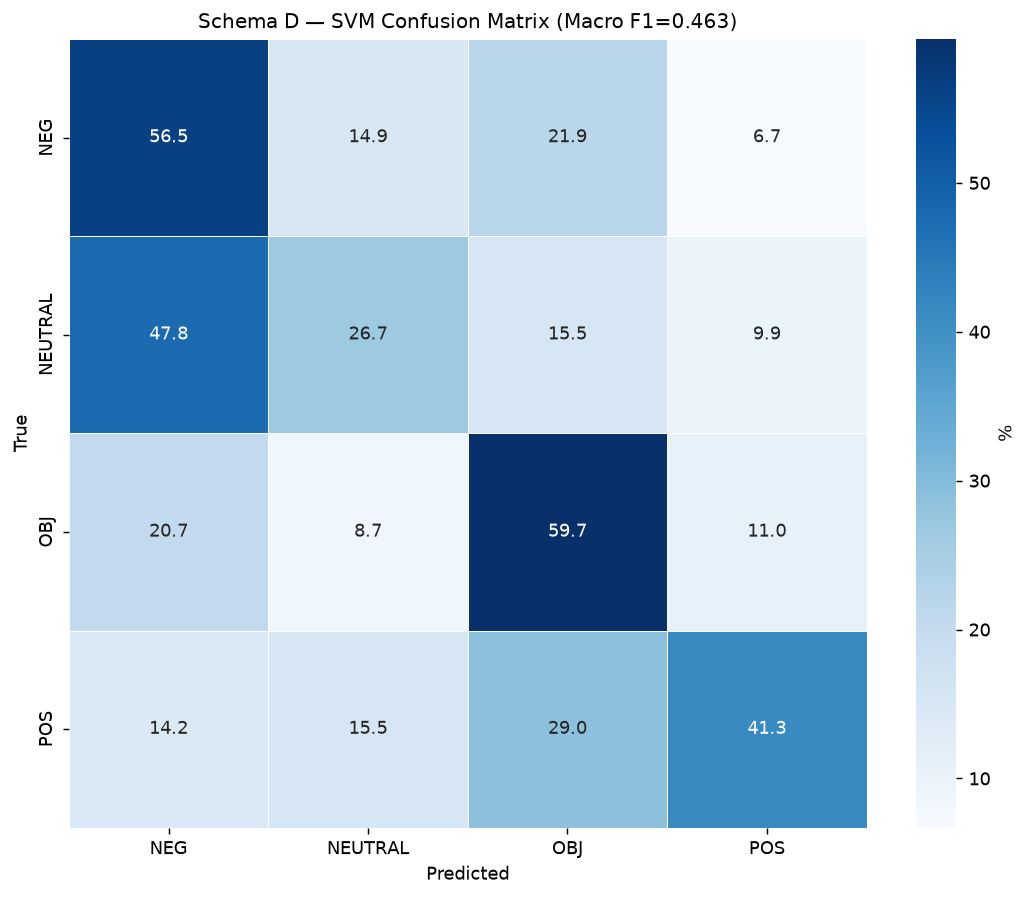

  ✓ SVM · Schema D (Sec 16)                macroF1=0.463  params=320004  mem=2.56MB  train=1.12s  infer=0.0011s


{'Model': 'SVM · Schema D (Sec 16)',
 'Family': 'Classical (SVM)',
 'Accuracy': 0.4995,
 'Macro F1': 0.463,
 'Weighted F1': 0.4953,
 'N Classes': 4,
 'N Test': 945,
 'Params': 320004,
 'Trainable': 320004,
 'Layers': None,
 'Mem (MB)': 2.56,
 'Train (s)': 1.12,
 'Infer (s)': 0.0011,
 'Infer/1k (ms)': 1.19,
 'Throughput/s': 837089.2}

In [60]:
## 16.2 — SVM baseline on Schema D (balanced 4-class)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

vec    = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5), max_features=80000, sublinear_tf=True)
Xtr_tf = vec.fit_transform(Xtr); Xv_tf = vec.transform(Xv); Xte_tf = vec.transform(Xte)

best_f1, best_clf = 0, None
with Timer('SVM · Schema D (Sec 16)'):          # time the full hyper-param search
    for C in [0.1, 0.5, 1.0, 5.0]:
        clf = LinearSVC(C=C, class_weight='balanced', max_iter=2000, random_state=42)
        clf.fit(Xtr_tf, ytr)
        f1v = f1_score(yv, clf.predict(Xv_tf), average='macro')
        print(f'  C={C}: val F1={f1v:.4f}')
        if f1v > best_f1: best_f1, best_clf = f1v, clf

y_pred_svm_D = best_clf.predict(Xte_tf)
svm_f1  = f1_score(yte, y_pred_svm_D, average='macro')
svm_acc = np.mean(y_pred_svm_D == yte)
print(f'\nTest Macro F1: {svm_f1:.4f}  |  Accuracy: {svm_acc*100:.1f}%')
print(classification_report(yte, y_pred_svm_D, target_names=le.classes_))

plot_cm(yte, y_pred_svm_D, le.classes_,
        f'Schema D — SVM Confusion Matrix (Macro F1={svm_f1:.3f})',
        save_as='sec16_svm_D_cm.png')

record_model('SVM · Schema D (Sec 16)', 'Classical (SVM)', yte, y_pred_svm_D, le.classes_,
             model=best_clf, predict_fn=lambda: best_clf.predict(Xte_tf), n_infer=3)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 43314.30it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture

trainable params: 592,900 || all params: 163,437,320 || trainable%: 0.3628

Training MARBERT + LoRA r=16 on Schema D (6 epochs)...


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.713049,0.611638,0.370749
2,0.512030,0.498622,0.590482
3,0.472295,0.508294,0.588648
4,0.454836,0.493401,0.651199
5,0.385577,0.494658,0.636956
6,0.362067,0.495780,0.649173


  [Timer] MARBERT · Schema D (Sec 16): 413.6s


              precision    recall  f1-score   support

         NEG       0.80      0.60      0.69       329
     NEUTRAL       0.44      0.54      0.49       161
         OBJ       0.67      0.64      0.65       300
         POS       0.56      0.77      0.65       155

    accuracy                           0.63       945
   macro avg       0.62      0.64      0.62       945
weighted avg       0.66      0.63      0.64       945

Macro F1: 0.6183  |  Accuracy: 63.1%


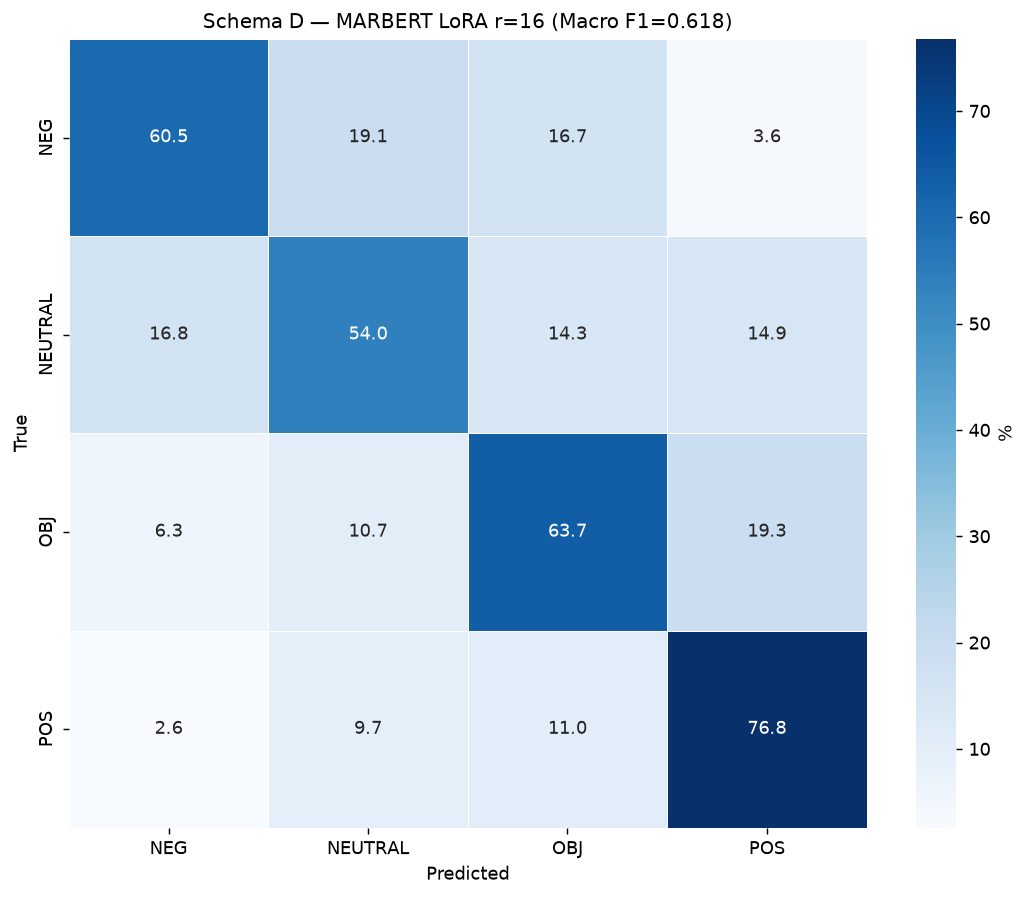

  ✓ MARBERT · Schema D (Sec 16)            macroF1=0.618  params=163437320  mem=653.76MB  train=413.56s  infer=7.5416s


{'Model': 'MARBERT · Schema D (Sec 16)',
 'Family': 'Transformer',
 'Accuracy': 0.6307,
 'Macro F1': 0.6183,
 'Weighted F1': 0.6356,
 'N Classes': 4,
 'N Test': 945,
 'Params': 163437320,
 'Trainable': 592900,
 'Layers': 12,
 'Mem (MB)': 653.76,
 'Train (s)': 413.56,
 'Infer (s)': 7.5416,
 'Infer/1k (ms)': 7980.51,
 'Throughput/s': 125.3}

In [61]:
## 16.3 — MARBERT + LoRA r=16 on Schema D (balanced 4-class)
import torch, torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset

MODEL_NAME = 'UBC-NLP/MARBERTv2'
NUM_LABELS = len(le.classes_)
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tok_fn(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)
def make_ds(texts, labels):
    ds = Dataset.from_dict({'text': list(texts), 'labels': list(map(int, labels))})
    ds = ds.map(tok_fn, batched=True, remove_columns=['text'])
    ds.set_format('torch', columns=['input_ids','attention_mask','labels'])
    return ds

tr_ds = make_ds(Xtr, ytr); va_ds = make_ds(Xv, yv); te_ds = make_ds(Xte, yte)

base     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)
lora_cfg = LoraConfig(task_type=TaskType.SEQ_CLS, r=16, lora_alpha=32, lora_dropout=0.05,
                      target_modules=['query','value'], bias='none')
model    = get_peft_model(base, lora_cfg)
model.print_trainable_parameters()

cc = np.bincount(ytr, minlength=NUM_LABELS)
w  = torch.tensor(len(ytr)/(NUM_LABELS*cc), dtype=torch.float32)

class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        lbl = inputs.pop('labels'); out = model(**inputs)
        ce  = F.cross_entropy(out.logits, lbl, weight=w.to(out.logits.device),
                              reduction='none', label_smoothing=0.05)
        loss = ((1-torch.exp(-ce))**2*ce).mean()
        return (loss, out) if return_outputs else loss

def metrics(ep):
    preds = np.argmax(ep.predictions, axis=-1)
    return {'f1_macro': f1_score(ep.label_ids, preds, average='macro')}

args = TrainingArguments(
    output_dir='./ckpt_schD_marbert', num_train_epochs=6,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    learning_rate=2e-4, warmup_ratio=0.1, weight_decay=0.01,
    eval_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True, metric_for_best_model='f1_macro',
    greater_is_better=True, seed=42, fp16=False,
    logging_steps=50, report_to='none',
)
trainer = FocalTrainer(model=model, args=args,
    train_dataset=tr_ds, eval_dataset=va_ds, compute_metrics=metrics)

print('\nTraining MARBERT + LoRA r=16 on Schema D (6 epochs)...')
with Timer('MARBERT · Schema D (Sec 16)'):
    trainer.train()

out       = trainer.predict(te_ds)
y_pred_mb_D = np.argmax(out.predictions, axis=-1)
mb_f1  = f1_score(yte, y_pred_mb_D, average='macro')
mb_acc = np.mean(y_pred_mb_D == yte)
print(classification_report(yte, y_pred_mb_D, target_names=le.classes_))
print(f'Macro F1: {mb_f1:.4f}  |  Accuracy: {mb_acc*100:.1f}%')

plot_cm(yte, y_pred_mb_D, le.classes_,
        f'Schema D — MARBERT LoRA r=16 (Macro F1={mb_f1:.3f})',
        save_as='sec16_marbert_D_cm.png')

record_model('MARBERT · Schema D (Sec 16)', 'Transformer', yte, y_pred_mb_D, le.classes_,
             model=trainer.model, predict_fn=lambda: trainer.predict(te_ds), n_infer=1)



COMPLETE EXPERIMENT SUMMARY
                        Model          Type  Macro F1  Accuracy
    MARBERT Schema B — Sec 15       MARBERT     0.669     0.670
     MARBERT LoRA v2 — Sec 13       MARBERT     0.650     0.740
        MARBERT LoRA — Sec 12       MARBERT     0.626     0.717
    MARBERT Schema D — Sec 16       MARBERT     0.618     0.631
MARBERT LoRA r=32+Aug — Sec14       MARBERT     0.616     0.693
      SVM + Stemming (Sec 10)           SVM     0.506     0.708
         SVM + TF-IDF (Sec 9)           SVM     0.481     0.695
                         LSTM Deep Learning     0.472     0.730
     SVM  — Schema D (Sec 16)           SVM     0.463     0.499
                          CNN Deep Learning     0.461     0.720
                  RF + TF-IDF   Traditional     0.442     0.720
                  NB + TF-IDF   Traditional     0.424     0.690


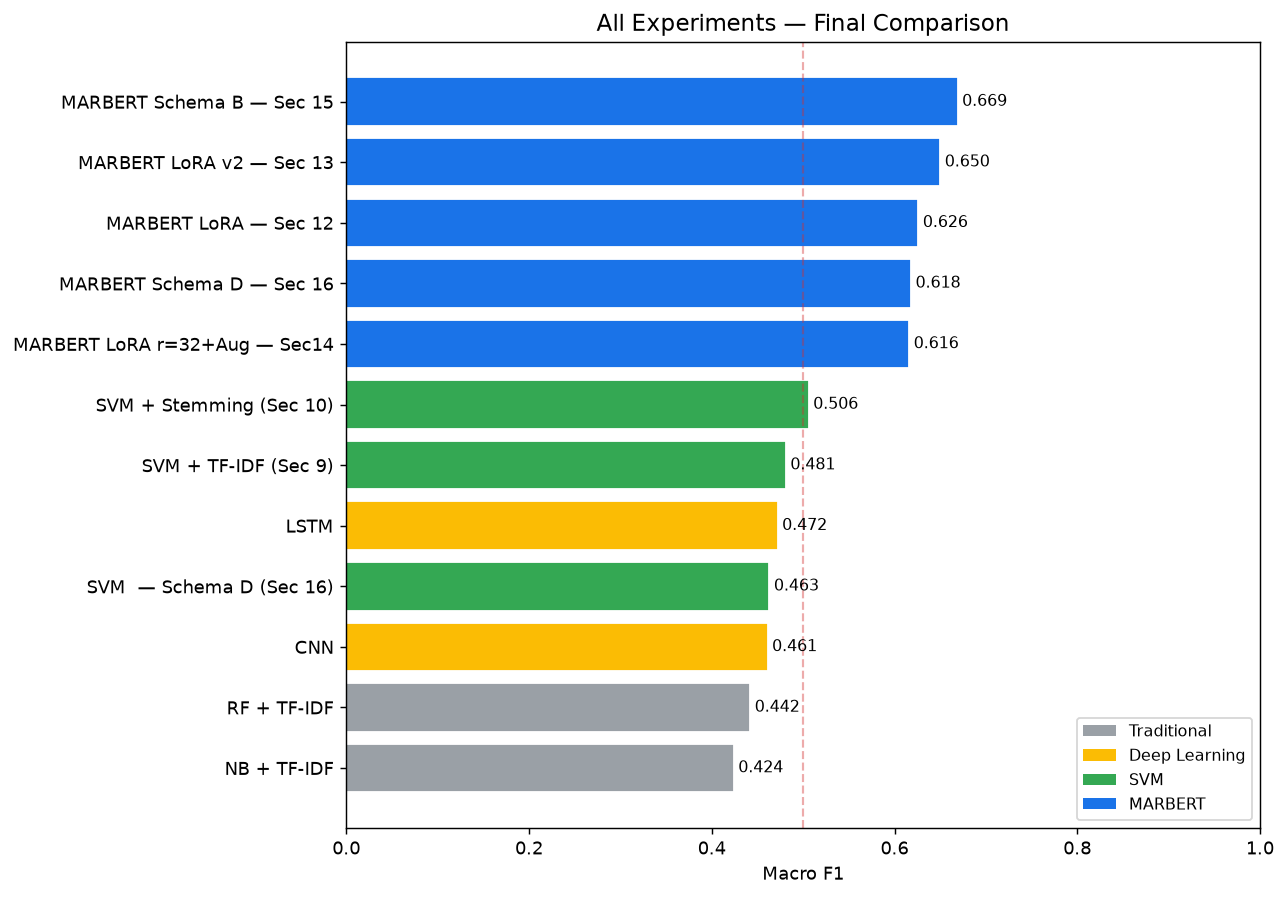


Key findings:
  Best overall:  MARBERT Schema B — Sec 15  Macro F1=0.669
  Schema C→D improvement (MARBERT): 0.531 → 0.618 (++0.087)
  Schema A→B improvement (MARBERT): 0.617 → 0.669


In [62]:
## 16.4 — Complete experiment summary across all schemas and models
import pandas as pd

# All results (use computed variables where available, hardcoded otherwise)
all_results = [
    # Traditional — Assign 2
    ('NB + TF-IDF',                  'Traditional', 0.424, 0.69),
    ('RF + TF-IDF',                  'Traditional', 0.442, 0.72),
    ('CNN',                          'Deep Learning', 0.461, 0.72),
    ('LSTM',                         'Deep Learning', 0.472, 0.73),
    # Term paper SVM
    ('SVM + TF-IDF (Sec 9)',         'SVM',  f1_score(y_test, y_pred_svm, average='macro'),
                                              np.mean(y_pred_svm==y_test)),
    ('SVM + Stemming (Sec 10)',       'SVM',  f1_score(y_test, y_pred_svm_stemmed, average='macro'),
                                              np.mean(y_pred_svm_stemmed==y_test)),
    # Term paper MARBERT
    ('MARBERT LoRA — Sec 12',        'MARBERT', f1_score(y_b_test, y_pred_marbert, average='macro'),
                                                np.mean(y_pred_marbert==y_b_test)),
    ('MARBERT LoRA v2 — Sec 13',     'MARBERT', f1_score(y_b_test, y_pred_marbert_v2, average='macro'),
                                                np.mean(y_pred_marbert_v2==y_b_test)),
    ('MARBERT LoRA r=32+Aug — Sec14','MARBERT', f1_score(y_b_test, y_pred14, average='macro'),
                                                np.mean(y_pred14==y_b_test)),
    # Schema ablation (Sec 15 best — Schema B)
    ('MARBERT Schema B — Sec 15',    'MARBERT', marbert_results_15['B: pure']['f1'],
                                                np.mean(marbert_results_15['B: pure']['preds']==
                                                        marbert_results_15['B: pure']['true'])),
    # Schema D
    ('SVM  — Schema D (Sec 16)',     'SVM',     svm_f1,  svm_acc),
    ('MARBERT Schema D — Sec 16',    'MARBERT', mb_f1,   mb_acc),
]

summary_df = pd.DataFrame(all_results, columns=['Model','Type','Macro F1','Accuracy'])
summary_df['Macro F1'] = summary_df['Macro F1'].round(3)
summary_df['Accuracy'] = summary_df['Accuracy'].round(3)
summary_df = summary_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('\n' + '='*65)
print('COMPLETE EXPERIMENT SUMMARY')
print('='*65)
print(summary_df.to_string(index=False))
print('='*65)

# ── Final bar chart ───────────────────────────────────────────────────────────
colors = {'Traditional':'#9aa0a6', 'Deep Learning':'#fbbc04',
          'SVM':'#34a853', 'MARBERT':'#1a73e8'}
fig, ax = plt.subplots(figsize=(10, 7))
names  = summary_df['Model'].tolist()
vals   = summary_df['Macro F1'].tolist()
cols   = [colors[t] for t in summary_df['Type'].tolist()]
bars   = ax.barh(names[::-1], vals[::-1], color=cols[::-1], edgecolor='white')
for bar, v in zip(bars, vals[::-1]):
    ax.text(bar.get_width()+.005, bar.get_y()+bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('Macro F1'); ax.set_title('All Experiments — Final Comparison', fontsize=13)
ax.set_xlim(0, 1.0)
ax.axvline(.5, color='#d32f2f', linestyle='--', alpha=.4, linewidth=1.2, label='0.5')
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=t) for t,c in colors.items()]
ax.legend(handles=legend_els, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('images/final_all_experiments.png', bbox_inches='tight')
plt.show()

print('\nKey findings:')
best = summary_df.iloc[0]
print(f'  Best overall:  {best["Model"]}  Macro F1={best["Macro F1"]:.3f}')
print(f'  Schema C→D improvement (MARBERT): 0.531 → {mb_f1:.3f} (+{mb_f1-0.531:+.3f})')
print(f'  Schema A→B improvement (MARBERT): 0.617 → {marbert_results_15["B: pure"]["f1"]:.3f}')


---
# 17. Comprehensive Model Metrics & Benchmarks

Every model above registered its full metric set into `MODEL_METRICS` via `record_model(...)`. This section consolidates them into one table and exports it, then visualises accuracy, efficiency (accuracy vs. size / speed), and confusion matrices side by side.

> **Reading the table:** models were evaluated under different label schemas, so `Accuracy` / `Macro F1` are only directly comparable **within the same `N Classes` / `N Test`**. Parameter, memory, and timing columns are architecture properties and are comparable across all rows. `Train (s)` for `GridSearchCV` models includes the hyper-parameter search; MARBERT rows are single LoRA fine-tunes.

In [63]:
## 17.1 — Consolidated metrics table (+ CSV / JSON export)
import pandas as pd, numpy as np, json

assert MODEL_METRICS, 'MODEL_METRICS is empty — run the model cells above (each calls record_model).'

metrics_df = pd.DataFrame(MODEL_METRICS)
col_order = ['Model','Family','N Classes','N Test','Accuracy','Macro F1','Weighted F1',
             'Params','Trainable','Layers','Mem (MB)','Train (s)','Infer (s)',
             'Infer/1k (ms)','Throughput/s']
metrics_df = metrics_df[[c for c in col_order if c in metrics_df.columns]]
metrics_df = metrics_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

# Human-readable copy (formatted params/memory) for display + CSV
disp = metrics_df.copy()
def _fmt_int(x):  return '' if pd.isna(x) else f'{int(x):,}'
def _fmt_f(x, n): return '' if pd.isna(x) else f'{x:.{n}f}'
for c in ['Params','Trainable']:      disp[c] = disp[c].map(_fmt_int)
for c in ['Mem (MB)','Train (s)','Infer (s)','Infer/1k (ms)','Throughput/s']:
    if c in disp: disp[c] = disp[c].map(lambda v: _fmt_f(v,2))

pd.set_option('display.max_columns', None, 'display.width', 200)
print('='*120)
print('SECTION 17 — COMPREHENSIVE MODEL METRICS'.center(120))
print('='*120)
print(disp.to_string(index=False))
print('='*120)

metrics_df.to_csv('results/all_model_metrics.csv', index=False)
with open('results/all_model_metrics.json','w') as f:
    json.dump(MODEL_METRICS, f, indent=2, ensure_ascii=False)
print(f'\nSaved results/all_model_metrics.csv  and  results/all_model_metrics.json  ({len(metrics_df)} models)')


                                        SECTION 17 — COMPREHENSIVE MODEL METRICS                                        
                      Model          Family  N Classes  N Test  Accuracy  Macro F1  Weighted F1      Params Trainable  Layers Mem (MB) Train (s) Infer (s) Infer/1k (ms) Throughput/s
   MARBERT · Schema B: pure     Transformer          3     645    0.6698    0.6692       0.6767 163,435,782   592,131    12.0   653.75    232.03                                     
   MARBERT LoRA v2 (Sec 13)     Transformer          3    1937    0.7403    0.6496       0.7574 163,435,782   592,131    12.0   653.75    685.92     14.49       7482.75       133.60
      MARBERT LoRA (Sec 12)     Transformer          3    1937    0.7166    0.6257       0.7356 163,435,782   592,131    12.0   653.75    503.72     14.43       7451.04       134.20
 MARBERT · Schema A: merged     Transformer          3    1939    0.6859    0.6212       0.7096 163,435,782   592,131    12.0   653.75    679.97       

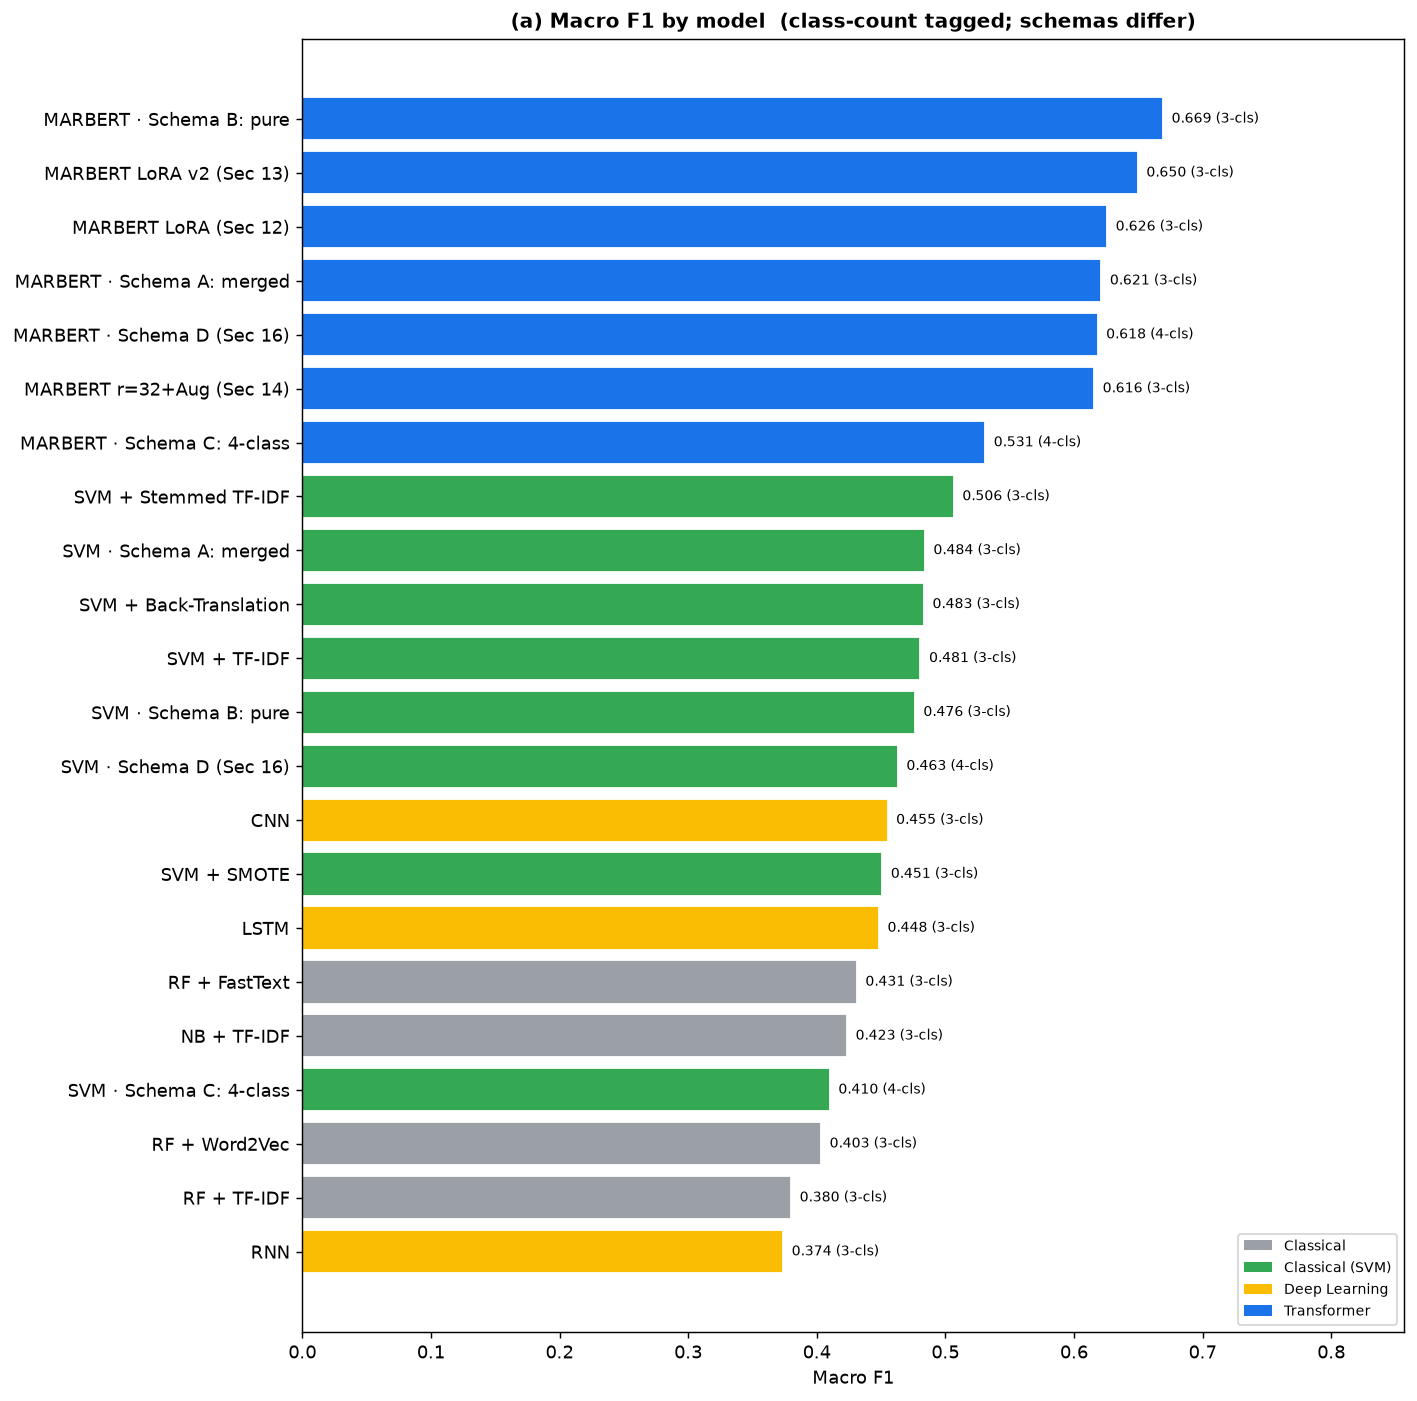

  saved images/sec17_macro_f1.png               (22 models)


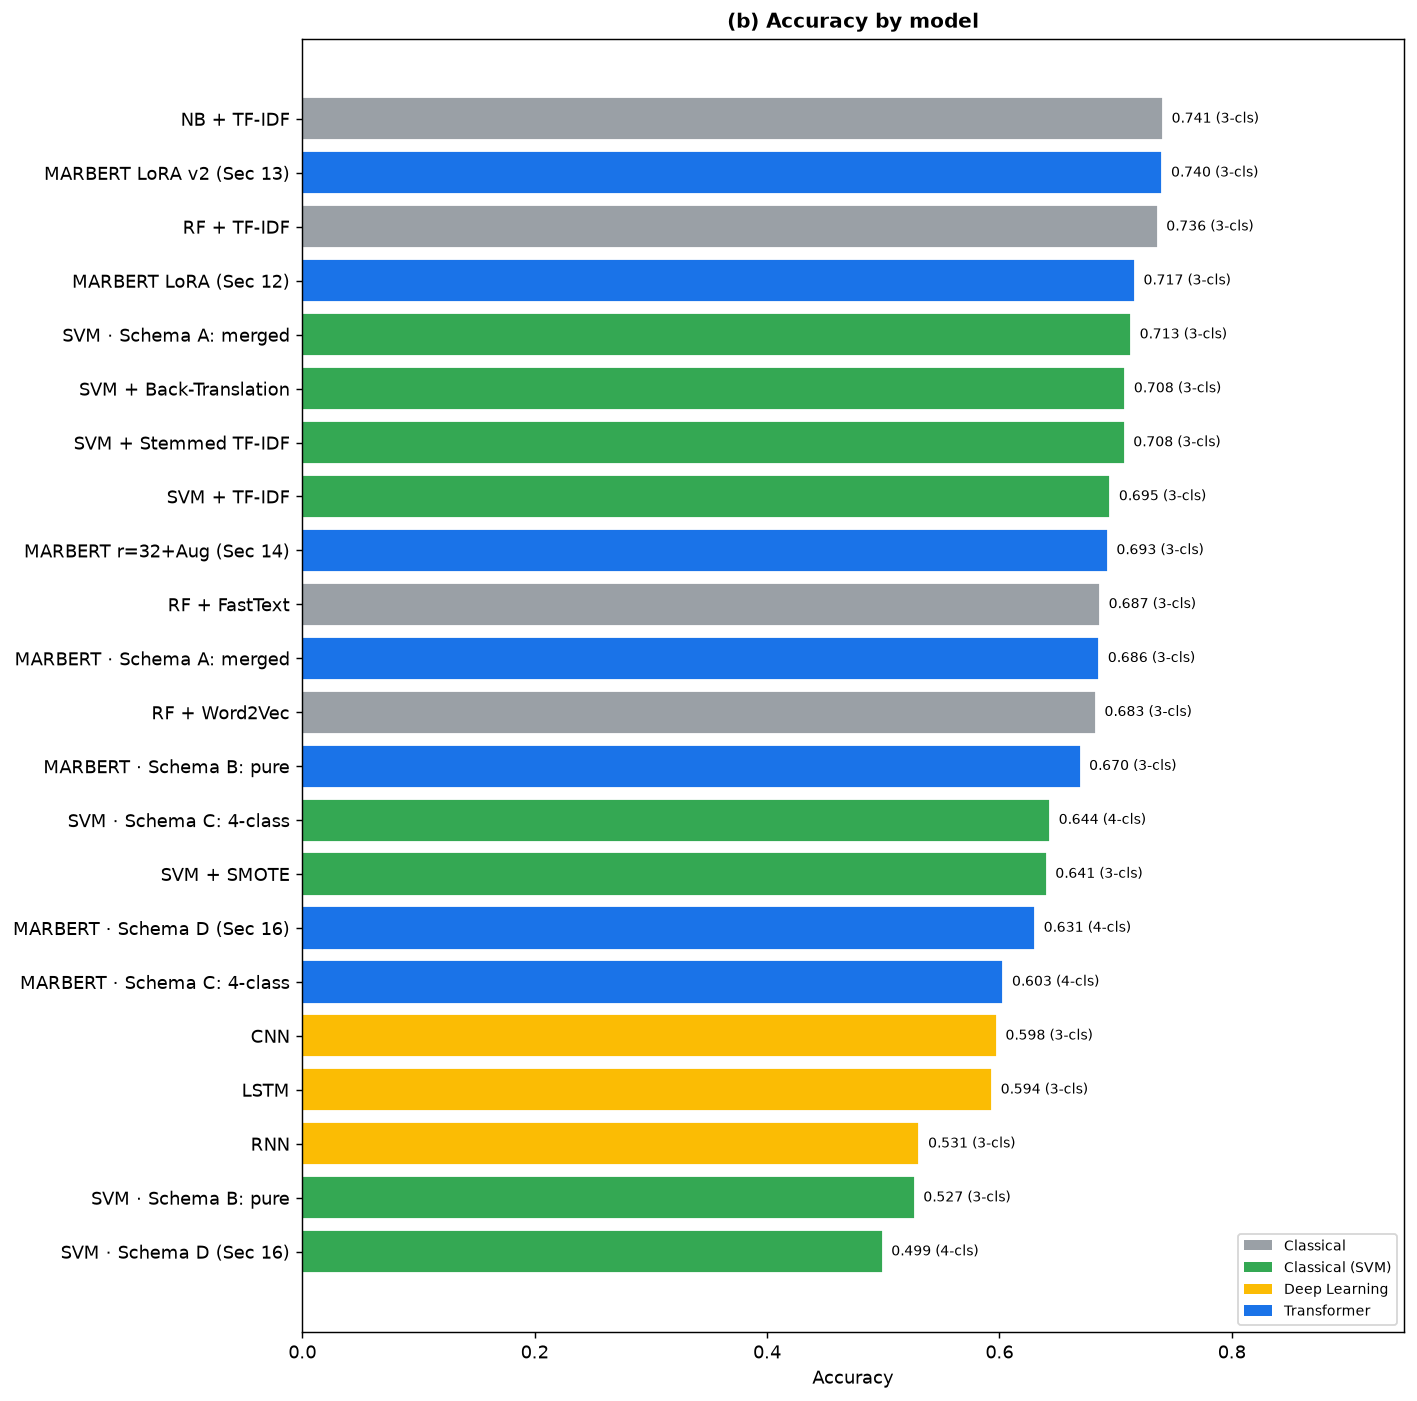

  saved images/sec17_accuracy.png               (22 models)


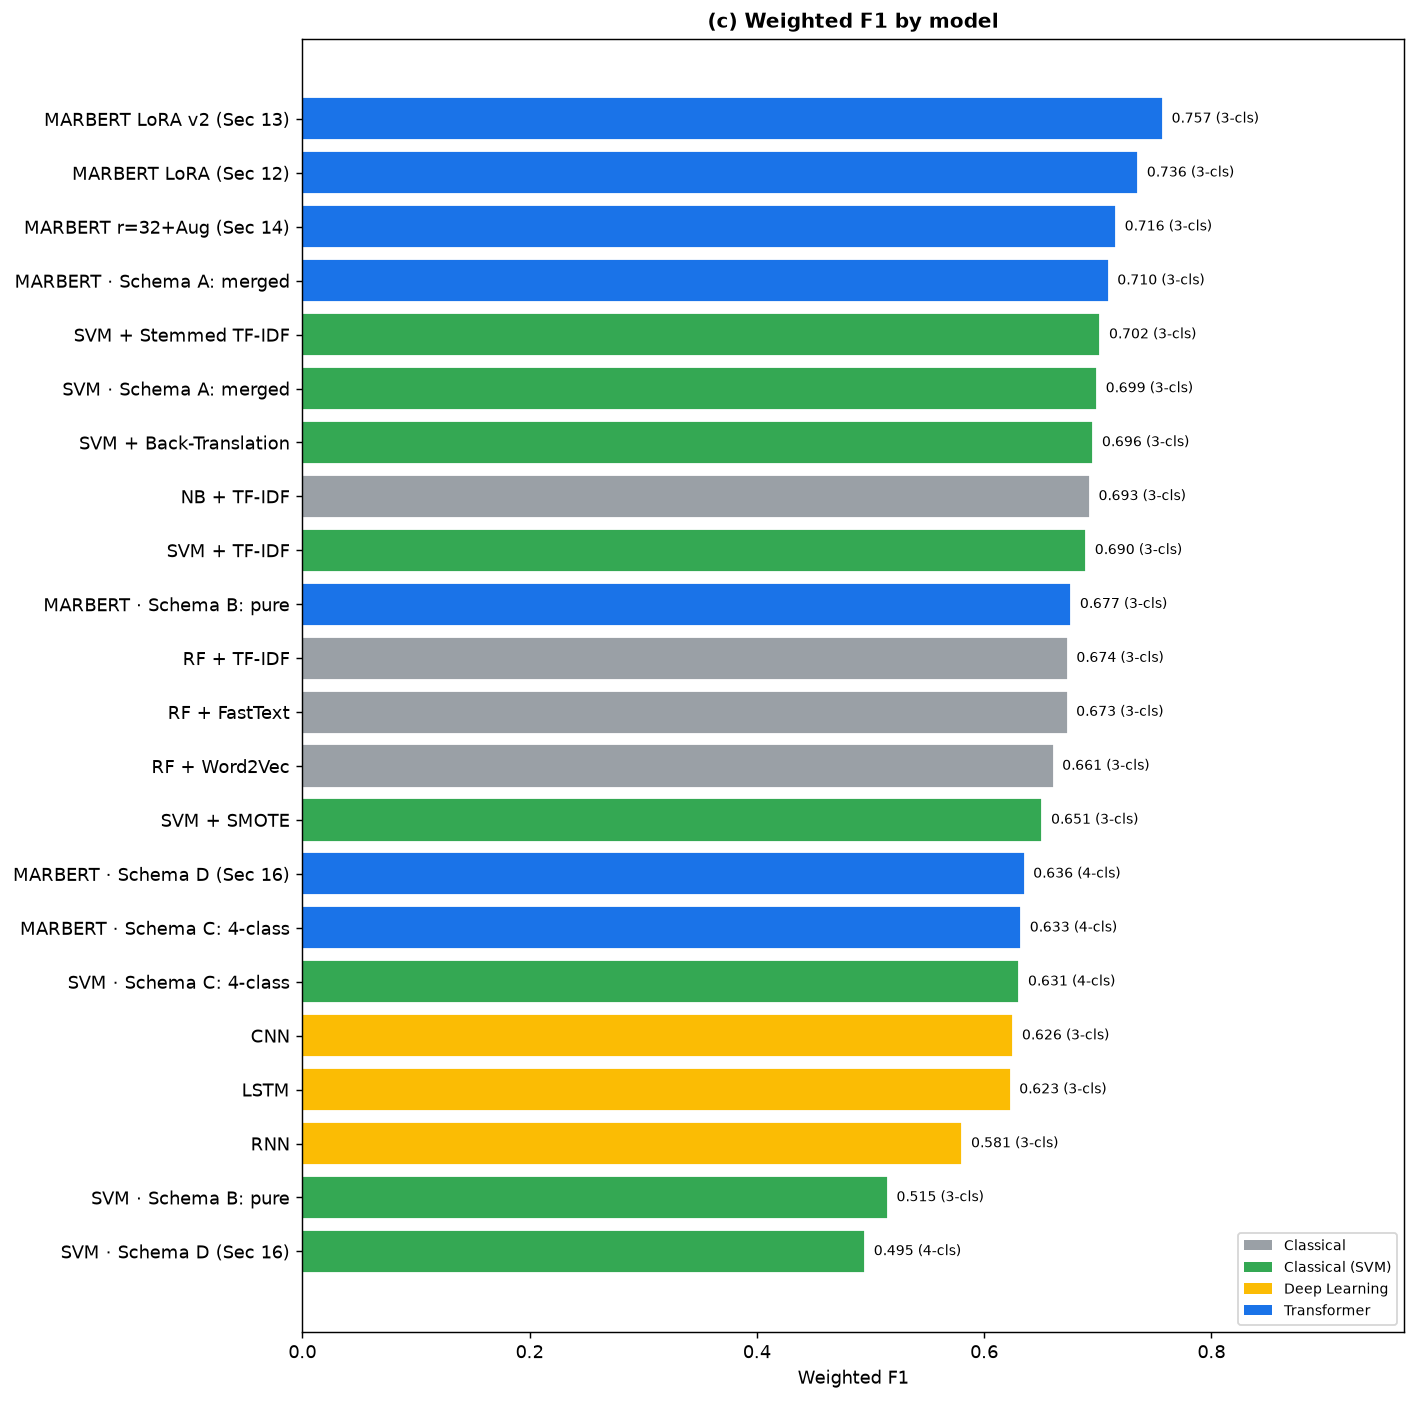

  saved images/sec17_weighted_f1.png            (22 models)


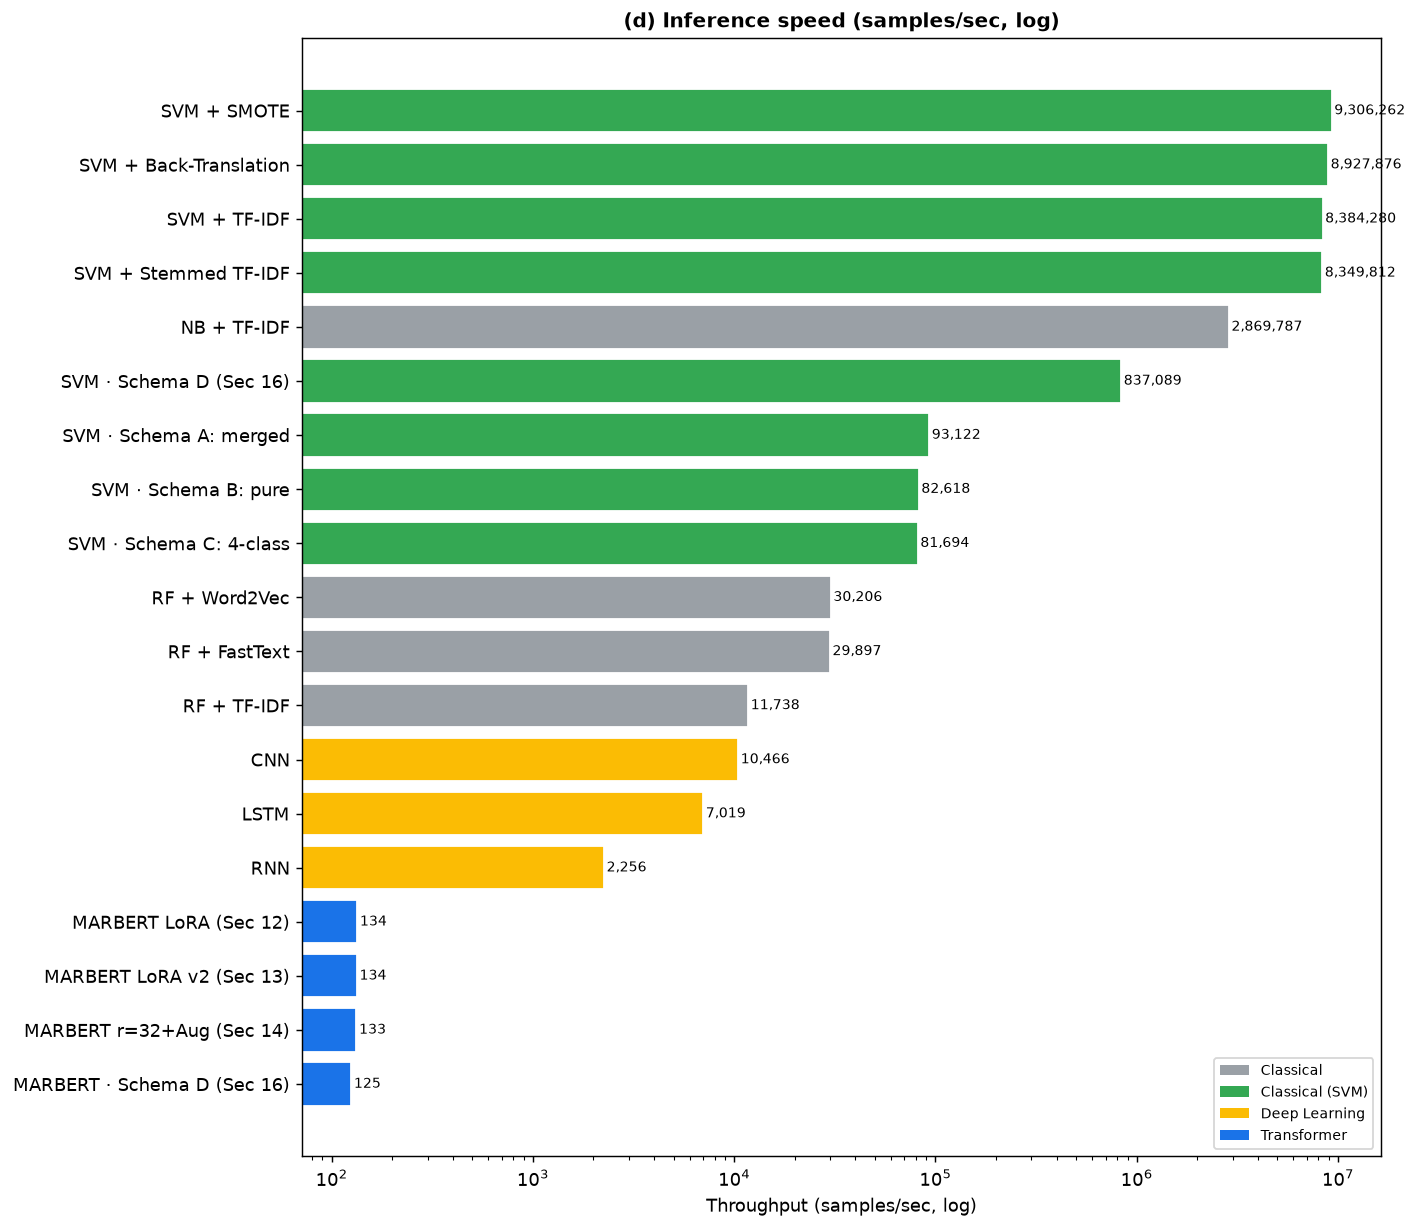

  saved images/sec17_throughput.png             (19 models)


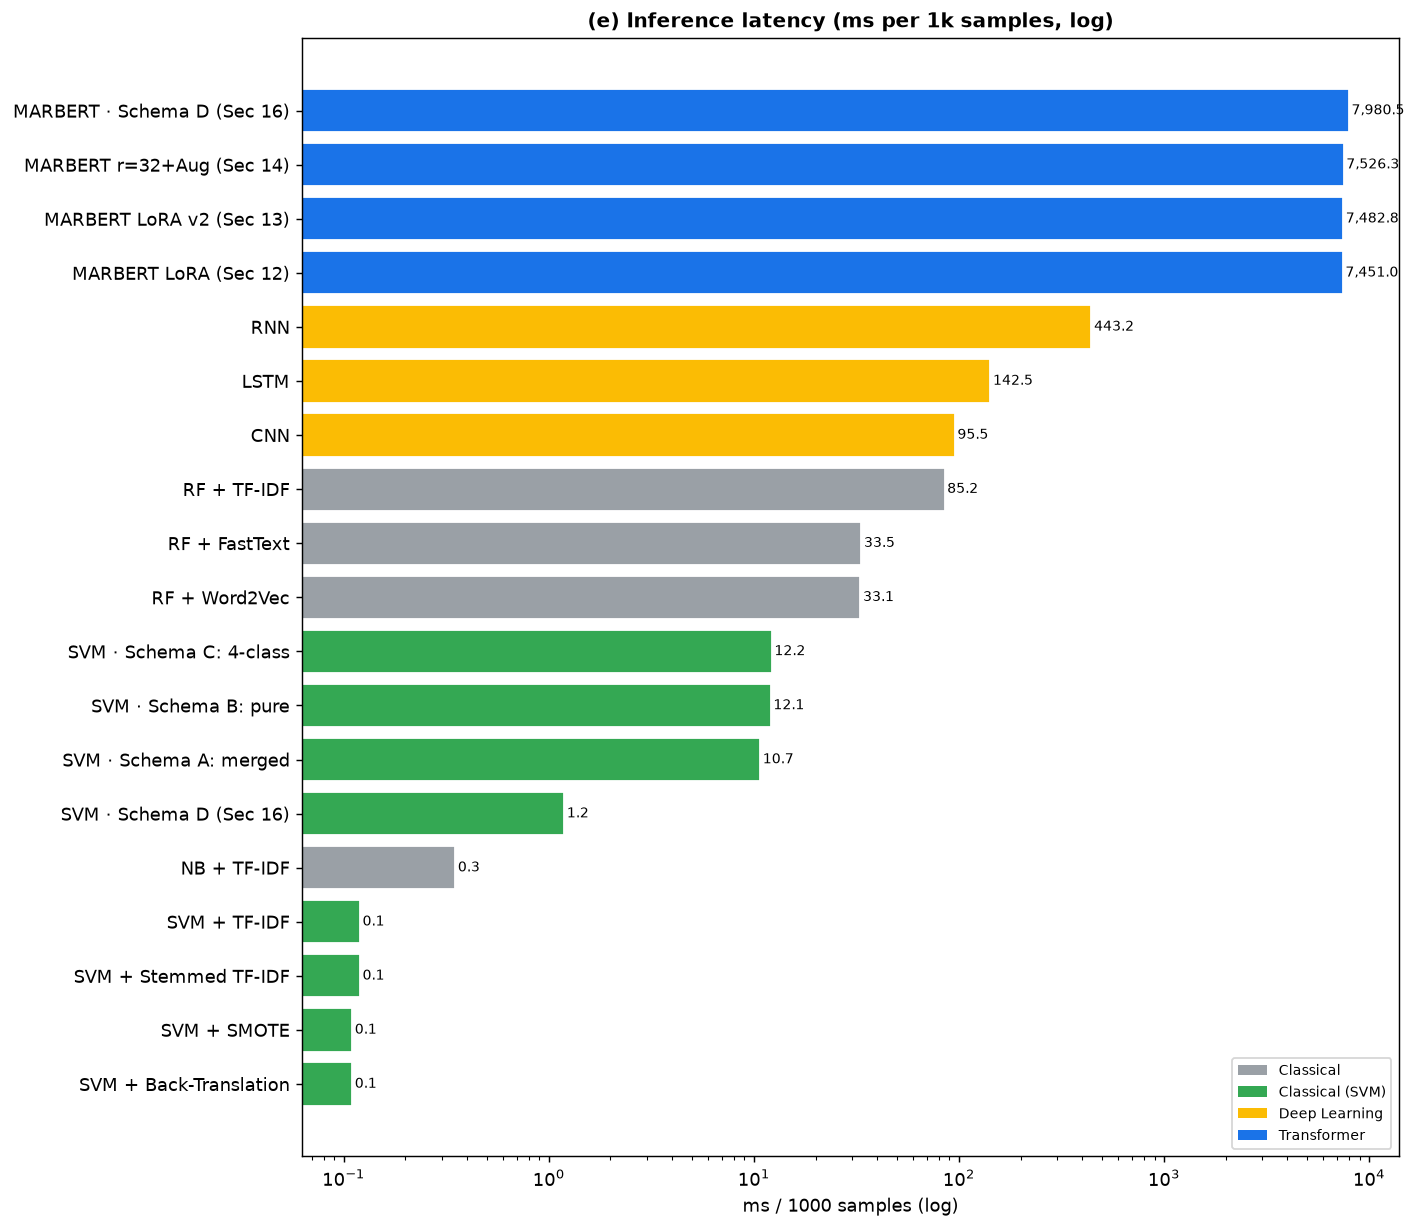

  saved images/sec17_infer_latency.png          (19 models)


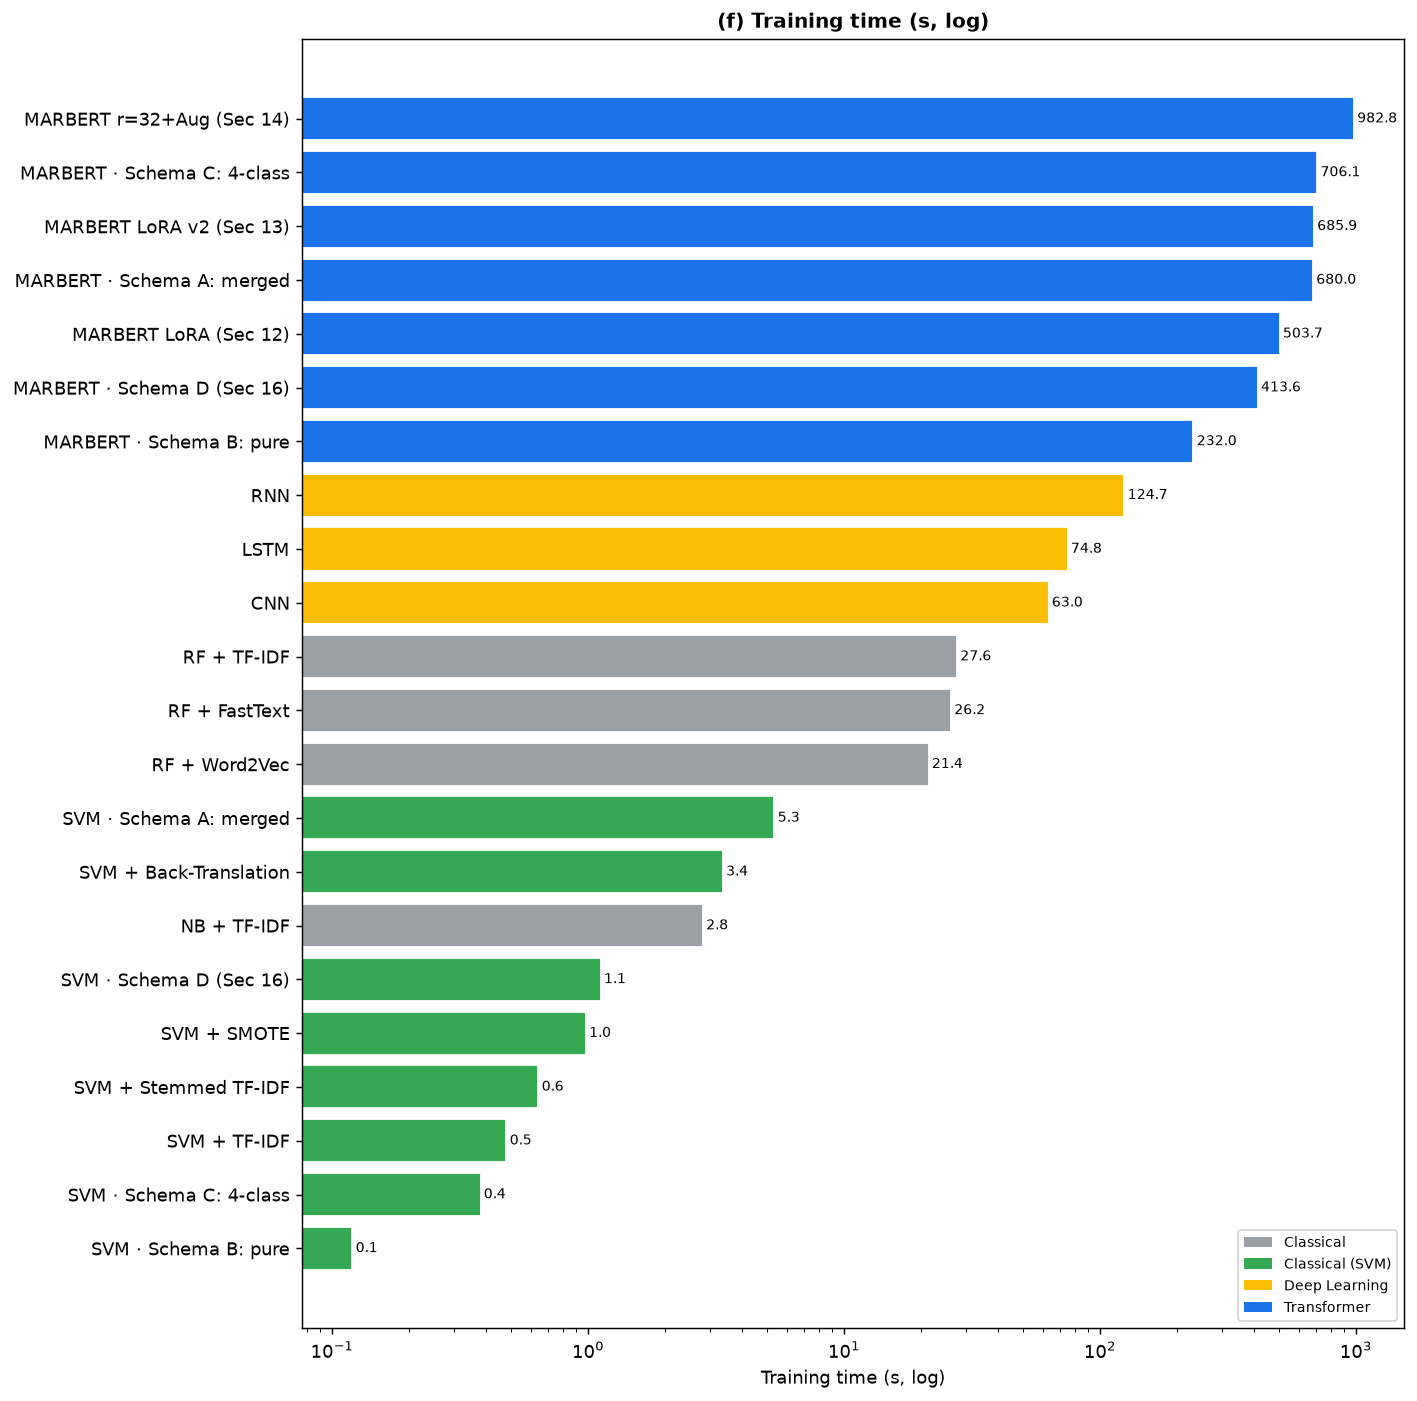

  saved images/sec17_train_time.png             (22 models)


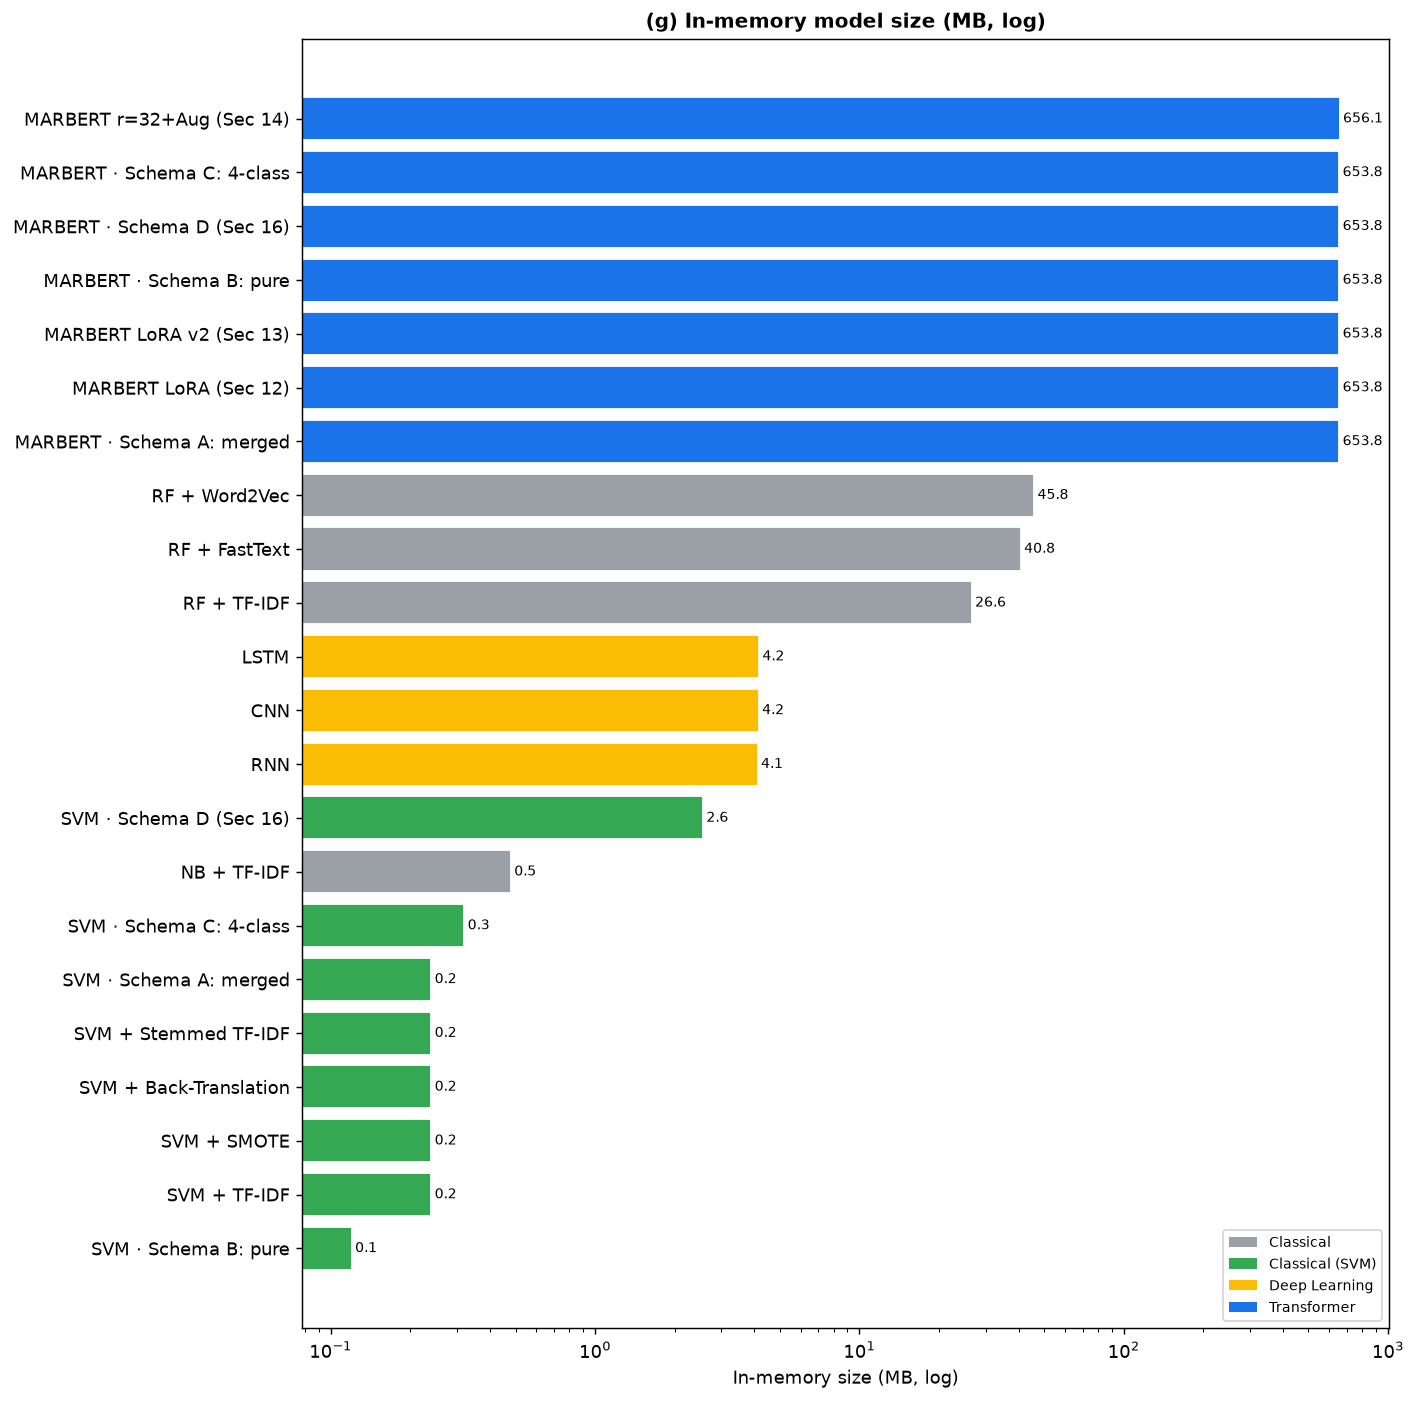

  saved images/sec17_memory.png                 (22 models)


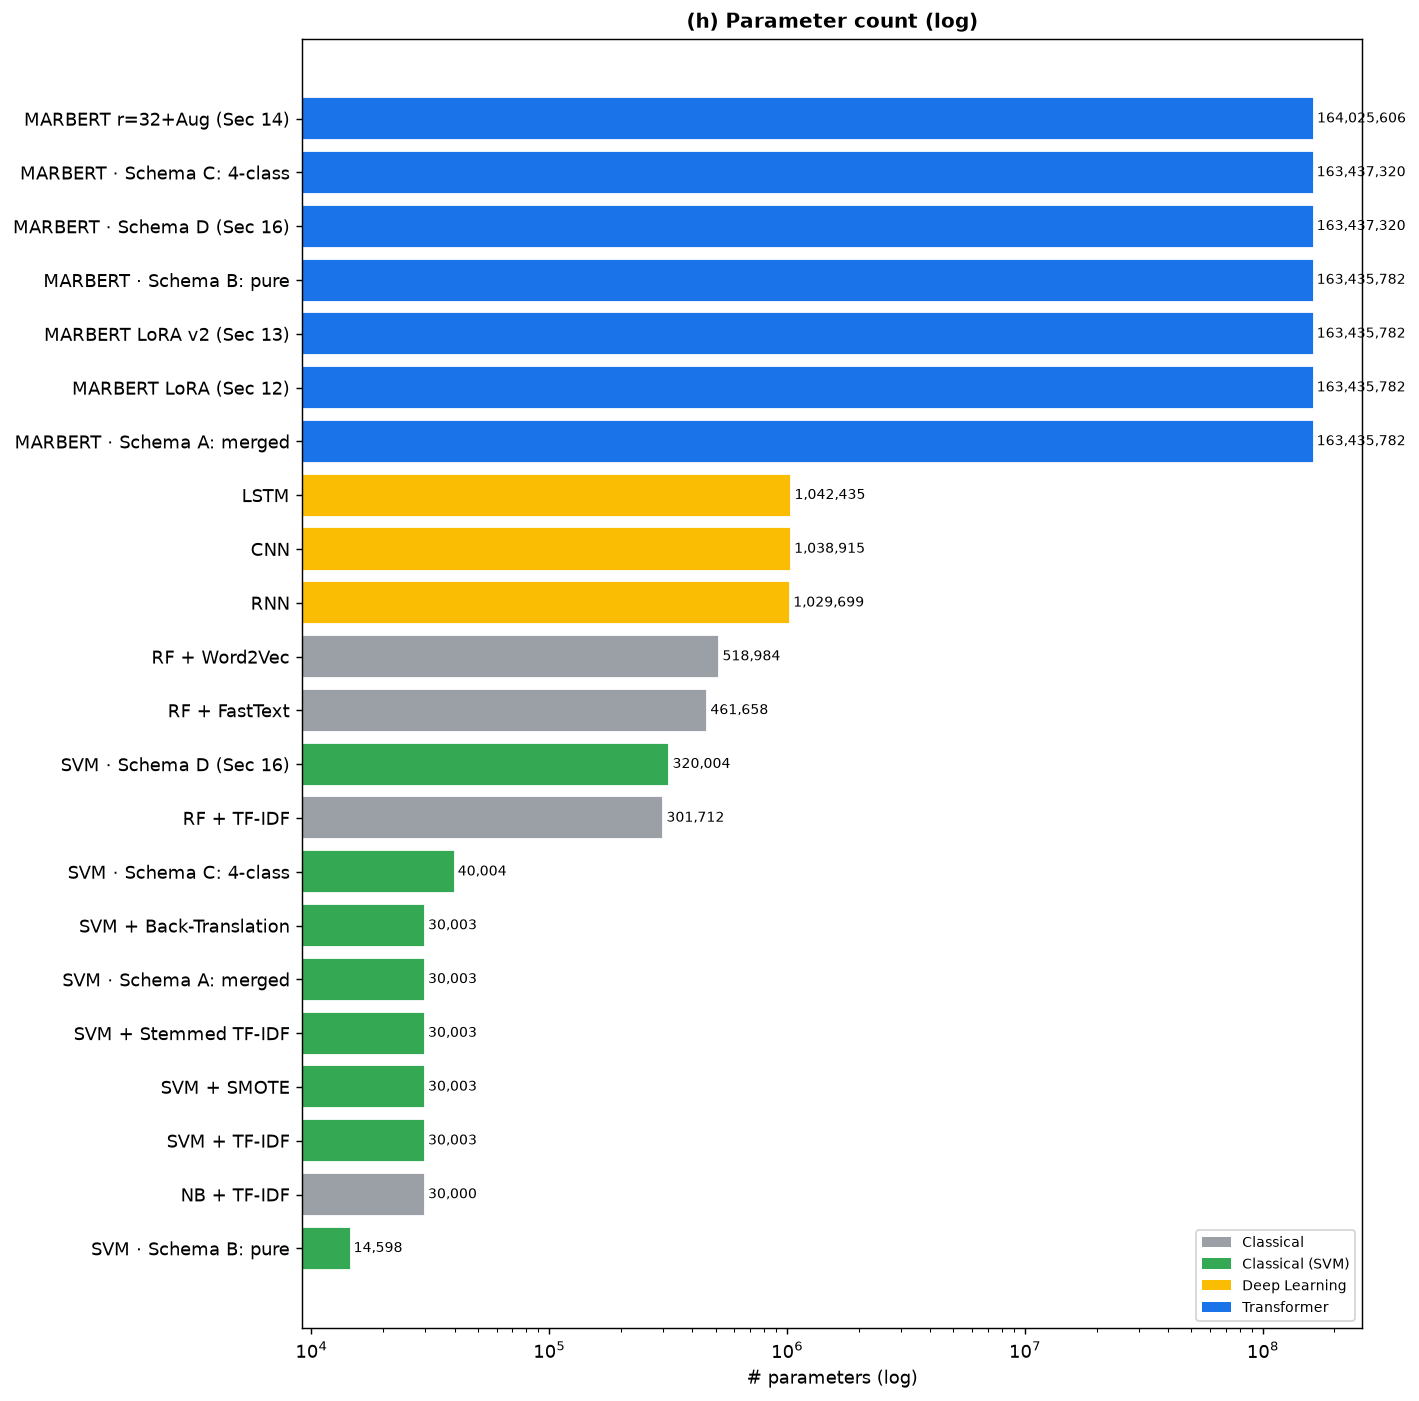

  saved images/sec17_params.png                 (22 models)


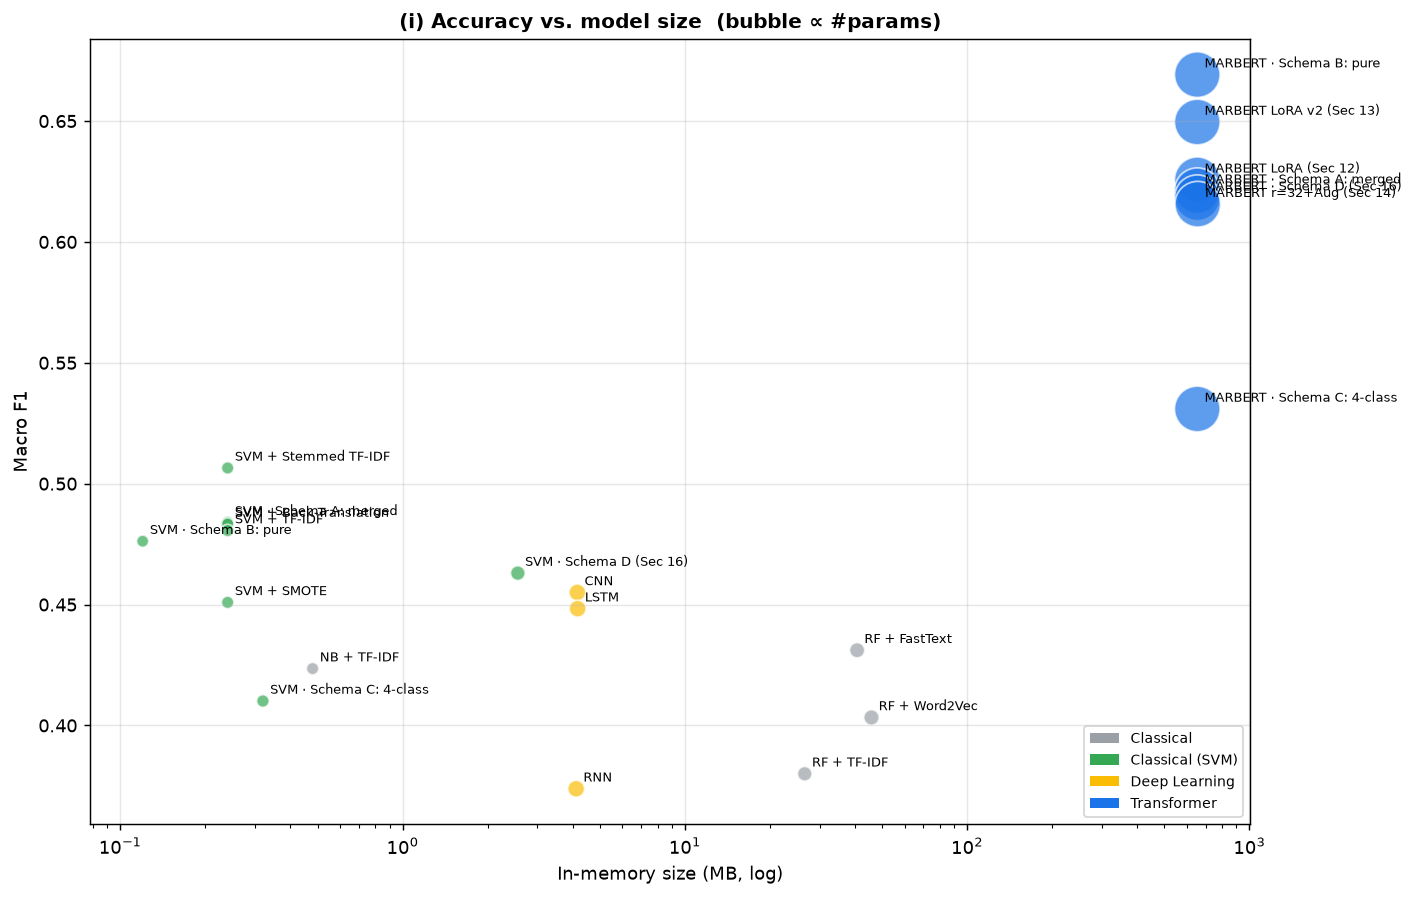

  saved images/sec17_efficiency_frontier.png

17.2 done — 22 models, one image per comparison in images/.


In [64]:
## 17.2 — Model comparison charts (one image per comparison, all models)
import matplotlib.pyplot as plt
import numpy as np, os
from matplotlib.patches import Patch

os.makedirs('images', exist_ok=True)

fam_colors = {'Classical':'#9aa0a6', 'Classical (SVM)':'#34a853',
              'Deep Learning':'#fbbc04', 'Transformer':'#1a73e8'}
def _col(f): return fam_colors.get(f, '#777777')
_legend = [Patch(facecolor=c, label=l) for l, c in fam_colors.items()]

d = metrics_df.copy()

def _barh(col, title, fname, fmt='{:.3f}', logx=False, xlabel=None, annotate_cls=False):
    """One horizontal-bar comparison -> its own image. Includes every model that has `col`."""
    sub = d.dropna(subset=[col]).copy()
    if logx:                                   # log axis can't show <=0
        sub = sub[sub[col] > 0]
    sub = sub.sort_values(col)
    if sub.empty:
        print(f'  (skip {title!r}: no data in "{col}")'); return
    fig, ax = plt.subplots(figsize=(11, max(4, 0.44 * len(sub) + 1.2)))
    ax.barh(sub['Model'], sub[col], color=[_col(f) for f in sub['Family']], edgecolor='white')
    vmax = sub[col].max()
    for y, (v, ncls) in enumerate(zip(sub[col], sub['N Classes'])):
        tag = fmt.format(v) + (f' ({int(ncls)}-cls)' if annotate_cls else '')
        xt = v * 1.03 if logx else v + vmax * 0.01
        ax.text(xt, y, tag, va='center', fontsize=8)
    if logx:
        ax.set_xscale('log')
    else:
        ax.set_xlim(0, vmax * 1.28)
    ax.set_xlabel(xlabel or col)
    ax.set_title(title, fontweight='bold')
    ax.legend(handles=_legend, fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig(f'images/{fname}', bbox_inches='tight', dpi=140)
    plt.show()
    print(f'  saved images/{fname:32s} ({len(sub)} models)')

# ── one image per comparison ──────────────────────────────────────────────────
_barh('Macro F1',     '(a) Macro F1 by model  (class-count tagged; schemas differ)',
      'sec17_macro_f1.png',      fmt='{:.3f}',   annotate_cls=True)
_barh('Accuracy',     '(b) Accuracy by model',
      'sec17_accuracy.png',      fmt='{:.3f}',   annotate_cls=True)
_barh('Weighted F1',  '(c) Weighted F1 by model',
      'sec17_weighted_f1.png',   fmt='{:.3f}',   annotate_cls=True)
_barh('Throughput/s', '(d) Inference speed (samples/sec, log)',
      'sec17_throughput.png',    fmt='{:,.0f}',  logx=True, xlabel='Throughput (samples/sec, log)')
_barh('Infer/1k (ms)','(e) Inference latency (ms per 1k samples, log)',
      'sec17_infer_latency.png', fmt='{:,.1f}',  logx=True, xlabel='ms / 1000 samples (log)')
_barh('Train (s)',    '(f) Training time (s, log)',
      'sec17_train_time.png',    fmt='{:,.1f}',  logx=True, xlabel='Training time (s, log)')
_barh('Mem (MB)',     '(g) In-memory model size (MB, log)',
      'sec17_memory.png',        fmt='{:,.1f}',  logx=True, xlabel='In-memory size (MB, log)')
_barh('Params',       '(h) Parameter count (log)',
      'sec17_params.png',        fmt='{:,.0f}',  logx=True, xlabel='# parameters (log)')

# ── efficiency frontier (its own image): Macro F1 vs memory, bubble ∝ #params ──
ef = d.dropna(subset=['Mem (MB)', 'Macro F1']).copy()
ef = ef[ef['Mem (MB)'] > 0]
if not ef.empty:
    fig, ax = plt.subplots(figsize=(11, 7))
    p = ef['Params'].astype(float).fillna(1.0)
    sizes = (np.sqrt(p) / np.sqrt(p.max())) * 600 + 40
    ax.scatter(ef['Mem (MB)'], ef['Macro F1'], s=sizes,
               c=[_col(f) for f in ef['Family']], alpha=.7, edgecolor='white', linewidth=1)
    for _, r in ef.iterrows():
        ax.annotate(r['Model'], (r['Mem (MB)'], r['Macro F1']), fontsize=7,
                    xytext=(4, 4), textcoords='offset points')
    ax.set_xscale('log'); ax.set_xlabel('In-memory size (MB, log)'); ax.set_ylabel('Macro F1')
    ax.set_title('(i) Accuracy vs. model size  (bubble ∝ #params)', fontweight='bold')
    ax.legend(handles=_legend, fontsize=8, loc='lower right'); ax.grid(alpha=.3)
    plt.tight_layout()
    plt.savefig('images/sec17_efficiency_frontier.png', bbox_inches='tight', dpi=140)
    plt.show()
    print('  saved images/sec17_efficiency_frontier.png')

print(f'\n17.2 done — {len(d)} models, one image per comparison in images/.')


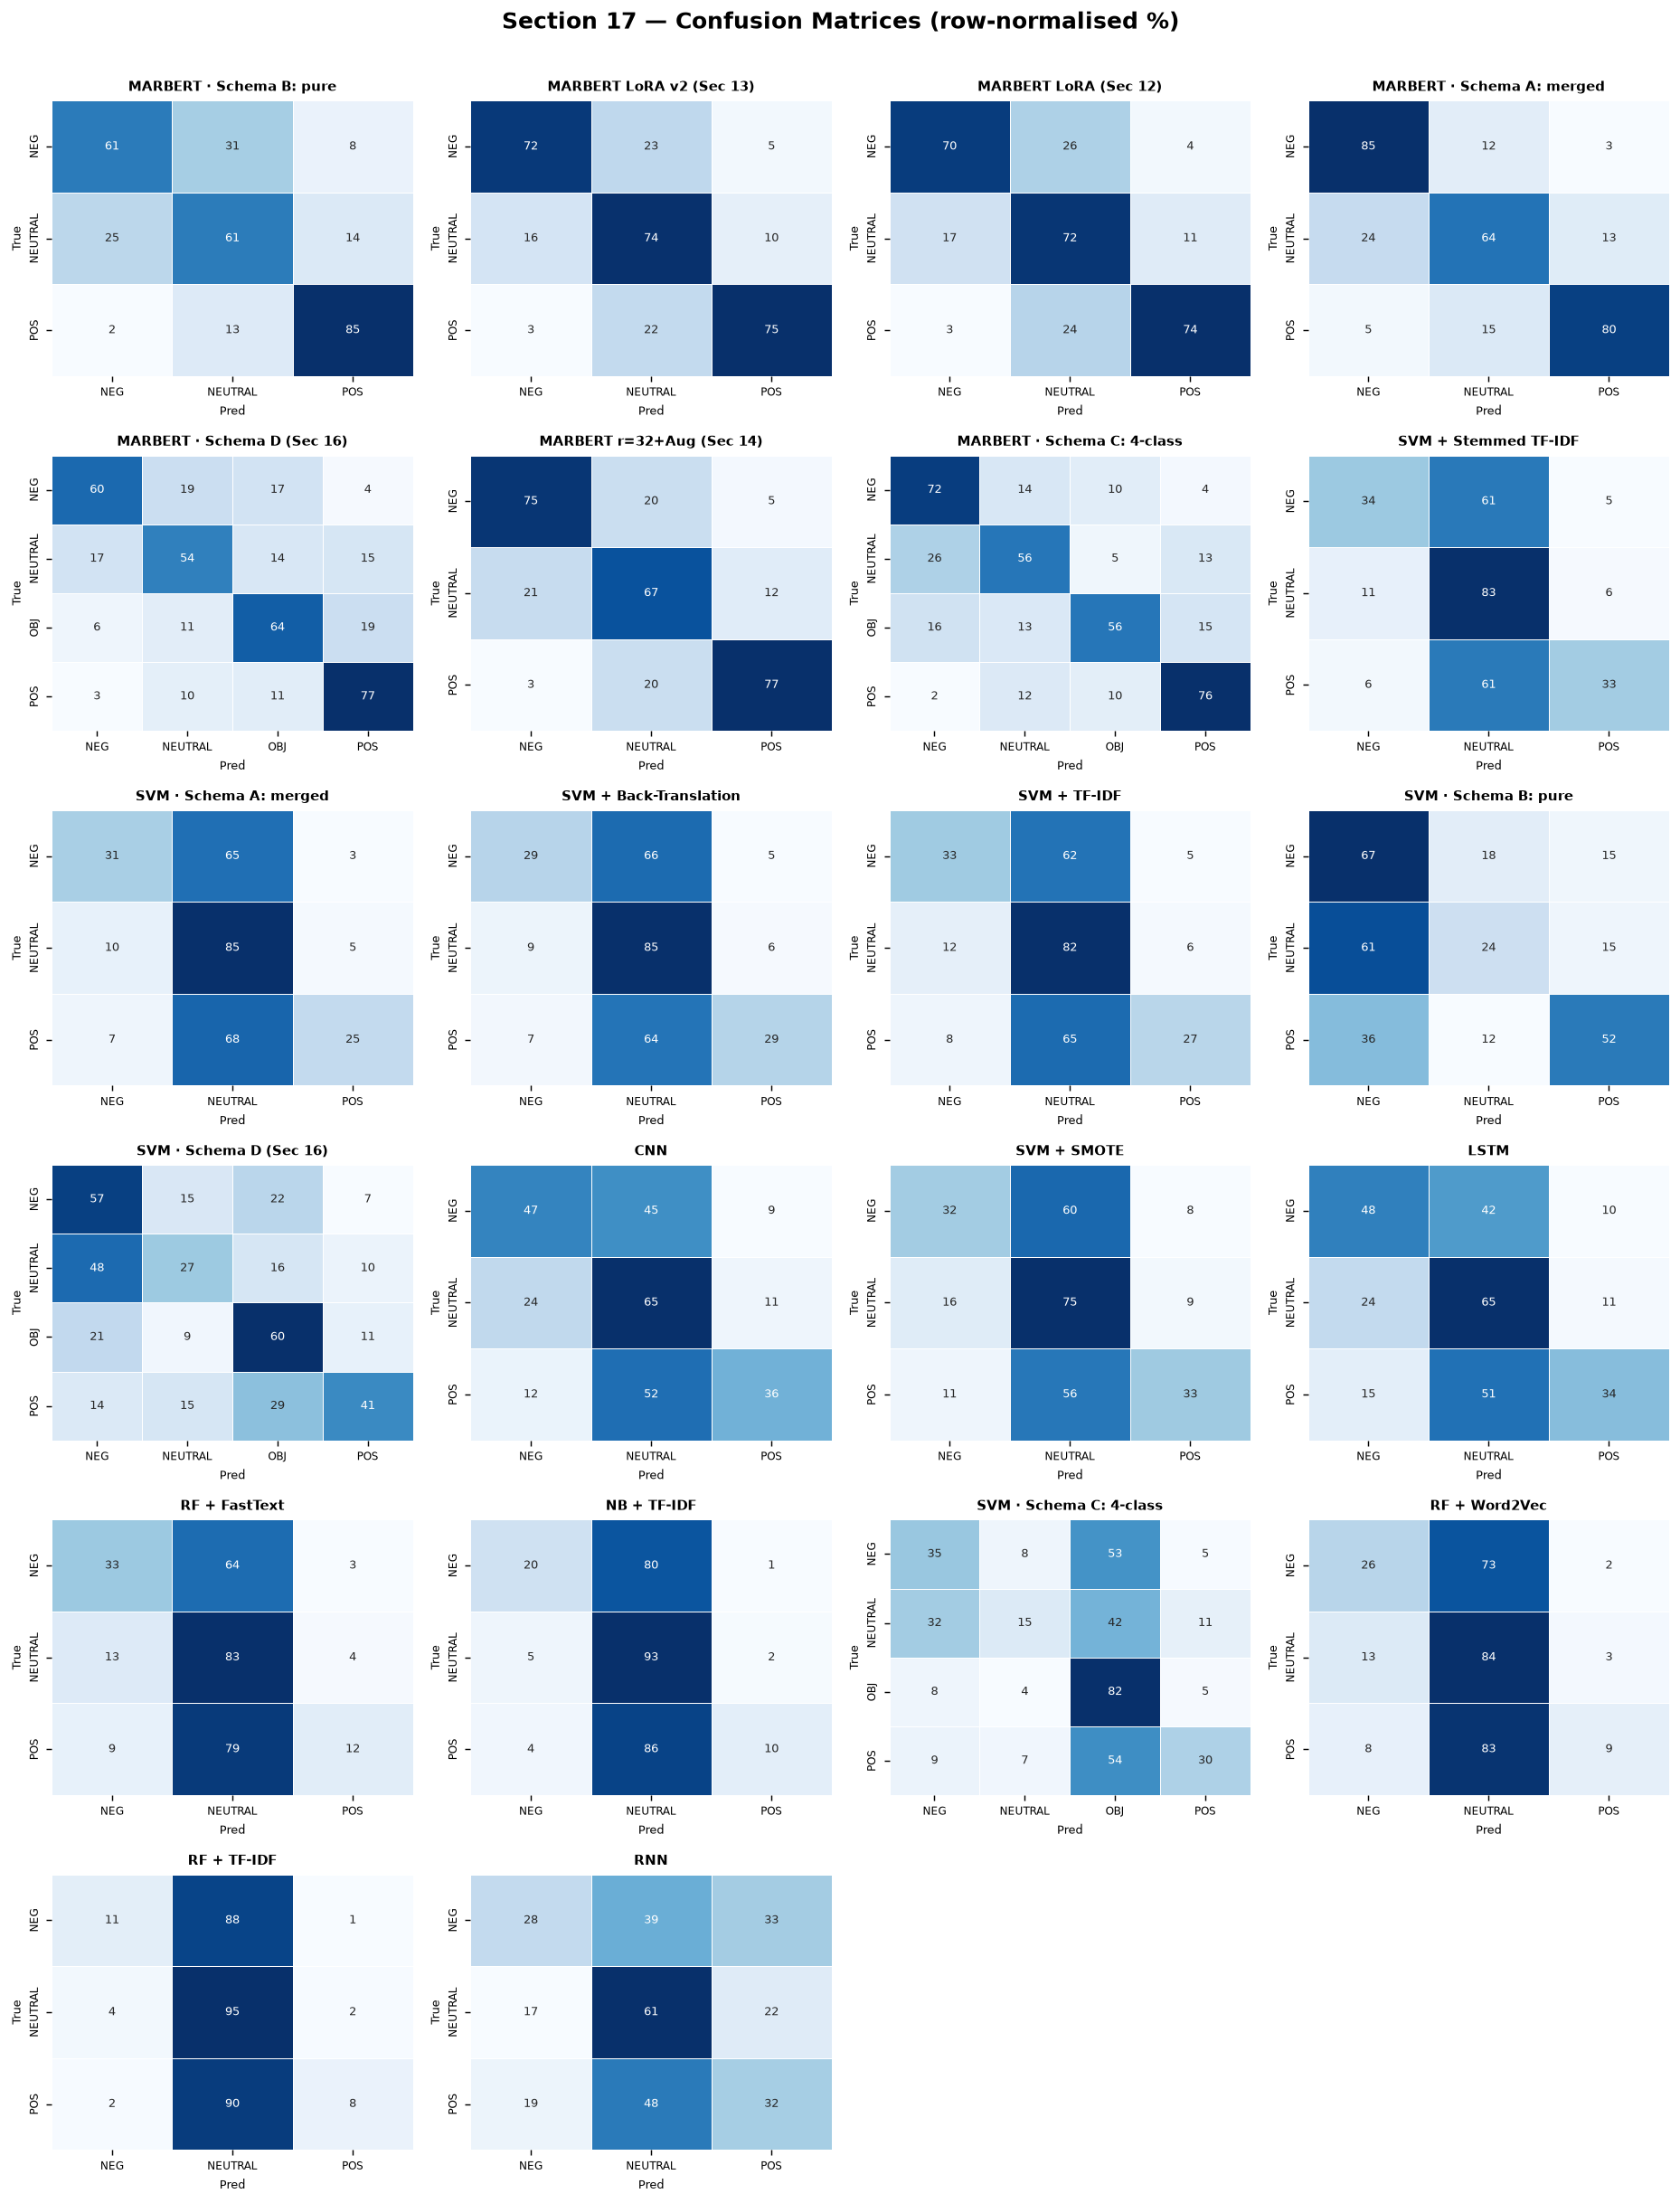

Rendered 22 confusion matrices.


In [65]:
## 17.3 — Confusion-matrix grid (all models, row-normalised %)
import matplotlib.pyplot as plt, seaborn as sns, numpy as np

names = [r['Model'] for r in sorted(MODEL_METRICS, key=lambda r: -r['Macro F1']) if r['Model'] in CONF_MATS]
ncol  = 4
nrow  = int(np.ceil(len(names)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*3.6, nrow*3.1))
axes = np.array(axes).flatten()

for ax, name in zip(axes, names):
    cm, classes = CONF_MATS[name]
    cm_pct = cm.astype(float)/cm.sum(axis=1, keepdims=True)*100
    sns.heatmap(cm_pct, annot=True, fmt='.0f', cmap='Blues', cbar=False,
                xticklabels=classes, yticklabels=classes, ax=ax,
                annot_kws={'size':7}, linewidths=.3)
    ax.set_title(name, fontsize=8.5, fontweight='bold')
    ax.set_xlabel('Pred', fontsize=7); ax.set_ylabel('True', fontsize=7)
    ax.tick_params(labelsize=6.5)
for ax in axes[len(names):]:
    ax.set_visible(False)

plt.suptitle('Section 17 — Confusion Matrices (row-normalised %)', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('images/sec17_confusion_grid.png', bbox_inches='tight', dpi=140)
plt.show()
print(f'Rendered {len(names)} confusion matrices.')


In [66]:
## 17.4 — Figure & artefact manifest
import os, glob, pandas as pd
imgs = sorted(glob.glob('images/*.png'))
print(f'{len(imgs)} figures persisted to images/:')
for p in imgs:
    print(f'  {os.path.getsize(p)/1024:6.1f} KB  {p}')
with open('results/figure_manifest.txt', 'w') as f:
    f.write(f'{len(imgs)} figures\n' + '\n'.join(imgs) + '\n')
print('\nData artefacts in results/:')
for p in sorted(glob.glob('results/*')):
    print(f'  {os.path.getsize(p)/1024:6.1f} KB  {p}')
print('\nManifest written to results/figure_manifest.txt')


33 figures persisted to images/:
    23.3 KB  images/class_distribution.png
   155.6 KB  images/confusion_matrices.png
   180.4 KB  images/fasttext_pca.png
    67.9 KB  images/final_all_experiments.png
   135.2 KB  images/model_comparison.png
    65.1 KB  images/representation_impact.png
    32.4 KB  images/sec09_svm_cm.png
    57.9 KB  images/sec10_stemming_cm.png
    27.9 KB  images/sec11_augmentation.png
    50.9 KB  images/sec12_all_models.png
    32.4 KB  images/sec12_marbert_cm.png
    60.3 KB  images/sec13_ablation_cm.png
    33.5 KB  images/sec14_marbert_cm.png
    31.4 KB  images/sec14_progression.png
   100.8 KB  images/sec15_marbert_cms.png
    25.0 KB  images/sec15_marbert_schemas.png
    94.6 KB  images/sec15_svm_cms.png
    23.2 KB  images/sec15_svm_schemas.png
    44.0 KB  images/sec16_marbert_D_cm.png
    41.1 KB  images/sec16_svm_D_cm.png
   124.0 KB  images/sec17_accuracy.png
   280.2 KB  images/sec17_confusion_grid.png
    91.1 KB  images/sec17_efficiency_frontier.pn